# 🖥️ High-Performance Job Scheduler — Data Pipeline
### Alibaba Cluster Trace v2018 · EDA, Cleaning & Feature Engineering

---

**Project Goal:** Build ML-ready datasets from the Alibaba Cluster Trace (2018) to power a job scheduler with the following prediction capabilities:

| Model | Target | Primary File |
|---|---|---|
| 🕒 Runtime Prediction | How long will a job take? | `batch_task.csv` |
| ❌ Failure Prediction | Will a job fail? | `batch_task.csv` + `batch_instance.csv` |
| 📊 Resource Utilization | Future CPU/Mem demand? | `machine_usage_bigger.csv` |
| 🔍 Anomaly Detection | Is a machine behaving abnormally? | `machine_usage_bigger.csv` |
| 🗂️ Workload Clustering | What type of job is this? | `batch_task.csv` |

---
> **Dataset:** [Alibaba Cluster Data (Kaggle)](https://www.kaggle.com/datasets/rohitdurbha/alibaba-cluster-data) — 4,000 machines · 8 days · ~270 GB uncompressed


---
## 📦 Section 1 — Environment Setup & Dataset Download

We configure Kaggle credentials, download the dataset, and unzip it directly in Colab.


In [ ]:
# ── PERSISTENT STORAGE SETUP ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

SAVE_DIR = '/content/drive/MyDrive/job_scheduler/'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✅ Drive mounted. All outputs will persist at: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. All outputs will persist at: /content/drive/MyDrive/job_scheduler/


In [ ]:
# ── Centralized path config (edit SAVE_DIR above, not here) ──────────────────
PATHS = {
    # Intermediate checkpoints
    'batch_task_cleaned':     SAVE_DIR + 'batch_task_cleaned.csv',
    'batch_task_featured':    SAVE_DIR + 'batch_task_featured.csv',
    'machine_state':          SAVE_DIR + 'machine_state.parquet',
    'final_training_data':    SAVE_DIR + 'final_training_data.parquet',
    'final_clustered':        SAVE_DIR + 'final_training_data_clustered.parquet',

    # Models
    'runtime_model':          SAVE_DIR + 'runtime_predictor.pkl',
    'failure_model':          SAVE_DIR + 'failure_predictor_lgbm.pkl',
    'failure_scaler':         SAVE_DIR + 'failure_predictor_scaler.pkl',
    'failure_threshold':      SAVE_DIR + 'failure_predictor_threshold.pkl',
    'resource_xgb':           SAVE_DIR + 'resource_xgb.pkl',
    'resource_scaler':        SAVE_DIR + 'resource_scaler.pkl',
    'resource_lstm':          SAVE_DIR + 'resource_lstm.keras',
    'resource_lstm_scaler':   SAVE_DIR + 'resource_lstm_scaler.pkl',
    'resource_lstm_yscaler':  SAVE_DIR + 'resource_lstm_yscaler.pkl',
    'anomaly_iso':            SAVE_DIR + 'anomaly_iso_forest.pkl',
    'anomaly_scaler':         SAVE_DIR + 'anomaly_scaler.pkl',
    'anomaly_ae':             SAVE_DIR + 'anomaly_autoencoder.keras',
    'anomaly_threshold':      SAVE_DIR + 'anomaly_ae_threshold.pkl',
    'cluster_kmeans':         SAVE_DIR + 'workload_kmeans.pkl',
    'cluster_hdbscan':        SAVE_DIR + 'workload_hdbscan.pkl',
    'cluster_scaler':         SAVE_DIR + 'workload_scaler.pkl',
}

print("✅ Path config ready.")

✅ Path config ready.


In [1]:
from google.colab import userdata
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY = userdata.get('KAGGLE_KEY')
KAGGLE_API_TOKEN = userdata.get('KAGGLE_API_TOKEN')

In [2]:
import os

os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_TOKEN

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [ ]:
!kaggle datasets download -d rohitdurbha/alibaba-cluster-data

Dataset URL: https://www.kaggle.com/datasets/rohitdurbha/alibaba-cluster-data
License(s): MIT
100% 1.22G/1.22G [00:10<00:00, 119MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('alibaba-cluster-data.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
import os
os.listdir('data')

['machine_usage_bigger.csv',
 'container_meta.csv',
 'container_usage.csv',
 'machine_meta.csv',
 'batch_instance.csv',
 'batch_task.csv']

In [ ]:
import os
import zipfile

# ── Kaggle credentials ──────────────────────────────────────────────────────
# ⚠️  Replace with your own credentials if needed
os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY

# Verify connection
!kaggle datasets list -s "alibaba"


ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
mhassansaboor/alibaba-stock-dataset-2025                        Alibaba Stock Dataset 2025                               65301  2025-02-14 13:38:26.847000           1918         60                1  
varpit94/alibaba-stock-data                                     Alibaba Stock Data                                       38372  2022-03-25 16:05:46.730000           2245         44                1  
innocentmfa/alibaba-baba-stock-dataset                          Alibaba (BABA) Stock Dataset📊                            26867  2024-05-08 13:35:25.673000            885         48                1  


In [ ]:
# Download and extract the dataset
!kaggle datasets download -d rohitdurbha/alibaba-cluster-data

# Unzip all downloaded archives
for file in os.listdir():
    if file.endswith(".zip"):
        print(f"📂 Unzipping {file} ...")
        with zipfile.ZipFile(file, 'r') as zip_ref:
            zip_ref.extractall()
        os.remove(file)

print("✅ Dataset ready!")


Dataset URL: https://www.kaggle.com/datasets/rohitdurbha/alibaba-cluster-data
License(s): MIT
alibaba-cluster-data.zip: Skipping, found more recently modified local copy (use --force to force download)
📂 Unzipping alibaba-cluster-data.zip ...
✅ Dataset ready!


---
## 🔍 Section 2 — Initial Exploration: `batch_task.csv`

`batch_task.csv` is the **core file** for scheduler ML. Each row represents one task within a job and contains:

- **Resource requests** (`plan_cpu`, `plan_mem`) — what the job *asked* for
- **Timestamps** (`start_time`, `end_time`) — used to derive actual runtime
- **Status code** — whether the task succeeded or failed
- **DAG structure** encoded in `task_name` (e.g. `M1_2_M3` = task depends on M1 and M2)

> 💡 **Why start here?** This single file is enough to train 3 of the 5 ML models (runtime prediction, failure prediction, workload clustering).


In [ ]:
import pandas as pd

# Quick raw peek — read 5 rows to see the raw column layout before naming
_peek = pd.read_csv('/content/batch_task.csv', header=None, nrows=5)
print("Raw shape (5 rows):", _peek.shape)
print(_peek)


Raw shape (5 rows): (5, 9)
        0     1    2  3           4       5       6    7     8
0      M1     1  j_1  1  Terminated  419912  419912  100  0.20
1    R2_1     1  j_2  1  Terminated   87076   87086   50  0.20
2      M1     1  j_2  1  Terminated   87076   87083   50  0.20
3    R6_3   371  j_3  1  Terminated  157297  157325  100  0.49
4  J4_2_3  1111  j_3  1  Terminated  157329  157376  100  0.59


In [ ]:
# ── Full load with proper column names ──────────────────────────────────────
# Based on the Alibaba 2018 trace schema:
# https://github.com/alibaba/clusterdata/blob/master/cluster-trace-v2018/schema.sql

# Corrected names based on schema and observed content:
# 0: task_name, 1: inst_num, 2: job_name, 3: status_code (from task_type)
useful_cols = ['task_name', 'inst_num', 'job_name', 'status_code',
               'start_time', 'end_time', 'plan_cpu', 'plan_mem']

df = pd.read_csv(
    '/content/batch_task.csv',
    header=None,
    names=useful_cols,
    usecols=[0, 1, 2, 3, 5, 6, 7, 8],  # Skip column 4 (string description)
    dtype={'task_name': 'object',
           'inst_num': 'object',
           'status_code': 'int32',
           'start_time': 'int32',   # Downcast from int64 for memory optimization
           'end_time': 'int32',     # Downcast from int64 for memory optimization
           'plan_cpu': 'float32',
           'plan_mem': 'float32'},  # Downcast from float64 for memory optimization
    low_memory=False
)

print(f"Dataset shape: {df.shape}")
df.info()

Dataset shape: (14295731, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14295731 entries, 0 to 14295730
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   task_name    object 
 1   inst_num     object 
 2   job_name     object 
 3   status_code  int32  
 4   start_time   int32  
 5   end_time     int32  
 6   plan_cpu     float32
 7   plan_mem     float32
dtypes: float32(2), int32(3), object(3)
memory usage: 599.9+ MB


In [ ]:
# ── Basic statistics ────────────────────────────────────────────────────────
print("=== First 5 rows ===")
display(df.head())

print("\n=== Descriptive Statistics ===")
display(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())


=== First 5 rows ===


,task_name,inst_num,job_name,status_code,start_time,end_time,plan_cpu,plan_mem
0,M1,1,j_1,1,419912,419912,100.0,0.20
1,R2_1,1,j_2,1,87076,87086,50.0,0.20
2,M1,1,j_2,1,87076,87083,50.0,0.20
3,R6_3,371,j_3,1,157297,157325,100.0,0.49
4,J4_2_3,1111,j_3,1,157329,157376,100.0,0.59



=== Descriptive Statistics ===


,status_code,start_time,end_time,plan_cpu,plan_mem
count,1.429573e+07,1.429573e+07,1.429573e+07,1.423387e+07,1.423387e+07
mean,1.807325e+00,3.927258e+05,3.911476e+05,8.387472e+01,3.449222e-01
std,2.067593e+00,1.773595e+05,1.786404e+05,6.126989e+01,2.832685e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,2.000000e-02
25%,1.000000e+00,2.409490e+05,2.388710e+05,5.000000e+01,2.000000e-01
50%,1.000000e+00,3.908040e+05,3.889940e+05,1.000000e+02,3.000000e-01
75%,1.000000e+00,5.463140e+05,5.455360e+05,1.000000e+02,3.900000e-01
max,1.200000e+01,7.658800e+05,7.728230e+05,1.000000e+03,1.717000e+01



=== Missing Values ===
task_name          0
inst_num       23557
job_name           0
status_code        0
start_time         0
end_time           0
plan_cpu       61857
plan_mem       61857
dtype: int64


---
## 🧹 Section 3 — Data Cleaning

### 3.1 — Timestamp Validation

The Alibaba trace uses seconds relative to the start of the 8-day window.
A small fraction of rows have **negative timestamps** (events before the window start) — these must be removed.

We also drop any rows where `end_time < start_time`, which would produce a negative (impossible) runtime.


In [ ]:
import pandas as pd
import numpy as np

# ── Safe numeric conversion ──────────────────────────────────────────────────
df['start_time'] = pd.to_numeric(df['start_time'], errors='coerce')
df['end_time']   = pd.to_numeric(df['end_time'],   errors='coerce')

initial_rows = len(df)

# Drop NaN timestamps
df = df.dropna(subset=['start_time', 'end_time'])

# Drop negative timestamps (pre-window events)
df = df[(df['start_time'] >= 0) & (df['end_time'] >= 0)]

# Drop logically impossible rows (end before start)
df = df[df['end_time'] >= df['start_time']]

# Compute runtime (our main prediction target)
df['runtime'] = df['end_time'] - df['start_time']

# Drop zero-duration tasks (they break log-transforms and carry no useful signal)
df = df[df['runtime'] > 0]

rows_dropped = initial_rows - len(df)
print(f"🗑️  Rows dropped due to invalid timestamps: {rows_dropped:,}")
print(f"✅ Remaining rows: {len(df):,}")


🗑️  Rows dropped due to invalid timestamps: 848,860
✅ Remaining rows: 13,446,871


### 3.2 — Invalid Placeholder Values

Alibaba uses **-1** and **101** as sentinel values for missing or anomalous telemetry readings.
These are *not* real CPU/memory values — treating them as such would badly distort any ML model.

We replace them with `NaN` and then impute with the **column median**, which preserves rows while
removing the bad signal.


In [ ]:
# ── Replace Alibaba invalid placeholders ─────────────────────────────────────
# -1   = sensor not available / value not recorded
# 101  = out-of-range (normalised values are in [0, 100])

INVALID = [-1, 101, -1.0, 101.0]
telemetry_cols = ['plan_cpu', 'plan_mem']

for col in telemetry_cols:
    if col in df.columns:
        n_invalid = df[col].isin(INVALID).sum()
        df[col]   = df[col].replace(INVALID, np.nan)
        df[col]   = df[col].fillna(df[col].median())
        print(f"  {col}: replaced {n_invalid:,} invalid values → imputed with median ({df[col].median():.4f})")

print("\n✅ Invalid placeholders cleaned.")


  plan_cpu: replaced 0 invalid values → imputed with median (100.0000)
  plan_mem: replaced 0 invalid values → imputed with median (0.3000)

✅ Invalid placeholders cleaned.


---
## 📊 Section 4 — Exploratory Data Analysis (EDA)

### 4.1 — Runtime Distribution

Job runtimes in cluster traces are **heavily right-skewed** — most jobs finish quickly,
but a long tail of jobs runs for a very long time. This is a classic pattern in batch computing.

A **log-transform** (`log1p`) compresses the long tail and turns the distribution into something
closer to a normal bell curve — which is much easier for most ML algorithms to learn from.


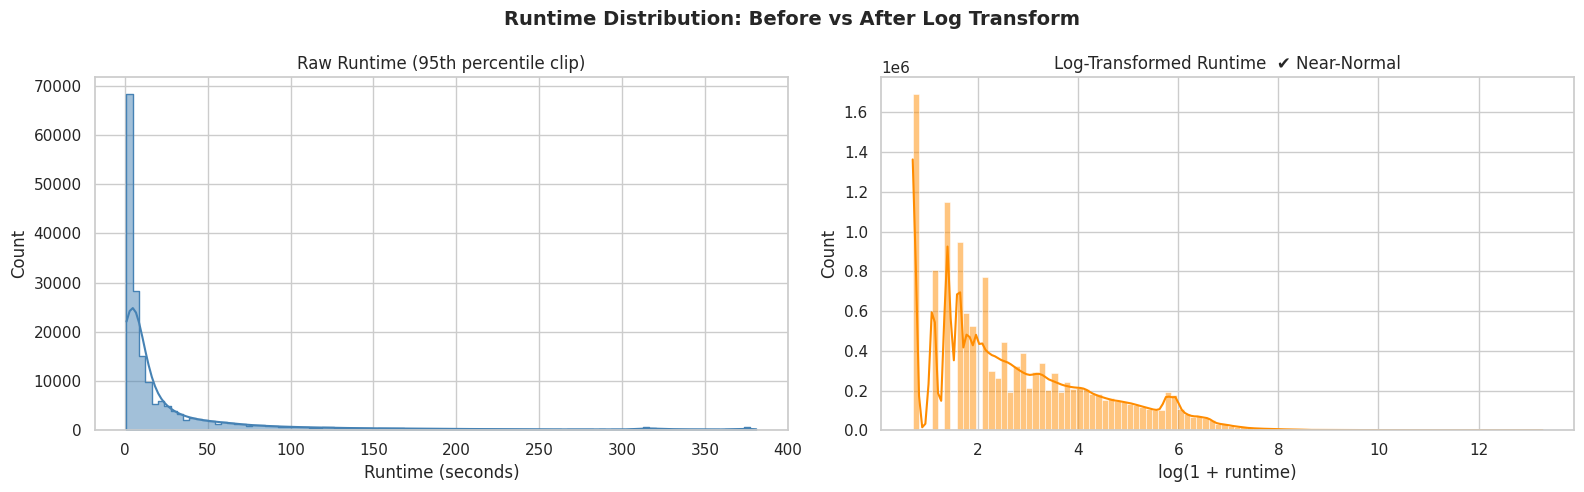

Runtime stats:
  Min:    1s
  Median: 9s
  Mean:   96s
  Max:    583886s


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Runtime Distribution: Before vs After Log Transform", fontsize=14, fontweight='bold')

sample_df = df.sample(n=min(200_000, len(df)), random_state=42)
upper_95  = np.percentile(sample_df['runtime'], 95)

# Raw runtime (clipped to 95th percentile for readability)
sns.histplot(
    sample_df[sample_df['runtime'] < upper_95]['runtime'],
    bins=100, kde=True, ax=axes[0], color='steelblue', element="step"
)
axes[0].set_title("Raw Runtime (95th percentile clip)")
axes[0].set_xlabel("Runtime (seconds)")

# Log-transformed runtime
df['log_runtime'] = np.log1p(df['runtime'])
sns.histplot(df['log_runtime'], bins=100, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title("Log-Transformed Runtime  ✔ Near-Normal")
axes[1].set_xlabel("log(1 + runtime)")

plt.tight_layout()
plt.show()

print(f"Runtime stats:")
print(f"  Min:    {df['runtime'].min():.0f}s")
print(f"  Median: {df['runtime'].median():.0f}s")
print(f"  Mean:   {df['runtime'].mean():.0f}s")
print(f"  Max:    {df['runtime'].max():.0f}s")


### 4.2 — Job Status / Failure Rate

The `status_code` column tells us what happened to each task.
Understanding the **class balance** is critical before building any failure prediction model —
heavily imbalanced classes (e.g. 99% success, 1% failure) require special handling like SMOTE or
class-weight adjustments.


/tmp/ipykernel_732/949062785.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[0], palette='viridis')


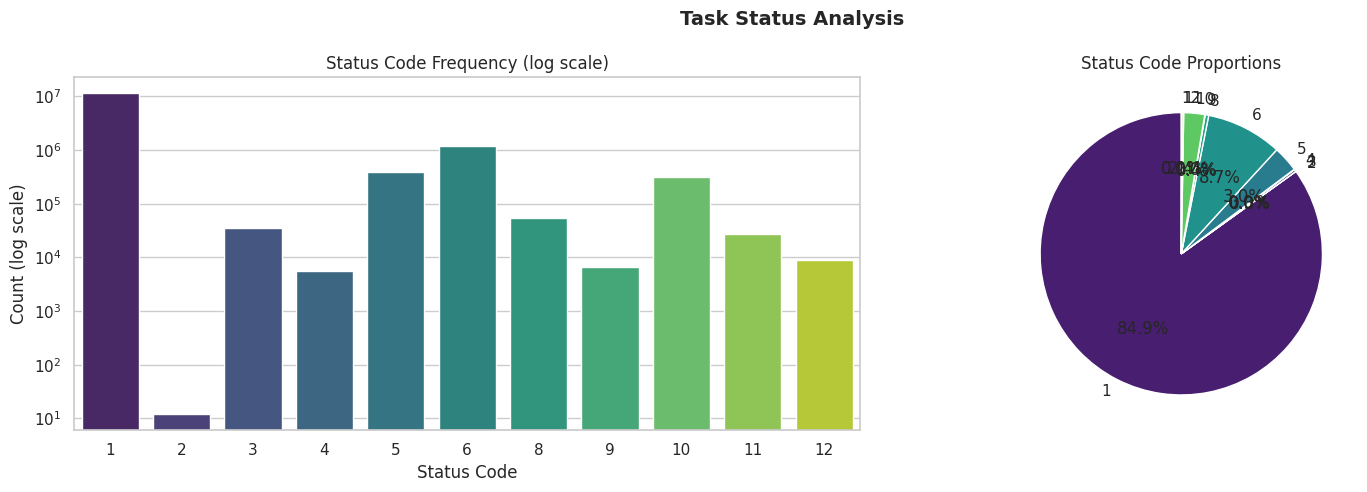


=== Class Proportions (%) ===
status_code
1     84.92
6      8.70
5      2.96
10     2.39
8      0.40
3      0.26
11     0.21
12     0.07
9      0.05
4      0.04
2      0.00
Name: proportion, dtype: float64


In [ ]:
# ── Status code distribution ────────────────────────────────────────────────
# Common Alibaba 2018 status codes:
#   1 = Terminated (success)
#   3 = Failed
#   5 = Cancelled
#   6 = Interrupted / Preempted

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Task Status Analysis", fontsize=14, fontweight='bold')

status_counts = df['status_code'].value_counts().sort_index()

sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[0], palette='viridis')
axes[0].set_yscale('log')
axes[0].set_title("Status Code Frequency (log scale)")
axes[0].set_xlabel("Status Code")
axes[0].set_ylabel("Count (log scale)")

# Pie chart for proportions
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(status_counts)))
axes[1].set_title("Status Code Proportions")

plt.tight_layout()
plt.show()

print("\n=== Class Proportions (%) ===")
print((df['status_code'].value_counts(normalize=True) * 100).round(2))


### 4.3 — Feature Correlations

Quick correlation check between numerical features to understand relationships before modelling.


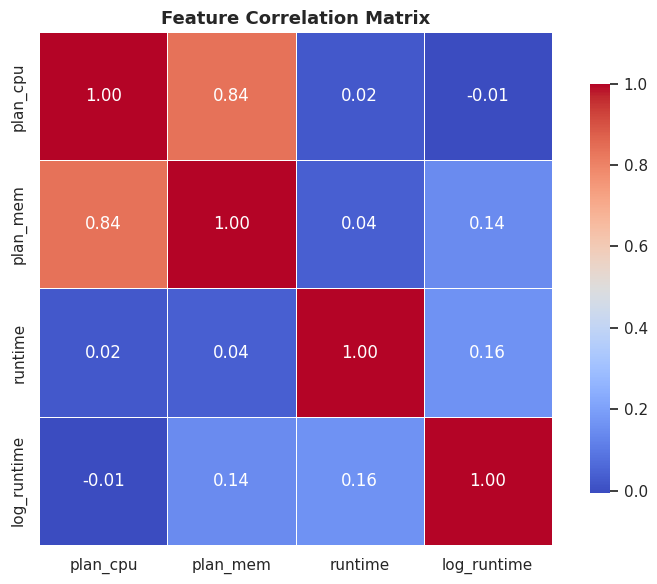

In [ ]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
numeric_cols = ['plan_cpu', 'plan_mem', 'runtime', 'log_runtime']
corr_matrix  = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Section 5 — Feature Engineering

### 5.1 — Target Labels

We create two prediction targets that will be used by different ML models:

- **`log_runtime`** → continuous target for *runtime prediction* (regression)
- **`is_failed`** → binary target for *failure prediction* (classification)


In [ ]:
# ── Derived targets ──────────────────────────────────────────────────────────
# log_runtime already computed in Section 4.1

# Binary failure label — adjust status code for 'Failed' based on your data's mapping
df['is_failed'] = (df['status_code'] == 3).astype(int)

print("Failure rate: {:.2f}%".format(df['is_failed'].mean() * 100))
print(f"Total failed tasks: {df['is_failed'].sum():,}")
print(f"Total tasks: {len(df):,}")


Failure rate: 0.26%
Total failed tasks: 34,831
Total tasks: 13,446,871


### 5.2 — DAG-based Features from `task_name`

The `task_name` field encodes the task's position in a job's dependency graph (DAG).  
For example, `M1_2_M3` means this task depends on `M1` and `M2`.

We can extract:
- `dag_depth` — how many upstream dependencies the task has (a proxy for scheduling delay)
- `is_root_task` — whether this task is independent (no dependencies, can run immediately)


In [ ]:
# ── DAG depth from task_name ─────────────────────────────────────────────────
# task_name format: "M<id>_<upstream1>_<upstream2>_..."
# Number of underscores after the first segment indicates dependency count

def extract_dag_depth(task_name):
    """Estimate dependency depth from the task_name string."""
    if pd.isna(task_name):
        return 0
    parts = str(task_name).split('_')
    # parts[0] is the task id, remaining parts are dependencies
    return max(0, len(parts) - 1)

df['dag_depth']    = df['task_name'].apply(extract_dag_depth)
df['is_root_task'] = (df['dag_depth'] == 0).astype(int)

print("DAG depth distribution:")
print(df['dag_depth'].value_counts().sort_index().head(10))
print(f"\nRoot tasks (no dependencies): {df['is_root_task'].sum():,} ({df['is_root_task'].mean()*100:.1f}%)")


DAG depth distribution:
dag_depth
0    4941030
1    6924465
2    1037460
3     303945
4     121265
5      49797
6      26645
7      14170
8      10391
9       5062
Name: count, dtype: int64

Root tasks (no dependencies): 4,941,030 (36.7%)


---
## 🔗 Section 6 — Enrichment: Merging `batch_instance.csv`

`batch_instance.csv` adds instance-level context that the task table doesn't have:
- `machine_id` — which machine ran this task (useful for correlating machine health with failures)
- `seq_no` — the retry count (how many times was this task attempted before finishing?)

A high `seq_no` is a strong signal of reliability problems.

> ⚠️ **Memory warning:** `batch_instance.csv` is very large. We load only 2M rows and use
> `category` dtype to reduce RAM usage by ~10x for string columns.


In [ ]:
import gc

# ── Load a memory-efficient sample of batch_instance ────────────────────────
instance_cols = ['job_name', 'task_name', 'machine_id', 'seq_no', 'start_time', 'end_time']

instances = pd.read_csv(
    '/content/batch_instance.csv',
    header=None,
    names=instance_cols,
    usecols=[0, 1, 6, 7, 4, 5],
    nrows=2_000_000,
    low_memory=False
)

# ── Optimize dtypes immediately (saves ~60% RAM) ─────────────────────────────
instances['job_name']  = instances['job_name'].astype('category')
instances['task_name'] = instances['task_name'].astype('category')

instances['start_time'] = pd.to_numeric(instances['start_time'], errors='coerce')
instances['end_time']   = pd.to_numeric(instances['end_time'],   errors='coerce')
instances['instance_runtime'] = instances['end_time'] - instances['start_time']
instances['seq_no'] = pd.to_numeric(instances['seq_no'], errors='coerce').fillna(1).astype('int16')

print(f"Instances loaded: {len(instances):,}")
print(f"Memory: {instances.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Instances loaded: 2,000,000
Memory: 374.1 MB


In [ ]:
# ── Aggregate instance features per task ────────────────────────────────────
# Instead of exploding rows with a row-level merge, we aggregate first
# → keeps the dataset at task-level (one row per task)

instance_agg = instances.groupby(['job_name', 'task_name'], observed=True).agg(
    max_seq_no        = ('seq_no', 'max'),       # highest retry count
    n_instances       = ('machine_id', 'count'), # how many instances ran
    avg_inst_runtime  = ('instance_runtime', 'mean'),
    unique_machines   = ('machine_id', 'nunique')
).reset_index()

print("Instance aggregation shape:", instance_agg.shape)
display(instance_agg.head())

# ── Clean up raw instances from memory ──────────────────────────────────────
del instances
gc.collect()
print("\n✅ Memory cleaned.")

Instance aggregation shape: (1998902, 6)


,job_name,task_name,max_seq_no,n_instances,avg_inst_runtime,unique_machines
0,ins_1000002027,R4_3,-27639,1,NaN,1
1,ins_1000002092,R4_3,-27637,1,NaN,1
2,ins_1000002164,R4_3,-27637,1,NaN,1
3,ins_1000002239,R4_3,-27636,1,NaN,1
4,ins_1000002317,R4_3,-27647,1,NaN,1



✅ Memory cleaned.


In [ ]:
# ── Align dtypes before merge ────────────────────────────────────────────────
df['job_name']  = df['job_name'].astype('category')
df['task_name'] = df['task_name'].astype('category')

# ── Merge enriched features into main task dataframe ────────────────────────
enriched_df = pd.merge(
    df,
    instance_agg,
    on=['job_name', 'task_name'],
    how='left'   # keep all tasks, even those with no matching instances
)

# Free up memory from original df
del df
gc.collect()

# Fill NaN for tasks with no instances in our sample
enriched_df['max_seq_no']       = enriched_df['max_seq_no'].fillna(1)
enriched_df['n_instances']      = enriched_df['n_instances'].fillna(0)
enriched_df['avg_inst_runtime'] = enriched_df['avg_inst_runtime'].fillna(enriched_df['runtime'])

print(f"✅ Enriched dataset shape: {enriched_df.shape}")
enriched_df.info()

✅ Enriched dataset shape: (13446871, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13446871 entries, 0 to 13446870
Data columns (total 17 columns):
 #   Column            Dtype  
---  ------            -----  
 0   task_name         object 
 1   inst_num          object 
 2   job_name          object 
 3   status_code       int32  
 4   start_time        int32  
 5   end_time          int32  
 6   plan_cpu          float32
 7   plan_mem          float32
 8   runtime           int32  
 9   log_runtime       float64
 10  is_failed         int64  
 11  dag_depth         int64  
 12  is_root_task      int64  
 13  max_seq_no        float64
 14  n_instances       float64
 15  avg_inst_runtime  float64
 16  unique_machines   float64
dtypes: float32(2), float64(5), int32(4), int64(3), object(3)
memory usage: 1.4+ GB


---
## 🖥️ Section 7 — Machine Usage: `machine_usage_bigger.csv`

This file contains per-machine resource usage sampled every **60 seconds** and averaged over **300-second windows**.

We use it to:
1. Build a time-series dataset for **resource utilization prediction**
2. Compute machine-level statistics that can be joined with job data to understand **where a job ran and what the machine load was**

The key columns are: `machine_id`, `timestamp`, `cpu_util`, `mem_util`


In [ ]:
# ── Load machine usage ──────────────────────────────────────────────────────
usage_cols = ['machine_id', 'timestamp', 'cpu_util', 'mem_util']

usage = pd.read_csv(
    '/content/machine_usage_bigger.csv',
    header=None,
    names=usage_cols,
    usecols=[0, 1, 2, 3],
    nrows=2_000_000,
    low_memory=False
)

# ── Force numeric types (handles embedded string headers from corruption) ────
for col in ['timestamp', 'cpu_util', 'mem_util']:
    usage[col] = pd.to_numeric(usage[col], errors='coerce')

# Drop rows where timestamp couldn't be converted (corrupt rows)
usage = usage.dropna(subset=['timestamp'])

print(f"Usage rows loaded: {len(usage):,}")
print(usage.describe())


Usage rows loaded: 1,999,999
          timestamp      cpu_util      mem_util
count  1.999999e+06  1.999999e+06  1.999999e+06
mean   3.752632e+05  3.660072e+01  8.758204e+01
std    1.883214e+05  1.675438e+01  1.555394e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    2.270300e+05  2.700000e+01  8.800000e+01
50%    3.814800e+05  3.600000e+01  9.100000e+01
75%    5.355500e+05  4.700000e+01  9.400000e+01
max    6.911900e+05  9.800000e+01  9.800000e+01


### 7.1 — Aggregate into 5-Minute Buckets

We bucket timestamps into **5-minute intervals (300 seconds)** and compute per-machine aggregated stats.
This gives us a clean time-series at a granularity that matches the trace's averaging window.


In [ ]:
# ── 5-minute time bucketing ──────────────────────────────────────────────────
usage['time_bucket'] = (usage['timestamp'] // 300) * 300

machine_state = usage.groupby(['machine_id', 'time_bucket']).agg(
    avg_cpu = ('cpu_util', 'mean'),
    max_cpu = ('cpu_util', 'max'),
    avg_mem = ('mem_util', 'mean'),
    max_mem = ('mem_util', 'max'),
).reset_index()

# Flatten column names
machine_state.columns = ['machine_id', 'time_bucket', 'avg_cpu', 'max_cpu', 'avg_mem', 'max_mem']

print(f"✅ Machine state table shape: {machine_state.shape}")
display(machine_state.head())

# Free memory
del usage
gc.collect()


✅ Machine state table shape: (589365, 6)


,machine_id,time_bucket,avg_cpu,max_cpu,avg_mem,max_mem
0,m_1932,386400.0,42.666667,44.0,92.000000,92.0
1,m_1932,386700.0,45.000000,46.0,92.500000,93.0
2,m_1932,387000.0,45.200000,47.0,93.000000,93.0
3,m_1932,387300.0,46.000000,46.0,93.000000,93.0
4,m_1932,387600.0,72.000000,75.0,96.666667,97.0


38

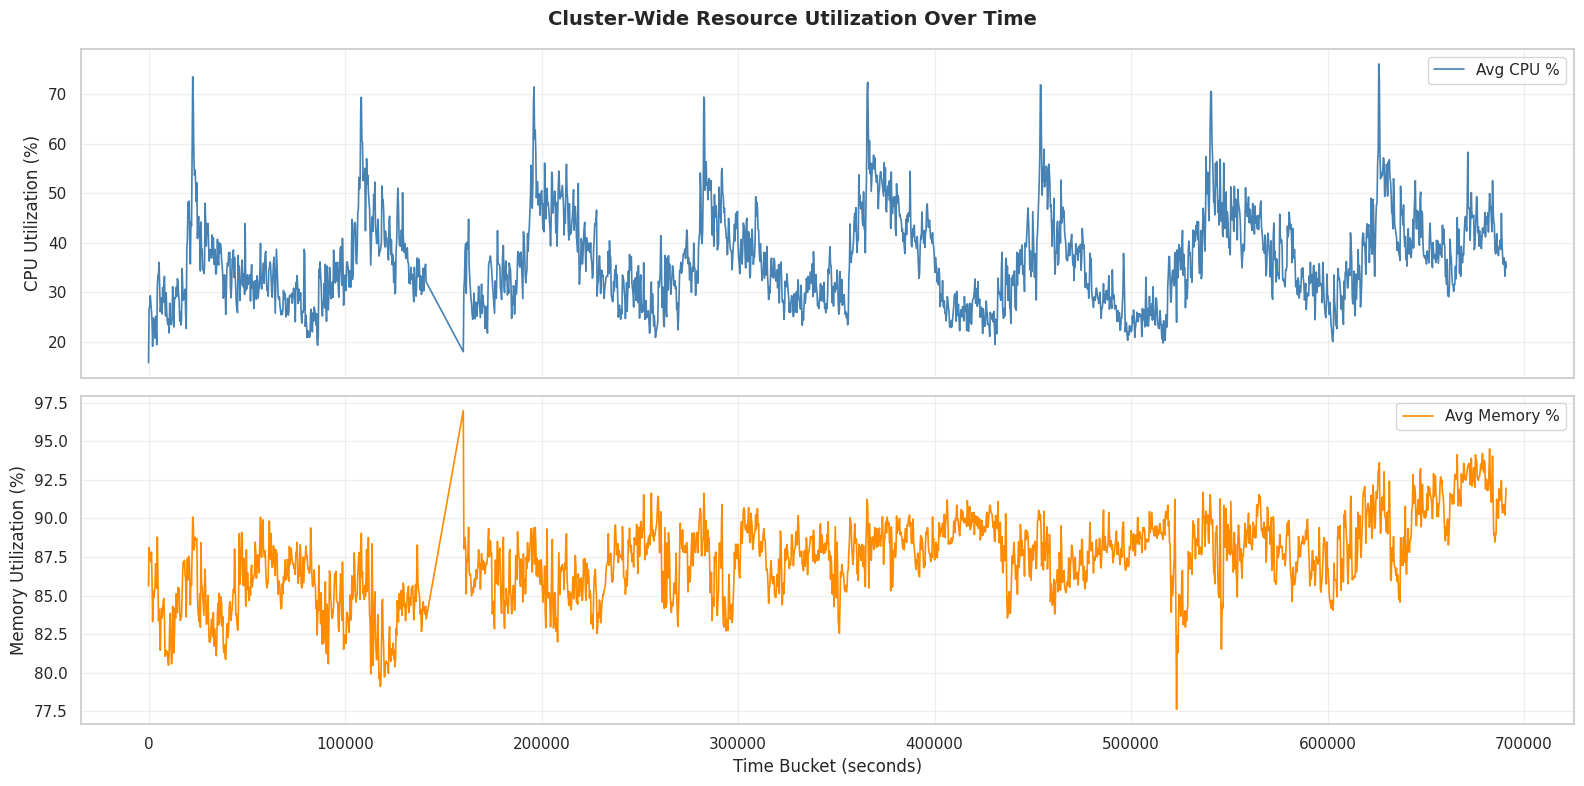

In [ ]:
# ── Cluster-wide resource usage over time ────────────────────────────────────
cluster_over_time = machine_state.groupby('time_bucket').agg(
    cluster_avg_cpu = ('avg_cpu', 'mean'),
    cluster_avg_mem = ('avg_mem', 'mean'),
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle("Cluster-Wide Resource Utilization Over Time", fontsize=14, fontweight='bold')

ax1.plot(cluster_over_time['time_bucket'], cluster_over_time['cluster_avg_cpu'],
         color='steelblue', linewidth=1.2, label='Avg CPU %')
ax1.set_ylabel("CPU Utilization (%)")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(cluster_over_time['time_bucket'], cluster_over_time['cluster_avg_mem'],
         color='darkorange', linewidth=1.2, label='Avg Memory %')
ax2.set_ylabel("Memory Utilization (%)")
ax2.set_xlabel("Time Bucket (seconds)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 💾 Section 8 — Final Dataset Summary & Export

We now have a clean, feature-rich dataset ready for ML training. Here's a summary of all features:

| Feature | Type | Description |
|---|---|---|
| `plan_cpu` | float | Requested CPU (normalised 0–100) |
| `plan_mem` | float | Requested memory (normalised 0–100) |
| `inst_num` | int | Number of instances in this task |
| `dag_depth` | int | Dependency depth in the job DAG |
| `is_root_task` | int | 1 if no upstream dependencies |
| `max_seq_no` | int | Max retry count across instances |
| `n_instances` | int | Number of instances in our sample |
| `avg_inst_runtime` | float | Average instance runtime |
| **`log_runtime`** | float | **Target: regression (runtime prediction)** |
| **`is_failed`** | int | **Target: classification (failure prediction)** |


In [ ]:
# ── Final dataset report ─────────────────────────────────────────────────────
print("=" * 55)
print("       FINAL TRAINING DATASET SUMMARY")
print("=" * 55)
print(f"  Shape:          {enriched_df.shape}")
print(f"  Memory usage:   {enriched_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Failure rate:   {enriched_df['is_failed'].mean()*100:.2f}%")
print(f"  Median runtime: {enriched_df['runtime'].median():.0f}s")
print(f"  Missing values: {enriched_df.isnull().sum().sum()}")
print("=" * 55)

display(enriched_df[['plan_cpu', 'plan_mem', 'inst_num', 'dag_depth',
                      'max_seq_no', 'log_runtime', 'is_failed']].describe())


       FINAL TRAINING DATASET SUMMARY
  Shape:          (13446871, 17)
  Memory usage:   3408.2 MB
  Failure rate:   0.26%
  Median runtime: 9s
  Missing values: 13446871


,plan_cpu,plan_mem,dag_depth,max_seq_no,log_runtime,is_failed
count,1.344687e+07,1.344687e+07,1.344687e+07,13446871.0,1.344687e+07,1.344687e+07
mean,8.365075e+01,3.487923e-01,8.330920e-01,1.0,2.738667e+00,2.590268e-03
std,6.240459e+01,2.909909e-01,9.751859e-01,0.0,1.660715e+00,5.082872e-02
min,5.000000e+00,2.000000e-02,0.000000e+00,1.0,6.931472e-01,0.000000e+00
25%,5.000000e+01,2.000000e-01,0.000000e+00,1.0,1.386294e+00,0.000000e+00
50%,1.000000e+02,3.000000e-01,1.000000e+00,1.0,2.302585e+00,0.000000e+00
75%,1.000000e+02,3.900000e-01,1.000000e+00,1.0,3.806662e+00,0.000000e+00
max,1.000000e+03,1.717000e+01,1.900000e+01,1.0,1.327746e+01,1.000000e+00


In [ ]:
# ── Diagnose the column shift first ────────────────────
print("Original dtypes before cleaning:")
print(enriched_df.dtypes)
print("\nFirst 10 rows of inst_num, task_name, job_name:")
print(enriched_df[['inst_num', 'task_name', 'job_name']].head(10))

# ── Clean enriched_df before saving ─────────────────────

# Force inst_num to numeric ─ coerce bad values to NaN
enriched_df['inst_num'] = pd.to_numeric(enriched_df['inst_num'], errors='coerce')

# Drop string columns entirely ─ they have no use in ML training
cols_to_drop = ['job_name', 'task_name']
enriched_df  = enriched_df.drop(columns=cols_to_drop, errors='ignore')

# Verify no object columns remain
obj_cols = enriched_df.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f"\n☢─ Still has object columns: {obj_cols} ─ dropping them too")
    enriched_df = enriched_df.drop(columns=obj_cols)

print("\nCleaned dtypes:")
print(enriched_df.dtypes)
print(f"\nShape: {enriched_df.shape}")
print("First 3 rows after cleaning:")
print(enriched_df.head(3))

# ── Re-export ──────────────────────────────────────────
OUTPUT_PATH = PATHS['final_training_data']
enriched_df.to_parquet(OUTPUT_PATH, index=False)

print(f"\n✅ Saved clean {OUTPUT_PATH}")
print(f"   Rows:    {len(enriched_df):,}")
print(f"   Columns: {len(enriched_df.columns)}")
print(f"\nℹ️ Columns exported:")
for col in enriched_df.columns:
    print(f"   - {col}")

Original dtypes before cleaning:
task_name            object
inst_num             object
job_name             object
status_code           int32
start_time            int32
end_time              int32
plan_cpu            float32
plan_mem            float32
runtime               int32
log_runtime         float64
is_failed             int64
dag_depth             int64
is_root_task          int64
max_seq_no          float64
n_instances         float64
avg_inst_runtime    float64
unique_machines     float64
dtype: object

First 10 rows of inst_num, task_name, job_name:
  inst_num task_name job_name
0        1      R2_1      j_2
1        1        M1      j_2
2      371      R6_3      j_3
3     1111    J4_2_3      j_3
4        1      R2_1      j_3
5     1111    J8_3_7      j_3
6    12846        M3      j_3
7        1      R9_8      j_3
8      371      R1_3      j_3
9        1      R5_4      j_3

Cleaned dtypes:
inst_num              int64
status_code           int32
start_time            int

In [ ]:
# ── Export machine state for utilization/anomaly models ───────────────
machine_state.to_parquet(PATHS['machine_state'], index=False)
print("✅ machine_state.parquet saved.")

✅ machine_state.parquet saved.


---
## 🚀 Section 9 — Next Steps

With the clean datasets in hand, here's the roadmap to build the full scheduler ML pipeline:

### Immediate Next Steps

1. **Runtime Prediction (Regression)**
   - Features: `plan_cpu`, `plan_mem`, `inst_num`, `dag_depth`, `is_root_task`
   - Target: `log_runtime`
   - Models: XGBoost, LightGBM, Random Forest
   - Metric: MAE on original scale (after inverse log transform)

2. **Failure Prediction (Classification)**
   - Features: same as above + `max_seq_no`, `avg_inst_runtime`
   - Target: `is_failed`
   - ⚠️ Handle class imbalance: use `class_weight='balanced'` or SMOTE
   - Models: LightGBM, Logistic Regression baseline
   - Metric: F1-score, AUC-ROC

3. **Resource Utilization Prediction (Time-Series Regression)**
   - Input: `machine_state.csv` (5-min buckets)
   - Approach: sliding window features (lag-3, lag-5) → predict next CPU/Mem
   - Models: XGBoost with lag features, or LSTM

4. **Anomaly Detection (Unsupervised)**
   - Input: `machine_state.csv`
   - Approach: IsolationForest or Autoencoder on per-machine z-score features
   - Flag machines where `max_cpu` > mean + 3σ

5. **Workload Clustering (Unsupervised)**
   - Input: `final_training_data.csv`
   - Approach: K-Means / HDBSCAN on `plan_cpu`, `plan_mem`, `inst_num`, `dag_depth`
   - Use cluster IDs as categorical features in supervised models

### Connecting to the Scheduler
Once models are trained, the scheduler can:
- **Pre-screen submissions** → predict failure probability before allocating resources
- **Bin-pack intelligently** → predict runtime to avoid co-scheduling long jobs
- **React to anomalies** → reroute jobs away from machines flagged as unhealthy

---
*Notebook built on Alibaba Cluster Trace v2018 · github.com/alibaba/clusterdata*


---
## ⏱️ Section 10 — Model 1: Runtime Prediction (Regression)

### Overview

Before a job scheduler allocates resources, it needs to answer: **"How long will this job take?"**

Without a runtime estimate, schedulers are forced to use worst-case reservations — wasting cluster
capacity. With a good prediction, the scheduler can:
- **Bin-pack** short jobs together without blocking long ones
- **Set realistic deadlines** to catch straggler jobs early
- **Prioritise** jobs that are close to their estimated finish

### Approach

We train three tree-based regressors on the task-level features engineered in Section 5 and evaluate them against each other.

```
Input features  →  Model  →  predict log_runtime  →  expm1()  →  predicted seconds
```

The full pipeline for this section:

1. **Prepare** — select features, split train/test
2. **Train** — XGBoost · LightGBM · Random Forest
3. **Evaluate** — MAE / RMSE / R² on the *original* second scale
4. **Analyse** — residual plots + feature importance
5. **Save** — export the best model for the scheduler


In [ ]:
# Top of Section 10 ─ resume without re-running Sections 1-8
import os
import pandas as pd
if os.path.exists(PATHS['final_training_data']):
    df = pd.read_parquet(PATHS['final_training_data'])
    print(f"✅ Loaded df from Drive: {df.shape}")
else:
    print("❌ final_training_data.parquet not found ─ run Sections 1-8 first")

✅ Loaded df from Drive: (13446871, 15)


---
### 10.1 — Installs & Imports


In [ ]:
# Install any missing libraries (safe to re-run)
!pip install xgboost lightgbm scikit-learn --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib

from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing   import StandardScaler
from xgboost                 import XGBRegressor
from lightgbm                import LGBMRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

print("✅ All imports OK")


✅ All imports OK


---
### 10.2 — Feature Selection & Train/Test Split

We use the five task-level features that are **available at submission time** — i.e. information
the scheduler *already knows* before the job starts running. This is critical: we must never
use features that are only known *after* execution (like `actual_cpu_usage`), or the model
would be cheating.

| Feature | Why it helps predict runtime |
|---|---|
| `plan_cpu` | More CPU → often longer, parallelisable jobs |
| `plan_mem` | Memory-heavy jobs tend to be data-intensive |
| `inst_num` | More instances = more total work |
| `dag_depth` | Deeper dependencies = more sequential stages |
| `is_root_task` | Root tasks often start fast; leaf tasks wait |

We use an **80/20 stratified split** — stratified by a binned version of `log_runtime` so that
short, medium, and long jobs are all represented equally in both train and test sets.


In [ ]:
# ── Load the final training dataset ──────────────────────────────
df = pd.read_parquet(PATHS['final_training_data'])

# ── Feature set: only pre-submission information ─────────────
FEATURES = ['plan_cpu', 'plan_mem', 'dag_depth', 'is_root_task']
TARGET   = 'log_runtime'

# Drop rows where target or any feature is NaN
model_df = df[FEATURES + [TARGET, 'runtime']].dropna()

X = model_df[FEATURES]
y = model_df[TARGET]

print(f"Dataset for modelling: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target range: log_runtime ∈ [{y.min():.2f}, {y.max():.2f}]")
print(f"  → original runtime ∈ [{np.expm1(y.min()):.0f}s, {np.expm1(y.max()):.0f}s]")

Dataset for modelling: 13,446,871 rows × 4 features
Target range: log_runtime ∈ [0.69, 13.28]
  → original runtime ∈ [1s, 583886s]


In [ ]:
# ── Stratified train / test split ────────────────────────────────────────────
# We bin log_runtime into 10 quantile buckets so that split preserves distribution shape

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_bins
)

# Also keep the original-scale runtime for evaluation reporting
_, runtime_test = train_test_split(
    model_df['runtime'],
    test_size=0.2,
    random_state=42,
    stratify=y_bins
)

print(f"Train set: {len(X_train):,} rows")
print(f"Test  set: {len(X_test):,}  rows")


Train set: 10,757,496 rows
Test  set: 2,689,375  rows


---
### 10.3 — Training Three Models

We train XGBoost, LightGBM, and Random Forest with sensible defaults.
All three are **gradient-boosted or ensemble tree** methods — they handle the non-linear
relationships in cluster data well and require minimal feature scaling.

> 💡 We use `n_jobs=-1` everywhere to utilise all Colab CPU cores.


In [ ]:
# ── Model definitions ────────────────────────────────────────────────────────
models = {
    "XGBoost": XGBRegressor(
        n_estimators     = 500,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,      # L1 regularisation
        reg_lambda       = 1.0,      # L2 regularisation
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = -1,        # unlimited; LightGBM uses num_leaves instead
        num_leaves      = 63,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        reg_alpha       = 0.1,
        reg_lambda      = 1.0,
        random_state    = 42,
        n_jobs          = -1,
        verbose         = -1,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators = 300,
        max_depth    = 20,
        min_samples_leaf = 10,      # prevents overfitting on tiny leaf nodes
        random_state = 42,
        n_jobs       = -1,
    ),
}

print("Models configured:")
for name in models:
    print(f"  • {name}")


Models configured:
  • XGBoost
  • LightGBM
  • Random Forest


In [ ]:
print(X_train.dtypes[X_train.dtypes == 'object'])

Series([], dtype: object)


In [ ]:
# ── Train all models & record timing ─────────────────────────────────────────
trained_models = {}
train_times    = {}

for name, model in models.items():
    print(f"Training {name} ...", end=" ")
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    trained_models[name] = model
    train_times[name]    = elapsed
    print(f"done in {elapsed:.1f}s")

print("\n✅ All models trained.")


Training XGBoost ... done in 347.7s
Training LightGBM ... done in 235.2s
Training Random Forest ... done in 2959.3s

✅ All models trained.


---
### 10.4 — Evaluation

We evaluate on the held-out test set using three metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | mean\|y − ŷ\| | Average prediction error **in seconds** (after inverse transform) |
| **RMSE** | √mean(y − ŷ)² | Penalises large errors more than MAE — sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Fraction of variance explained; 1.0 = perfect, 0 = mean baseline |

> ⚠️ **Key step:** we apply `np.expm1()` (the inverse of `log1p`) to convert predictions
> back to seconds before computing MAE/RMSE. Reporting error in log-space would be meaningless
> to anyone reading the results.


In [ ]:
# ── Predict and evaluate on original (second) scale ─────────────────────────
results = {}

for name, model in trained_models.items():
    y_pred_log = model.predict(X_test)

    # Inverse log transform → back to seconds
    y_pred_sec = np.expm1(y_pred_log)
    y_true_sec = np.expm1(y_test)

    mae  = mean_absolute_error(y_true_sec, y_pred_sec)
    rmse = np.sqrt(mean_squared_error(y_true_sec, y_pred_sec))
    r2   = r2_score(y_test, y_pred_log)   # R² in log-space (normalised, fairer)

    results[name] = {
        'MAE (s)':  mae,
        'RMSE (s)': rmse,
        'R²':       r2,
        'Train time (s)': train_times[name],
        'y_pred_log': y_pred_log,
        'y_pred_sec': y_pred_sec,
    }

# ── Print comparison table ────────────────────────────────────────────────────
print(f"{'Model':<20} {'MAE (s)':>12} {'RMSE (s)':>12} {'R²':>8} {'Train (s)':>12}")
print("─" * 68)
for name, r in results.items():
    print(f"{name:<20} {r['MAE (s)']:>12.1f} {r['RMSE (s)']:>12.1f} {r['R²']:>8.4f} {r['Train time (s)']:>12.1f}")

# Identify best model by MAE
best_name = min(results, key=lambda n: results[n]['MAE (s)'])
print(f"\n🏆 Best model (lowest MAE): {best_name}")


Model                     MAE (s)     RMSE (s)       R²    Train (s)
────────────────────────────────────────────────────────────────────
XGBoost                      83.4       1465.7   0.3845        347.7
LightGBM                     82.9       1401.4   0.3868        235.2
Random Forest                82.8       1386.6   0.3868       2959.3

🏆 Best model (lowest MAE): Random Forest


---
### 10.5 — Visualisation

Three diagnostic plots:

1. **Metric comparison bar chart** — quick visual ranking of all three models
2. **Predicted vs Actual scatter** — ideal model = points along the diagonal
3. **Residual distribution** — residuals should be centred on 0; a skewed residual
   distribution means the model is systematically over- or under-predicting a range


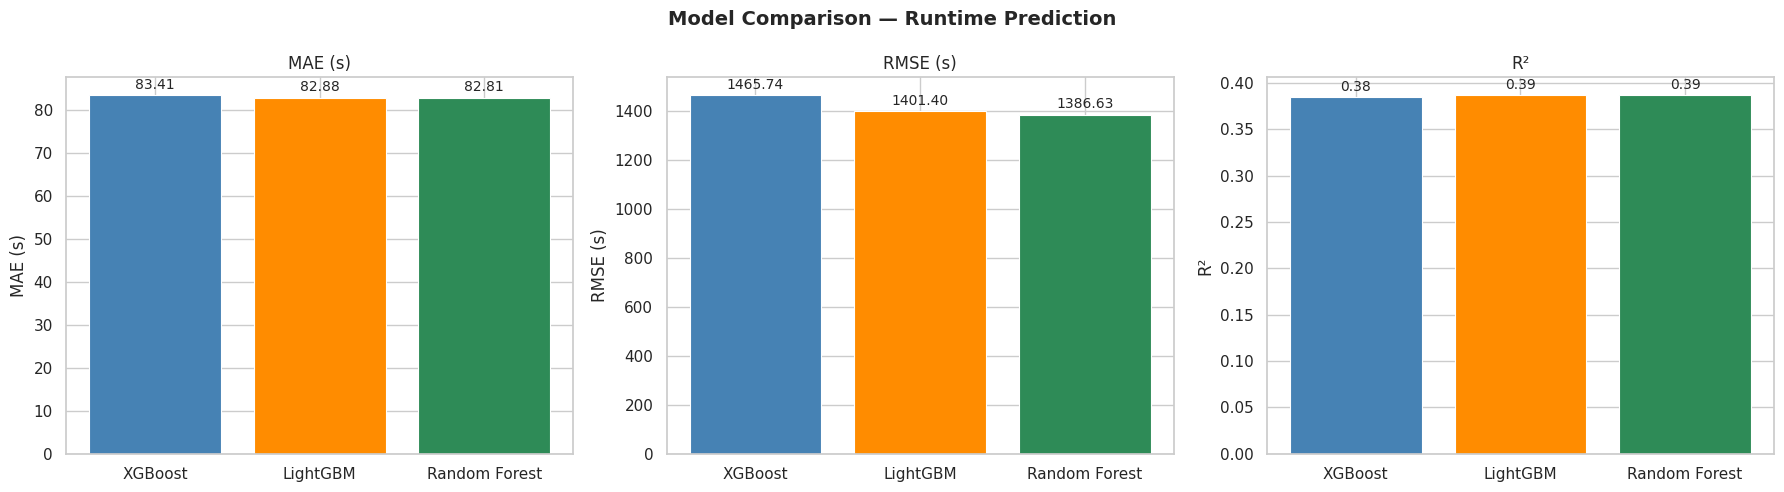

In [ ]:
# ── Plot 1: Metric comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison — Runtime Prediction", fontsize=14, fontweight='bold')

model_names = list(results.keys())
colors      = ['steelblue', 'darkorange', 'seagreen']

for ax, metric in zip(axes, ['MAE (s)', 'RMSE (s)', 'R²']):
    vals = [results[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    # Annotate bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


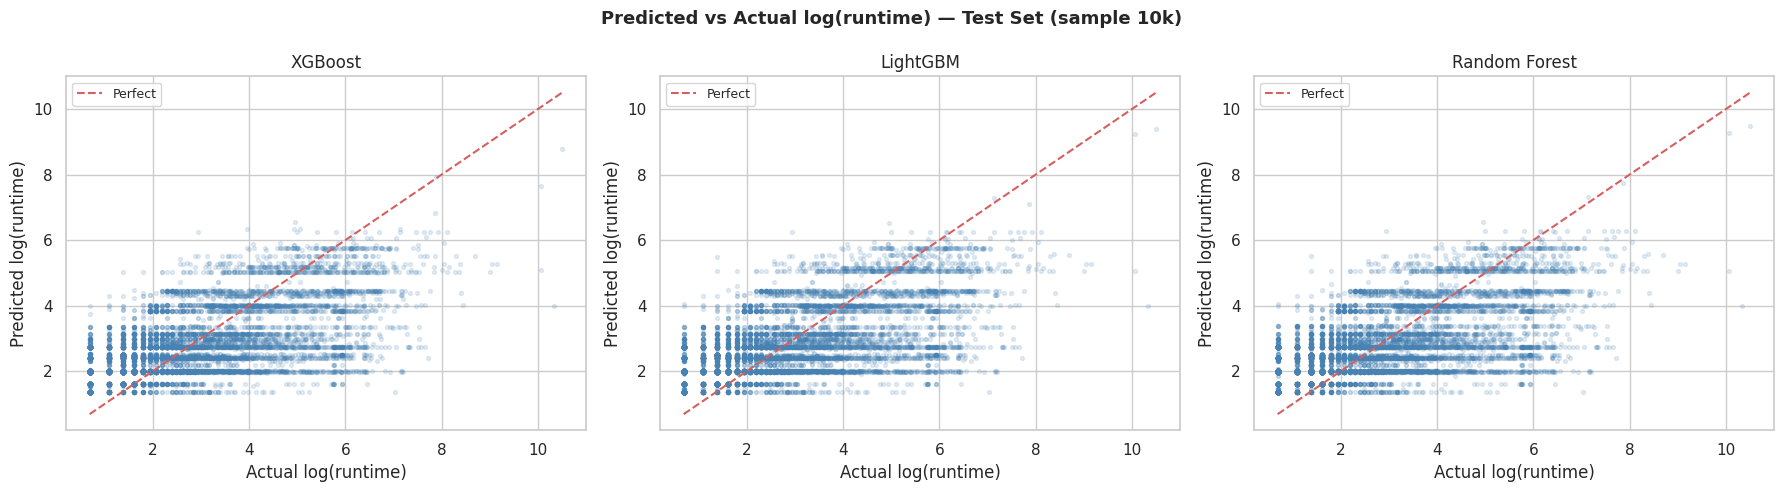

In [ ]:
# ── Plot 2: Predicted vs Actual (log scale) ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Predicted vs Actual log(runtime) — Test Set (sample 10k)", fontsize=13, fontweight='bold')

sample_idx = np.random.choice(len(y_test), size=min(10_000, len(y_test)), replace=False)
y_true_sample = np.array(y_test)[sample_idx]

for ax, (name, r) in zip(axes, results.items()):
    y_pred_sample = r['y_pred_log'][sample_idx]

    ax.scatter(y_true_sample, y_pred_sample, alpha=0.15, s=8, color='steelblue', rasterized=True)

    # Perfect prediction line
    lo, hi = y_true_sample.min(), y_true_sample.max()
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect')

    ax.set_title(name)
    ax.set_xlabel("Actual log(runtime)")
    ax.set_ylabel("Predicted log(runtime)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


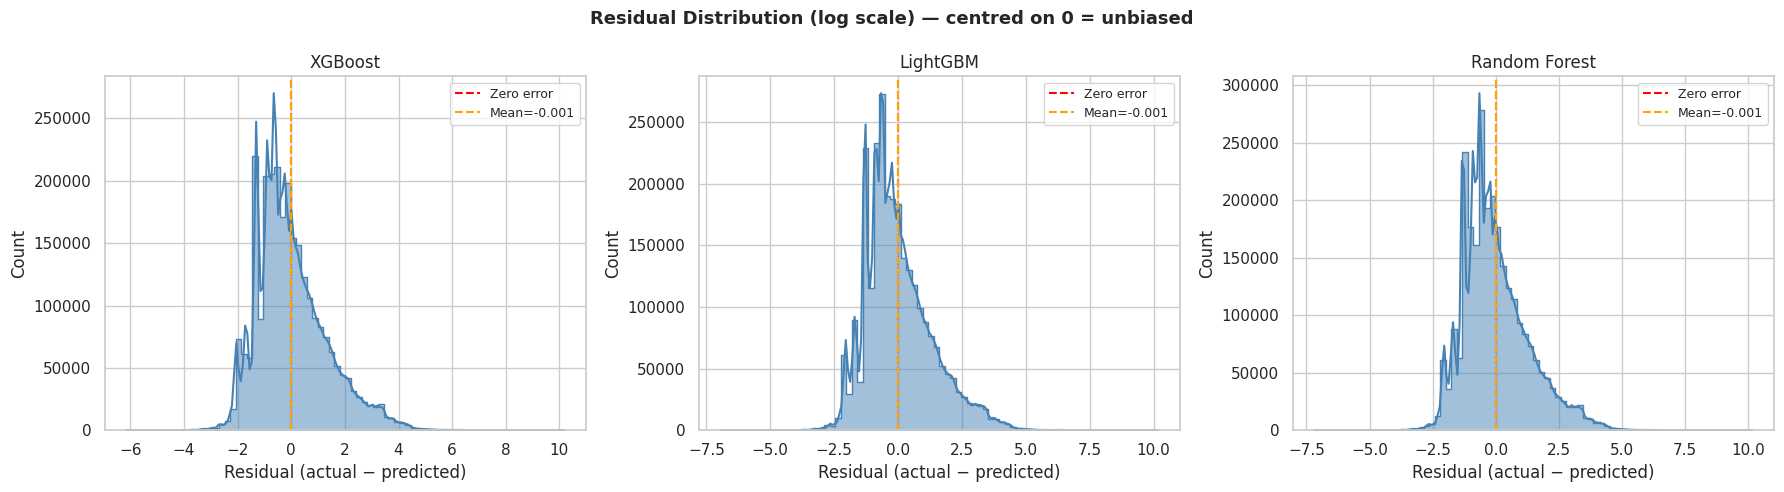

In [ ]:
# ── Plot 3: Residual distributions ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Residual Distribution (log scale) — centred on 0 = unbiased", fontsize=13, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    residuals = np.array(y_test) - r['y_pred_log']

    sns.histplot(residuals, bins=80, kde=True, ax=ax, color='steelblue', element='step')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
    ax.axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Mean={residuals.mean():.3f}')

    ax.set_title(name)
    ax.set_xlabel("Residual (actual − predicted)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
### 10.6 — Feature Importance

Feature importance tells us **which inputs drive predictions most**. This is useful for:
- **Debugging** — if an unimportant feature is dominating, something is wrong
- **Compression** — drop low-importance features to speed up inference
- **Insight** — understanding what the scheduler should pay most attention to

We plot importance from all three models side by side. XGBoost and LightGBM report
gain-based importance (how much each split improves the objective); Random Forest reports
mean impurity decrease.


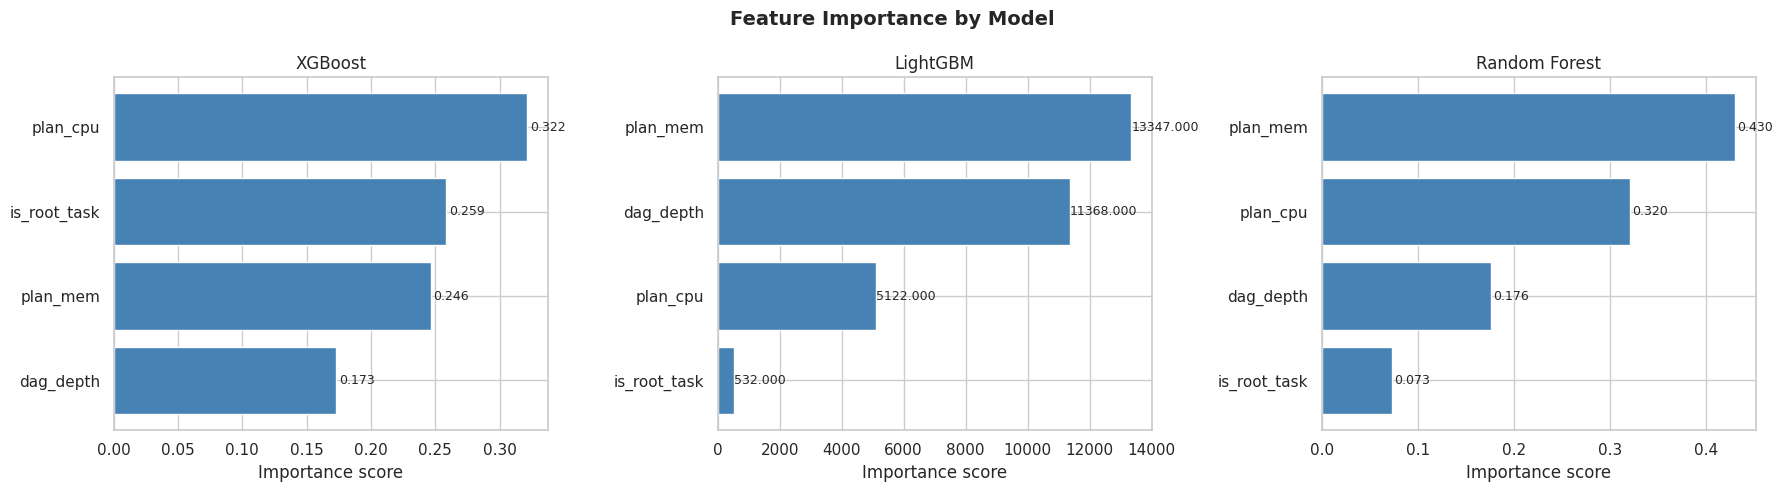

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Feature Importance by Model", fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, trained_models.items()):
    importances = model.feature_importances_
    order       = np.argsort(importances)[::-1]
    sorted_feat = [FEATURES[i] for i in order]
    sorted_imp  = importances[order]

    bars = ax.barh(sorted_feat[::-1], sorted_imp[::-1], color='steelblue', edgecolor='white')
    ax.set_title(name)
    ax.set_xlabel("Importance score")

    # Annotate
    for bar, val in zip(bars, sorted_imp[::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


---
### 10.7 — Error Analysis: Where Does the Model Struggle?

A good model is not just one with a low average error — it's one whose errors are
**predictable and bounded**. We bin predictions by runtime bucket to see whether errors
grow for longer jobs (a common failure mode in regression on skewed targets).


Error breakdown by runtime bucket — Random Forest
bucket   count   median_mae  median_pct
  <10s 1355722     4.972435  120.219265
10s–1m  765016    12.601696   55.024490
  1–5m  366311    78.027565   75.768955
 5–30m  190610   362.777475   87.869973
30m–3h   10685  2634.988735   95.666599
   >3h    1031 23637.988735   99.379196


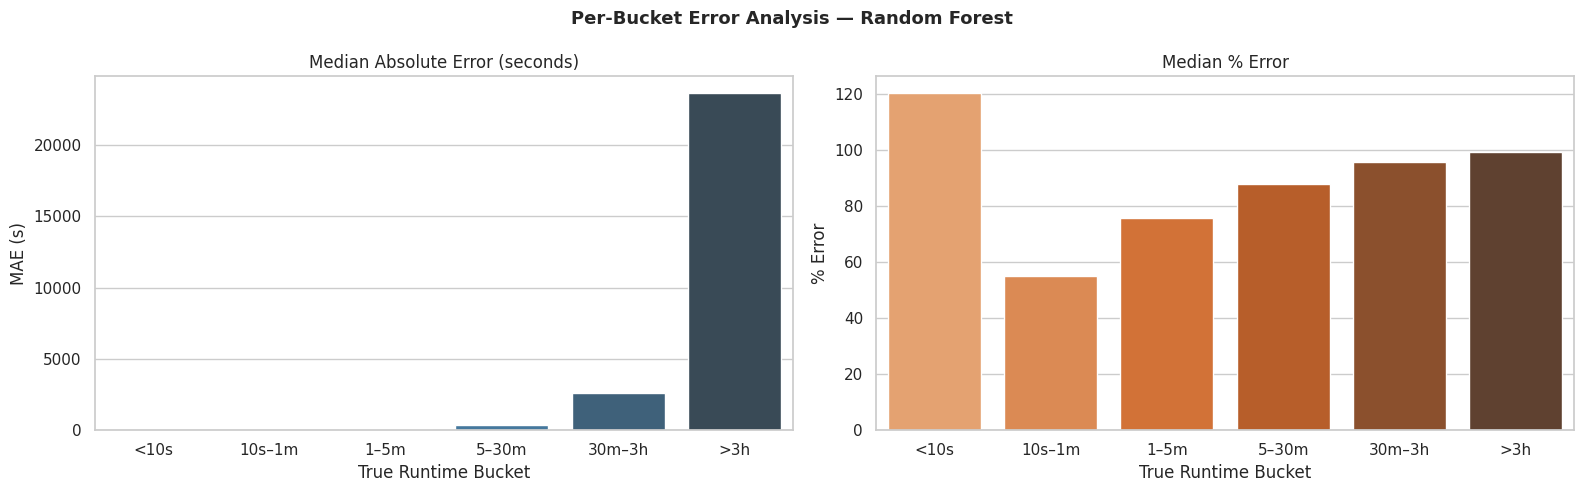

In [ ]:
# ── Per-bucket error analysis ────────────────────────────────────────────────
best_model  = trained_models[best_name]
y_pred_best = results[best_name]['y_pred_sec']
y_true_sec  = np.expm1(np.array(y_test))

error_df = pd.DataFrame({
    'true_runtime_s': y_true_sec,
    'pred_runtime_s': y_pred_best,
    'abs_error_s':    np.abs(y_true_sec - y_pred_best),
    'pct_error':      np.abs(y_true_sec - y_pred_best) / (y_true_sec + 1) * 100
})

# Bin by true runtime (log-scale boundaries for readability)
bins   = [0, 10, 60, 300, 1_800, 10_800, np.inf]
labels = ['<10s', '10s–1m', '1–5m', '5–30m', '30m–3h', '>3h']
error_df['bucket'] = pd.cut(error_df['true_runtime_s'], bins=bins, labels=labels)

bucket_stats = error_df.groupby('bucket', observed=True).agg(
    count       = ('abs_error_s', 'count'),
    median_mae  = ('abs_error_s', 'median'),
    median_pct  = ('pct_error',   'median'),
).reset_index()

print(f"Error breakdown by runtime bucket — {best_name}")
print(bucket_stats.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"Per-Bucket Error Analysis — {best_name}", fontsize=13, fontweight='bold')

sns.barplot(data=bucket_stats, x='bucket', y='median_mae',  ax=ax1, palette='Blues_d')
ax1.set_title("Median Absolute Error (seconds)")
ax1.set_xlabel("True Runtime Bucket")
ax1.set_ylabel("MAE (s)")

sns.barplot(data=bucket_stats, x='bucket', y='median_pct', ax=ax2, palette='Oranges_d')
ax2.set_title("Median % Error")
ax2.set_xlabel("True Runtime Bucket")
ax2.set_ylabel("% Error")

plt.tight_layout()
plt.show()


---
### 10.8 — Save the Best Model

We save the best-performing model as a `.pkl` file using `joblib`.
This is what the scheduler will load at inference time to get a predicted runtime
for every incoming job submission.

The inference call at scheduling time will look like:

```python
model = joblib.load('runtime_predictor.pkl')
features = [[plan_cpu, plan_mem, inst_num, dag_depth, is_root_task]]
log_pred  = model.predict(features)[0]
seconds   = np.expm1(log_pred)          # convert back to seconds
```


In [ ]:
import joblib

MODEL_PATH = PATHS['runtime_model']

joblib.dump(trained_models[best_name], MODEL_PATH)

print(f"✅ Best model saved: {MODEL_PATH}")
print(f"   Model:  {best_name}")
print(f"   MAE:    {results[best_name]['MAE (s)']:.1f} seconds")
print(f"   R²:     {results[best_name]['R²']:.4f}")

# ── Quick sanity check: reload and predict on one example ─────────────────
loaded_model = joblib.load(MODEL_PATH)

example = pd.DataFrame({
    'plan_cpu':    [10.0],   # 10% CPU requested
    'plan_mem':    [20.0],   # 20% memory requested
    'dag_depth':   [2],      # 2 upstream dependencies
    'is_root_task': [0],     # not a root task
})

pred_log = loaded_model.predict(example)[0]
pred_sec = np.expm1(pred_log)

print(f"\n🔮 Example prediction:")
print(f"   Input:           {example.iloc[0].to_dict()}")
print(f"   Predicted log:   {pred_log:.4f}")
print(f"   Predicted time:  {pred_sec:.1f} seconds  ({pred_sec/60:.1f} minutes)")

✅ Best model saved: /content/drive/MyDrive/job_scheduler/runtime_predictor.pkl
   Model:  Random Forest
   MAE:    82.8 seconds
   R²:     0.3868

🔮 Example prediction:
   Input:           {'plan_cpu': 10.0, 'plan_mem': 20.0, 'dag_depth': 2.0, 'is_root_task': 0.0}
   Predicted log:   4.9253
   Predicted time:  136.7 seconds  (2.3 minutes)


---
## ❌ Section 11 — Model 2: Failure Prediction (Classification)

### Overview

A scheduler that can predict **which jobs are likely to fail** before they run can:
- **Avoid wasting cluster resources** on doomed jobs
- **Alert users** to fix misconfigured submissions before they queue
- **Re-route** fragile jobs to more stable machines
- **Prioritise retries** intelligently rather than blindly re-queuing

### The Class Imbalance Problem

This is not a standard balanced classification problem. In production clusters,
failures are **rare events** — typically 1–5% of all tasks. A naive model that
predicts "success" for everything achieves 98% accuracy but is completely useless.

```
Naive model accuracy:  98%   ← meaningless
Naive model recall:     0%   ← catches zero failures
```

We must use metrics and techniques designed for imbalanced data:

| Technique | What it does |
|---|---|
| `class_weight='balanced'` | Penalises misclassifying the minority class more heavily |
| **SMOTE** | Synthetically generates new minority-class samples in feature space |
| **F1-score** | Harmonic mean of precision and recall — punishes ignoring failures |
| **AUC-ROC** | Area under the ROC curve — threshold-independent performance measure |
| **PR-AUC** | Area under Precision-Recall curve — better than ROC for heavy imbalance |

### Pipeline

```
Features  →  SMOTE (train only)  →  LightGBM / Logistic Regression
          →  Evaluate: F1, AUC-ROC, PR-AUC, Confusion Matrix
          →  Threshold tuning  →  Save best model
```


---
### 11.1 — Installs & Imports

In [ ]:
# Top of Section 11 ─ resume without re-running Sections 1-8
import os
import pandas as pd
if os.path.exists(PATHS['final_training_data']):
    df = pd.read_parquet(PATHS['final_training_data'])
    print(f"✅ Loaded df for Section 11 from Drive: {df.shape}")
else:
    print("❌ final_training_data.parquet not found ─ run Sections 1-8 first")

✅ Loaded df for Section 11 from Drive: (13446871, 15)


In [ ]:
!pip install lightgbm imbalanced-learn scikit-learn --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
import gc

from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, roc_curve
)
from sklearn.pipeline        import Pipeline
from lightgbm                import LGBMClassifier
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
print("✅ All imports OK")

✅ All imports OK


---
### 11.2 — Load Data & Inspect Class Balance

Before touching any model, we must understand exactly how imbalanced the dataset is.
The **imbalance ratio** determines which strategy to use:

| Ratio | Recommended approach |
|---|---|
| 80/20 or better | `class_weight='balanced'` alone is usually enough |
| 95/5 to 99/1 | SMOTE + `class_weight='balanced'` |
| >99/1 | SMOTE + cost-sensitive loss + anomaly detection methods |


In [ ]:
TARGET   = 'is_failed'
FEATURES = ['plan_cpu', 'plan_mem', 'dag_depth', 'is_root_task',
            'max_seq_no', 'avg_inst_runtime']

# ── Step 1: Peek at 5 rows to confirm column names exist ──────────────────────
peek = pd.read_parquet(PATHS['final_training_data'], columns=FEATURES + [TARGET]).head(5)
print("Columns in file:", peek.columns.tolist())
print(peek[FEATURES + [TARGET]].head())
del peek; gc.collect()

Columns in file: ['plan_cpu', 'plan_mem', 'dag_depth', 'is_root_task', 'max_seq_no', 'avg_inst_runtime', 'is_failed']
   plan_cpu  plan_mem  dag_depth  is_root_task  max_seq_no  avg_inst_runtime  \
0      50.0      0.20          1             0         1.0              10.0   
1      50.0      0.20          0             1         1.0               7.0   
2     100.0      0.49          1             0         1.0              28.0   
3     100.0      0.59          2             0         1.0              47.0   
4     100.0      0.39          1             0         1.0               6.0   

   is_failed  
0          0  
1          0  
2          0  
3          0  
4          0  


0

In [ ]:
TARGET   = 'is_failed'
FEATURES = ['plan_cpu', 'plan_mem', 'dag_depth', 'is_root_task',
            'max_seq_no', 'avg_inst_runtime']

# ── Load only the columns we actually need ──────────────────────
# Reading all columns then dropping is wasteful ─ specify usecols upfront
df = pd.read_parquet(
    PATHS['final_training_data'],
    columns    = FEATURES + [TARGET]
)

print(f"Loaded:  {len(df):,} rows  |  {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ── Drop NaN in-place (no copy) ────────────────────────
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"After dropna: {len(df):,} rows  |  {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ── Extract X and y ─ views, not copies ─────────────────────
# .values gives a numpy array that shares memory with the DataFrame column
X = df[FEATURES].values.astype('float32')
y = df[TARGET].values.astype('int8')

# ── Drop the DataFrame immediately ─ X and y are all we need now ────────
del df
gc.collect()

print(f"X shape: {X.shape}  |  {X.nbytes / 1e6:.1f} MB")
print(f"y shape: {y.shape}  |  {y.nbytes / 1e6:.1f} MB")

# ── Class balance report ───────────────────────────
print("=" * 45)
print("      CLASS BALANCE REPORT")
print("=" * 45)
n_total   = len(y)
n_failed  = int(y.sum())
n_success = n_total - n_failed
ratio     = n_success / max(n_failed, 1)

print(f"  Total tasks:     {n_total:>10,}")
print(f"  Success  (0):    {n_success:>10,}  ({n_success/n_total*100:.2f}%)")
print(f"  Failed   (1):    {n_failed:>10,}  ({n_failed/n_total*100:.2f}%)")
print(f"  Imbalance ratio: {ratio:.1f} : 1")
print("=" * 45)

if ratio > 50:
    print("⚠️  Severe ─ SMOTE + class_weight='balanced'")
elif ratio > 10:
    print("⚠️  Moderate ─ SMOTE + class_weight='balanced'")
else:
    print("✅ Mild ─ class_weight='balanced' alone may suffice")

Loaded:  13,446,871 rows  |  645.4 MB
After dropna: 13,446,871 rows  |  645.4 MB
X shape: (13446871, 6)  |  322.7 MB
y shape: (13446871,)  |  13.4 MB
      CLASS BALANCE REPORT
  Total tasks:     13,446,871
  Success  (0):    13,412,040  (99.74%)
  Failed   (1):        34,831  (0.26%)
  Imbalance ratio: 385.1 : 1
⚠️  Severe ─ SMOTE + class_weight='balanced'


✅ All imports OK


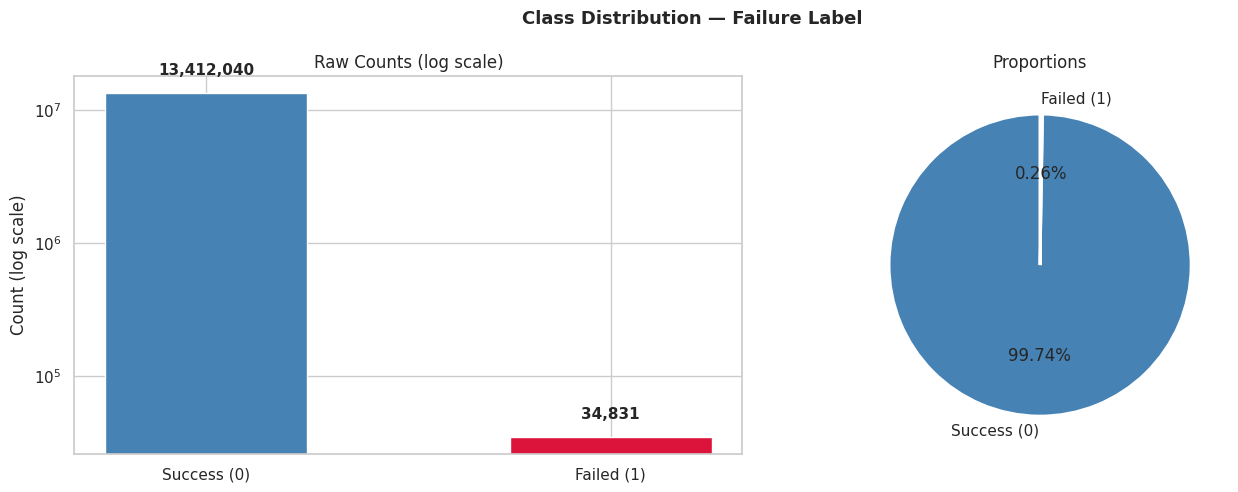

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib

from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, roc_curve
)
from sklearn.pipeline        import Pipeline
from lightgbm                import LGBMClassifier
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
print("✅ All imports OK")

# ── Visualise class balance ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distribution — Failure Label", fontsize=13, fontweight='bold')

# Bar chart (log scale to see the minority class)
counts = pd.Series(y).value_counts().sort_index()
labels = ['Success (0)', 'Failed (1)']
bars   = ax1.bar(labels, counts.values, color=['steelblue', 'crimson'], edgecolor='white', width=0.5)
ax1.set_yscale('log')
ax1.set_title("Raw Counts (log scale)")
ax1.set_ylabel("Count (log scale)")
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
ax2.pie(counts.values, labels=labels, autopct='%1.2f%%',
        colors=['steelblue', 'crimson'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title("Proportions")

plt.tight_layout()
plt.show()

---
### 11.3 — Stratified Train/Test Split

We use `stratify=y` to ensure the failure rate is **identical in both train and test sets**.
Without stratification, the test set could have zero failures by random chance at high imbalance ratios.

> ⚠️ **SMOTE is applied only to the training set.** Applying it before splitting would
> cause data leakage — synthetic test samples would share information with training samples,
> artificially inflating evaluation scores.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       # critical for imbalanced data
)

print(f"Train set: {len(X_train):,} rows  |  failure rate: {y_train.mean()*100:.2f}%")
print(f"Test  set: {len(X_test):,}  rows  |  failure rate: {y_test.mean()*100:.2f}%")
print("\n✅ Failure rates match — stratification successful.")


Train set: 10,757,496 rows  |  failure rate: 0.26%
Test  set: 2,689,375  rows  |  failure rate: 0.26%

✅ Failure rates match — stratification successful.


---
### 11.4 — Handling Imbalance with SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) generates new synthetic failure
samples by interpolating between existing ones in feature space — not by simply duplicating.

```
For each minority sample:
  1. Find its k nearest minority neighbours
  2. Pick one at random
  3. Create a new point anywhere on the line segment between them
```

We target a **1:3 minority-to-majority ratio** (not 1:1) because going to 50/50 on a
severely imbalanced dataset tends to overfit the synthetic samples. A 1:3 ratio gives
the model enough signal without oversynthesising.

> SMOTE operates **after scaling** — distances are only meaningful in a normalised feature space.


In [ ]:
from imblearn.over_sampling import SMOTE

# ── Scale features first (required for SMOTE distance calculations) ───────────
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # use train statistics only

# ── Apply SMOTE to training set only ─────────────────────────────────────────
n_failed_train  = y_train.sum()
n_success_train = len(y_train) - n_failed_train
target_ratio    = 1 / 3   # aim for ~25% failure rate in training data

smote = SMOTE(
    sampling_strategy = target_ratio,
    k_neighbors       = 5,
    random_state      = 42
)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Success: {n_success_train:,}  |  Failed: {n_failed_train:,}  |  Ratio: {n_success_train/max(n_failed_train,1):.1f}:1")
print(f"\nAfter SMOTE:")
n_f = y_train_resampled.sum()
n_s = len(y_train_resampled) - n_f
print(f"  Success: {n_s:,}  |  Failed: {n_f:,}  |  Ratio: {n_s/max(n_f,1):.1f}:1")
print(f"  Total training samples: {len(X_train_resampled):,}")


Before SMOTE:
  Success: 10,729,631  |  Failed: 27,865  |  Ratio: 385.1:1

After SMOTE:
  Success: 10,729,631  |  Failed: 3,576,543  |  Ratio: 3.0:1
  Total training samples: 14,306,174


---
### 11.5 — Training: LightGBM & Logistic Regression Baseline

We train two models:

**Logistic Regression** acts as an interpretable **baseline**. It tells us the minimum
performance a model should beat to be worth the extra complexity.

**LightGBM** is our main model — it handles non-linear feature interactions and is
fast enough for real-time scheduler inference. We use `class_weight='balanced'` on top
of SMOTE as a second line of defence against residual imbalance.


In [ ]:
from lightgbm import early_stopping, log_evaluation

# ── Logistic Regression baseline ─────────────────────────────────────────────
print("Training Logistic Regression baseline ...")
t0 = time.time()

lr = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    C            = 1.0,          # inverse regularisation strength
    solver       = 'lbfgs',
    random_state = 42,
    n_jobs       = -1
)
lr.fit(X_train_resampled, y_train_resampled)
lr_time = time.time() - t0
print(f"  Done in {lr_time:.1f}s")

# ── LightGBM classifier ───────────────────────────────────────────────────────
print("\nTraining LightGBM ...")
t0 = time.time()

lgbm = LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = -1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    class_weight      = 'balanced',  # second layer of imbalance handling
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)
lgbm.fit(
    X_train_resampled, y_train_resampled,
    eval_set              = [(X_test_scaled, y_test)],
    callbacks             = [early_stopping(50, verbose=False),
                              log_evaluation(period=-1)]
)
lgbm_time = time.time() - t0
print(f"  Done in {lgbm_time:.1f}s")

print("\n✅ Both models trained.")

Training Logistic Regression baseline ...
  Done in 39.3s

Training LightGBM ...
  Done in 581.5s

✅ Both models trained.


---
### 11.6 — Evaluation

For imbalanced classification we care about four metrics:

| Metric | Formula | What it means for us |
|---|---|---|
| **F1-score** | 2 × (P × R) / (P + R) | Balance between catching failures (recall) and not crying wolf (precision) |
| **AUC-ROC** | Area under ROC curve | How well the model ranks failures above successes across all thresholds |
| **PR-AUC** | Area under Precision-Recall | More informative than ROC under severe imbalance |
| **Recall** | TP / (TP + FN) | Fraction of actual failures we catch — **most important for a scheduler** |

> In a scheduler context, **missing a failure (false negative) is more costly than a
> false alarm (false positive)** — so we weight recall heavily.


In [ ]:
# ── Predict probabilities and hard labels ────────────────────────────────────
models_eval = {
    'Logistic Regression': lr,
    'LightGBM':            lgbm,
}

eval_results = {}

for name, model in models_eval.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)

    f1       = f1_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_prob)
    pr_auc   = average_precision_score(y_test, y_prob)
    report   = classification_report(y_test, y_pred, output_dict=True)

    eval_results[name] = {
        'F1':       f1,
        'AUC-ROC':  roc_auc,
        'PR-AUC':   pr_auc,
        'Precision': report['1']['precision'],
        'Recall':    report['1']['recall'],
        'y_prob':    y_prob,
        'y_pred':    y_pred,
    }

# ── Results table ─────────────────────────────────────────────────────────────
print(f"{'Model':<25} {'F1':>8} {'AUC-ROC':>10} {'PR-AUC':>10} {'Precision':>12} {'Recall':>10}")
print("─" * 78)
for name, r in eval_results.items():
    print(f"{name:<25} {r['F1']:>8.4f} {r['AUC-ROC']:>10.4f} {r['PR-AUC']:>10.4f} "
          f"{r['Precision']:>12.4f} {r['Recall']:>10.4f}")

best_name = max(eval_results, key=lambda n: eval_results[n]['F1'])
print(f"\n🏆 Best model (F1): {best_name}")


Model                           F1    AUC-ROC     PR-AUC    Precision     Recall
──────────────────────────────────────────────────────────────────────────────
Logistic Regression         0.0117     0.8688     0.0137       0.0059     0.9819
LightGBM                    0.0625     0.9886     0.5123       0.0323     0.9961

🏆 Best model (F1): LightGBM


In [ ]:
# ── Detailed classification report ───────────────────────────────────────────
print(f"=== {best_name} — Full Classification Report ===\n")
print(classification_report(
    y_test,
    eval_results[best_name]['y_pred'],
    target_names=['Success (0)', 'Failed (1)']
))


=== LightGBM — Full Classification Report ===

              precision    recall  f1-score   support

 Success (0)       1.00      0.92      0.96   2682409
  Failed (1)       0.03      1.00      0.06      6966

    accuracy                           0.92   2689375
   macro avg       0.52      0.96      0.51   2689375
weighted avg       1.00      0.92      0.96   2689375



---
### 11.7 — Visualisation

Four diagnostic plots:
1. **Confusion matrices** — absolute counts of TP/FP/TN/FN per model
2. **ROC curves** — both models on one axis for direct comparison
3. **Precision-Recall curves** — more informative than ROC under heavy imbalance
4. **Feature importance** — which features drive failure predictions


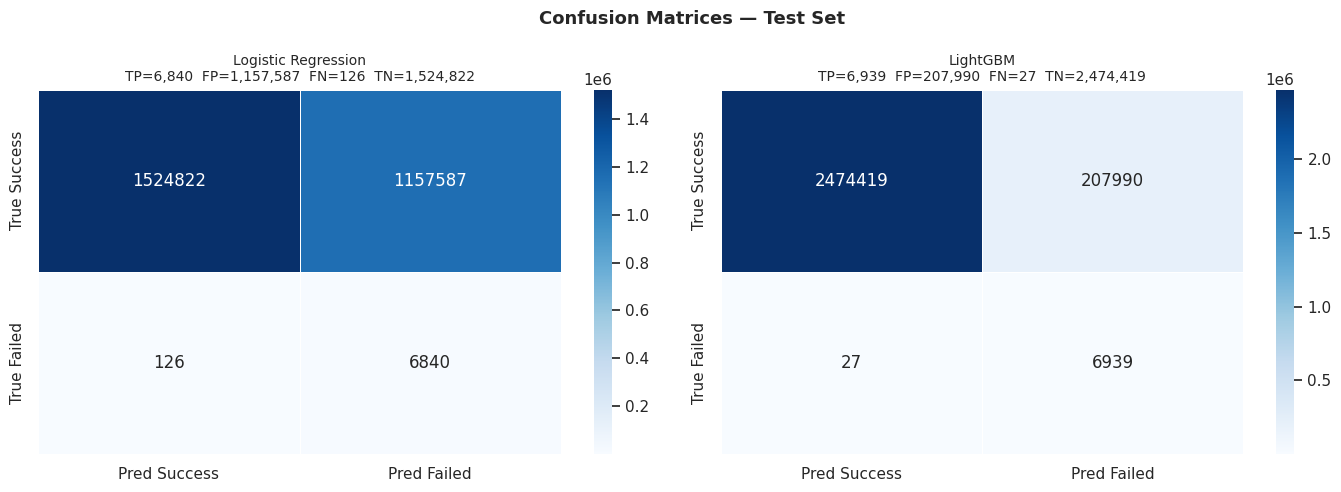

In [ ]:
# ── Plot 1: Confusion matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=13, fontweight='bold')

for ax, (name, r) in zip(axes, eval_results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=0.5,
        xticklabels=['Pred Success', 'Pred Failed'],
        yticklabels=['True Success', 'True Failed']
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nTP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}", fontsize=10)

plt.tight_layout()
plt.show()


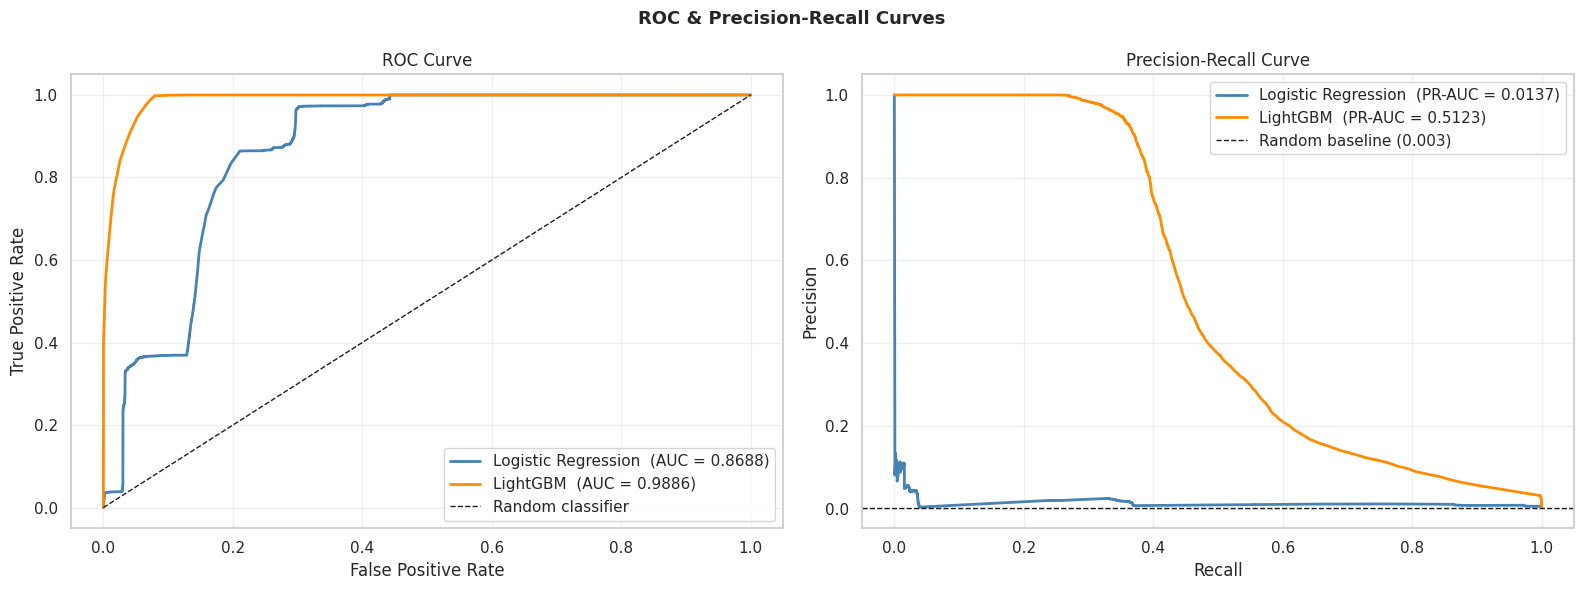

In [ ]:
# ── Plot 2: ROC curves (both models) ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ROC & Precision-Recall Curves", fontsize=13, fontweight='bold')

colors = ['steelblue', 'darkorange']

# ROC
for (name, r), color in zip(eval_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name}  (AUC = {r['AUC-ROC']:.4f})")

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Precision-Recall
for (name, r), color in zip(eval_results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    ax2.plot(rec, prec, color=color, linewidth=2,
             label=f"{name}  (PR-AUC = {r['PR-AUC']:.4f})")

baseline = y_test.mean()
ax2.axhline(baseline, color='k', linestyle='--', linewidth=1,
            label=f'Random baseline ({baseline:.3f})')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


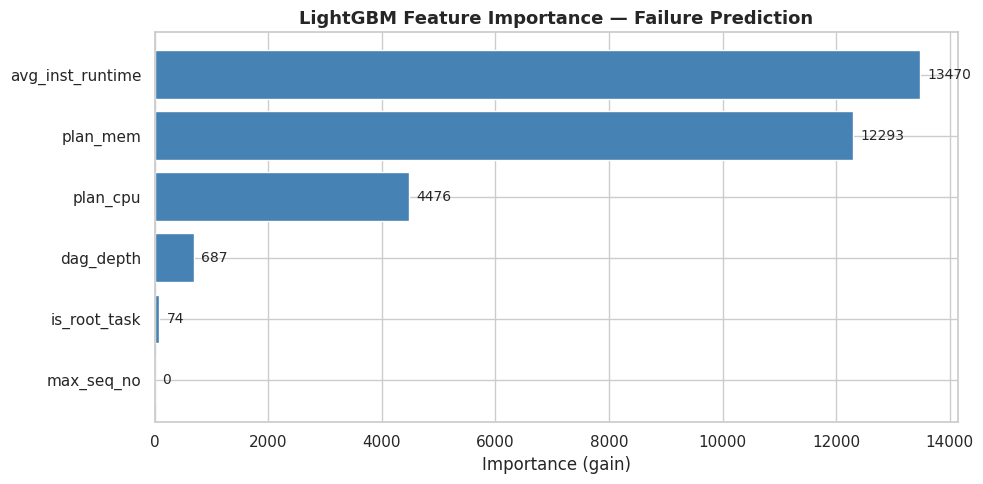

In [ ]:
# ── Plot 3: Feature importance (LightGBM) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

importances = lgbm.feature_importances_
order       = np.argsort(importances)
feat_sorted = [FEATURES[i] for i in order]
imp_sorted  = importances[order]

bars = ax.barh(feat_sorted, imp_sorted, color='steelblue', edgecolor='white')
ax.set_title("LightGBM Feature Importance — Failure Prediction", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (gain)")

for bar, val in zip(bars, imp_sorted):
    ax.text(val + imp_sorted.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


---
### 11.8 — Threshold Tuning

By default, classifiers predict "failed" when probability ≥ 0.5.
But the **optimal threshold depends on what we care about more** — precision or recall.

For a scheduler, missing a failure (false negative) wastes resources. So we want
**high recall even at the cost of precision**. We sweep all thresholds and find
the one that maximises F1 — then we can shift it lower if we want even more recall.

This is only done on the **best model** and evaluated on the test set.


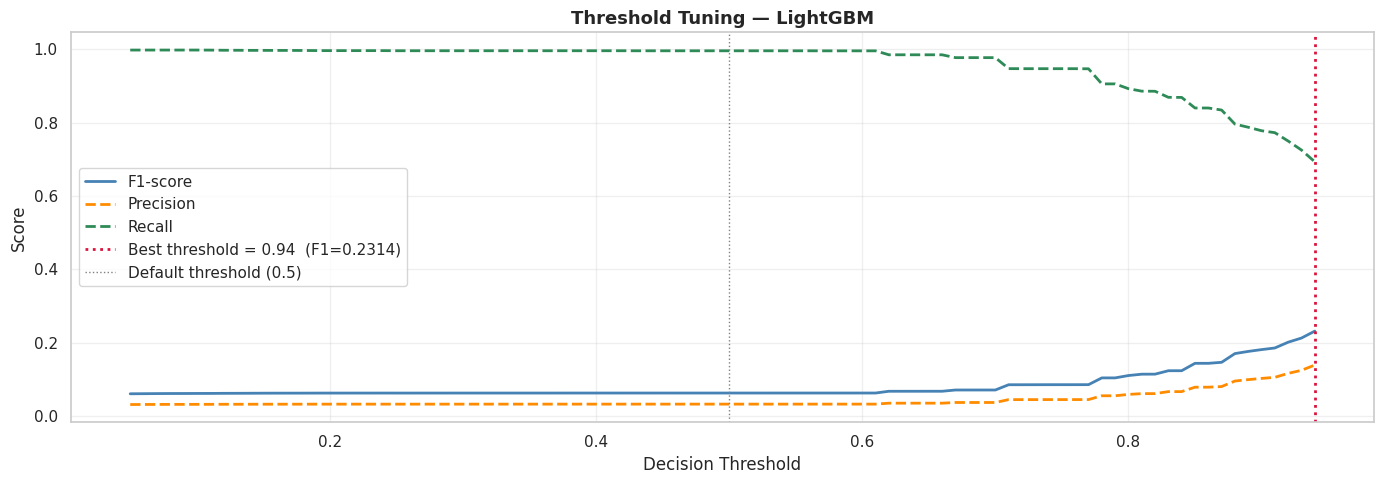

Default threshold (0.5):  F1 = 0.0625
Optimal threshold (0.94): F1 = 0.2314


In [ ]:
# ── Threshold sweep ──────────────────────────────────────────────────────────
best_model = lgbm if best_name == 'LightGBM' else lr
y_prob_best = eval_results[best_name]['y_prob']

thresholds  = np.arange(0.05, 0.95, 0.01)
f1_scores   = []
precisions  = []
recalls     = []

for thresh in thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    from sklearn.metrics import precision_score, recall_score
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))

best_thresh_idx = np.argmax(f1_scores)
best_thresh     = thresholds[best_thresh_idx]
best_f1         = f1_scores[best_thresh_idx]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(thresholds, f1_scores,  color='steelblue',   linewidth=2, label='F1-score')
ax.plot(thresholds, precisions, color='darkorange',  linewidth=2, label='Precision', linestyle='--')
ax.plot(thresholds, recalls,    color='seagreen',    linewidth=2, label='Recall',    linestyle='--')
ax.axvline(best_thresh, color='crimson', linestyle=':', linewidth=2,
           label=f'Best threshold = {best_thresh:.2f}  (F1={best_f1:.4f})')
ax.axvline(0.5, color='grey', linestyle=':', linewidth=1, label='Default threshold (0.5)')
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Tuning — {best_name}", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Default threshold (0.5):  F1 = {f1_scores[np.argmin(np.abs(thresholds - 0.5))]:.4f}")
print(f"Optimal threshold ({best_thresh:.2f}): F1 = {best_f1:.4f}")


=== LightGBM at threshold = 0.94 ===

              precision    recall  f1-score   support

 Success (0)       1.00      0.99      0.99   2682409
  Failed (1)       0.14      0.69      0.23      6966

    accuracy                           0.99   2689375
   macro avg       0.57      0.84      0.61   2689375
weighted avg       1.00      0.99      0.99   2689375



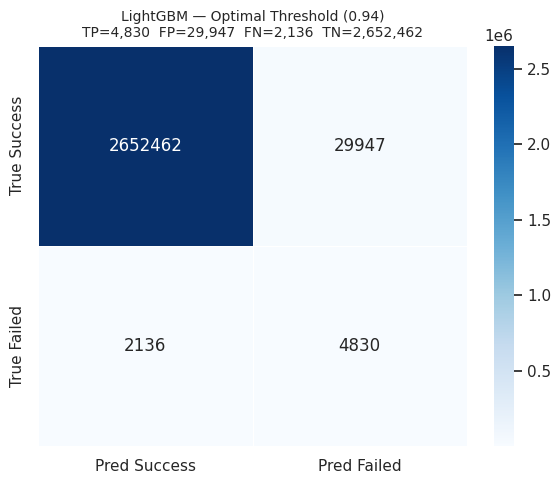

In [ ]:
# ── Final evaluation at optimal threshold ────────────────────────────────────
y_pred_optimal = (y_prob_best >= best_thresh).astype(int)

print(f"=== {best_name} at threshold = {best_thresh:.2f} ===\n")
print(classification_report(
    y_test, y_pred_optimal,
    target_names=['Success (0)', 'Failed (1)']
))

# ── Confusion matrix at optimal threshold ────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_optimal)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax,
            xticklabels=['Pred Success', 'Pred Failed'],
            yticklabels=['True Success', 'True Failed'])
tn, fp, fn, tp = cm.ravel()
ax.set_title(f"{best_name} — Optimal Threshold ({best_thresh:.2f})\n"
             f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}", fontsize=10)
plt.tight_layout()
plt.show()


---
### 11.9 — Cross-Validation Stability Check

A single train/test split can be lucky or unlucky. We run **5-fold stratified
cross-validation** on the best model to verify that performance is stable across
different data splits — not a one-time accident.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline       import Pipeline as ImbPipeline

# ── Build a reusable pipeline: SMOTE → scale → LightGBM ──────────────────────
# Using ImbPipeline so SMOTE only applies inside each training fold
cv_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(sampling_strategy=1/3, k_neighbors=5, random_state=42)),
    ('model',  LGBMClassifier(
        n_estimators     = 300,
        learning_rate    = 0.05,
        num_leaves       = 63,
        class_weight     = 'balanced',
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1,
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold cross-validation (this may take a few minutes) ...")
cv_results = cross_validate(
    cv_pipeline, X, y,
    cv      = cv,
    scoring = ['f1', 'roc_auc', 'average_precision'],
    n_jobs  = -1
)

print("\n=== 5-Fold Cross-Validation Results ===")
for metric_key, label in [('test_f1', 'F1'), ('test_roc_auc', 'AUC-ROC'), ('test_average_precision', 'PR-AUC')]:
    scores = cv_results[metric_key]
    print(f"  {label:<10}  mean={scores.mean():.4f}  std={scores.std():.4f}  "
          f"folds={np.round(scores, 4).tolist()}")


Running 5-fold cross-validation (this may take a few minutes) ...

=== 5-Fold Cross-Validation Results ===
  F1          mean=0.0627  std=0.0001  folds=[0.0627, 0.0626, 0.0627, 0.0627, 0.0628]
  AUC-ROC     mean=0.9885  std=0.0001  folds=[0.9883, 0.9883, 0.9885, 0.9886, 0.9886]
  PR-AUC      mean=0.5055  std=0.0043  folds=[0.5004, 0.5037, 0.5067, 0.5036, 0.5132]


---
### 11.10 — Save Best Model & Threshold

We save both the trained model and the optimal threshold together so the scheduler
can load them as a single unit. The scaler must also be saved — the scheduler will
receive raw feature values and must apply the same normalisation used during training.


In [ ]:
import joblib

# ── Save artefacts ────────────────────────────────────
joblib.dump(lgbm,         PATHS['failure_model'])
joblib.dump(scaler,       PATHS['failure_scaler'])
joblib.dump(best_thresh,  PATHS['failure_threshold'])

print("✅ Saved artefacts:")
print("   failure_predictor_lgbm.pkl       ← trained LightGBM model")
print("   failure_predictor_scaler.pkl     ← StandardScaler (fit on train set)")
print("   failure_predictor_threshold.pkl  ← optimal decision threshold")

# ── Scheduler inference example ────────────────────────
loaded_model   = joblib.load(PATHS['failure_model'])
loaded_scaler  = joblib.load(PATHS['failure_scaler'])
loaded_thresh  = joblib.load(PATHS['failure_threshold'])

example = pd.DataFrame([{
    'plan_cpu':          5.0,
    'plan_mem':         15.0,
    'dag_depth':         3,
    'is_root_task':      0,
    'max_seq_no':        2,    # already retried twice ─ suspicious
    'avg_inst_runtime': 120.0,
}])

example_scaled = loaded_scaler.transform(example)
fail_prob      = loaded_model.predict_proba(example_scaled)[0][1]
decision       = "REJECT / WARN" if fail_prob >= loaded_thresh else "ACCEPT"

print(f"\n🔮 Scheduler inference example:")
print(f"   Failure probability: {fail_prob:.4f}")
print(f"   Threshold:           {loaded_thresh:.2f}")
print(f"   Decision:            {decision}")

✅ Saved artefacts:
   failure_predictor_lgbm.pkl       ← trained LightGBM model
   failure_predictor_scaler.pkl     ← StandardScaler (fit on train set)
   failure_predictor_threshold.pkl  ← optimal decision threshold

🔮 Scheduler inference example:
   Failure probability: 0.0001
   Threshold:           0.94
   Decision:            ACCEPT


---
## 📈 Section 12 — Model 3: Resource Utilization Prediction (Time-Series Regression)

### Overview

A smart scheduler does not just react to current load — it **anticipates** future demand.
If we can predict that a machine's CPU will spike in 5 minutes, the scheduler can:
- **Pre-emptively migrate** jobs away before contention hits
- **Delay new placements** onto that machine
- **Trigger auto-scaling** before performance degrades

This is a **time-series forecasting** problem. Each machine produces a stream of
5-minute resource snapshots, and we want to predict the *next* snapshot from the recent history.

### Two Model Approaches

| Model | Approach | Best when |
|---|---|---|
| **XGBoost + Lag Features** | Manually unroll history into tabular lag columns, then apply a gradient-boosted regressor | Fast to train, easy to inspect, strong baseline |
| **LSTM** | Let the network learn temporal patterns from raw sequences automatically | Better on long-range dependencies, multivariate inputs |

### Data Flow

```
machine_state.csv
    │
    ├─ Per-machine time series: [t-5, t-4, t-3, t-2, t-1]  →  predict t
    │
    ├─ XGBoost path:  build lag columns  →  fit regressor  →  predict scalar
    │
    └─ LSTM path:     build 3D sequences  →  fit LSTM  →  predict scalar
```


In [ ]:
# Top of Section 12 ─ resume without re-running Sections 1-7
import os
import pandas as pd
if os.path.exists(PATHS['machine_state']):
    machine_state = pd.read_parquet(PATHS['machine_state'])
    print(f"✅ Loaded machine_state from Drive: {machine_state.shape}")
else:
    print("❌ machine_state.parquet not found ─ run Sections 1-7 first")

✅ Loaded machine_state from Drive: (589365, 6)


---
### 12.1 — Installs & Imports

In [ ]:
!pip install xgboost scikit-learn tensorflow --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib

from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost                import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
print(f"TensorFlow {tf.__version__}")
print("All imports OK")


TensorFlow 2.20.0
All imports OK


---
### 12.2 — Load & Inspect `machine_state.csv`

`machine_state.csv` was built in Section 7: each row is one machine x one 5-minute
bucket, with mean and max CPU/memory utilisation.

We need to verify:
- **Temporal continuity** — are there gaps in the time series per machine?
- **Value ranges** — should be normalised to [0, 100] per Alibaba schema
- **Invalid sentinels** — -1 and 101 must be treated as missing


In [ ]:
machine_state = pd.read_parquet(PATHS['machine_state'])

print(f"Shape:    {machine_state.shape}")
print(f"Columns:  {machine_state.columns.tolist()}")
print(f"Machines: {machine_state['machine_id'].nunique():,}")
print(f"Buckets:  {machine_state['time_bucket'].nunique():,}")
print(f"Time range: {machine_state['time_bucket'].min():.0f}s to {machine_state['time_bucket'].max():.0f}s")
print(f"  = {(machine_state['time_bucket'].max() - machine_state['time_bucket'].min()) / 3600:.1f} hours")
display(machine_state.head(8))

Shape:    (589365, 6)
Columns:  ['machine_id', 'time_bucket', 'avg_cpu', 'max_cpu', 'avg_mem', 'max_mem']
Machines: 294
Buckets:  2,242
Time range: 0s to 690900s
  = 191.9 hours


,machine_id,time_bucket,avg_cpu,max_cpu,avg_mem,max_mem
0,m_1932,386400.0,42.666667,44.0,92.000000,92.0
1,m_1932,386700.0,45.000000,46.0,92.500000,93.0
2,m_1932,387000.0,45.200000,47.0,93.000000,93.0
3,m_1932,387300.0,46.000000,46.0,93.000000,93.0
4,m_1932,387600.0,72.000000,75.0,96.666667,97.0
5,m_1932,387900.0,60.833333,71.0,96.166667,97.0
6,m_1932,388200.0,38.000000,41.0,83.000000,83.0
7,m_1932,388500.0,33.428571,37.0,83.142857,84.0


In [ ]:
# ── Clean invalid Alibaba sentinels (-1 and 101) ─────────────────────────────
INVALID   = [-1, 101, -1.0, 101.0]
util_cols = ['avg_cpu', 'max_cpu', 'avg_mem', 'max_mem']

for col in util_cols:
    n_bad = machine_state[col].isin(INVALID).sum()
    machine_state[col] = machine_state[col].replace(INVALID, np.nan)
    if n_bad > 0:
        print(f"  {col}: replaced {n_bad:,} invalid values with NaN")

# Forward-fill up to 2 consecutive missing buckets within each machine's series
# (short sensor dropouts), then drop remaining NaN rows
machine_state = (
    machine_state
    .sort_values(['machine_id', 'time_bucket'])
    .groupby('machine_id', group_keys=False)
    .apply(lambda g: g.ffill(limit=2))
    .dropna(subset=util_cols)
    .reset_index(drop=True)
)

print(f"\nClean dataset: {machine_state.shape}")
print(machine_state[util_cols].describe().round(2))



Clean dataset: (589365, 6)
         avg_cpu    max_cpu    avg_mem    max_mem
count  589365.00  589365.00  589365.00  589365.00
mean       36.59      40.68      87.56      88.31
std        16.13      17.75      15.55      15.69
min         0.00       0.00       1.00       1.00
25%        27.33      30.00      87.80      88.00
50%        36.80      41.00      91.00      92.00
75%        47.00      52.00      93.50      94.00
max        98.00      98.00      98.00      98.00


---
### 12.3 — Exploratory Analysis

Before building features we need to understand the time-series properties:

- **Autocorrelation** — how strongly does CPU at time *t* depend on *t-1*, *t-2*, etc.?
  High autocorrelation is what makes lag features powerful.
- **Periodicity** — do we see daily patterns across the 8-day trace?
- **Distribution shape** — uniform, bimodal, or skewed?


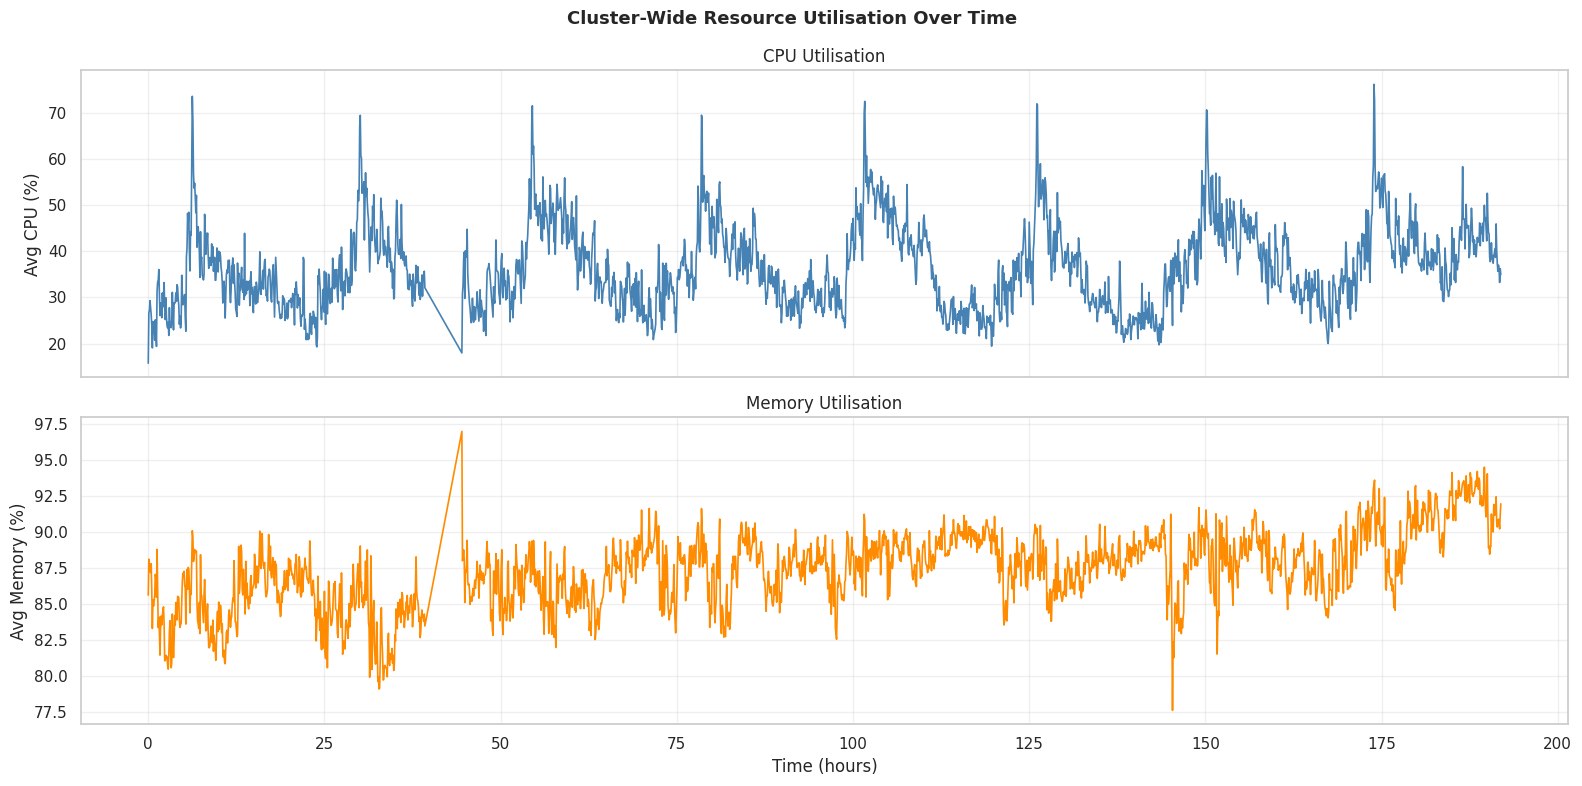

In [ ]:
# ── Cluster-wide CPU and Memory over time ────────────────────────────────────
cluster_ts = machine_state.groupby('time_bucket')[['avg_cpu', 'avg_mem']].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle("Cluster-Wide Resource Utilisation Over Time", fontsize=13, fontweight='bold')

axes[0].plot(cluster_ts['time_bucket'] / 3600, cluster_ts['avg_cpu'],
             color='steelblue', linewidth=1.2)
axes[0].set_ylabel("Avg CPU (%)")
axes[0].set_title("CPU Utilisation")
axes[0].grid(alpha=0.3)

axes[1].plot(cluster_ts['time_bucket'] / 3600, cluster_ts['avg_mem'],
             color='darkorange', linewidth=1.2)
axes[1].set_ylabel("Avg Memory (%)")
axes[1].set_xlabel("Time (hours)")
axes[1].set_title("Memory Utilisation")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


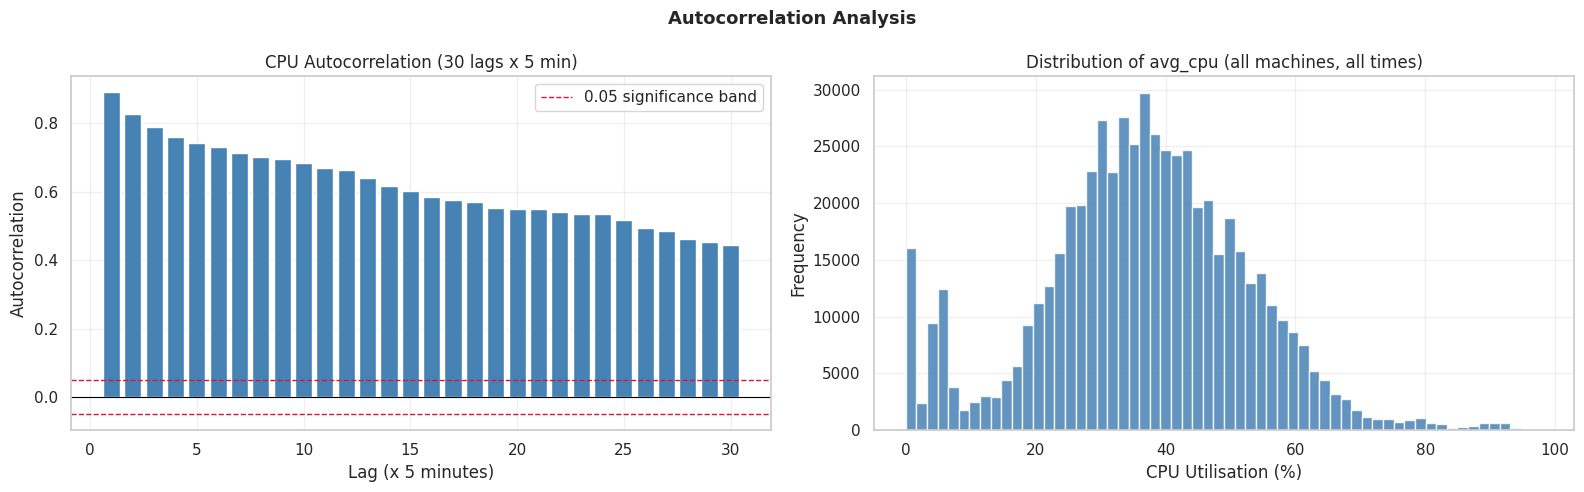

ACF at lag-1:  0.8904  <- strong = lag features will be useful
ACF at lag-5:  0.7429
ACF at lag-12: 0.6644  (lag-12 = 1 hour ago)


In [ ]:
# ── Autocorrelation of CPU (cluster average, 30 lags) ────────────────────────
cpu_series = cluster_ts['avg_cpu'].dropna()
lags       = range(1, 31)
acf_vals   = [cpu_series.autocorr(lag=l) for l in lags]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Autocorrelation Analysis", fontsize=13, fontweight='bold')

ax1.bar(lags, acf_vals, color='steelblue', edgecolor='white')
ax1.axhline(0,     color='black',   linewidth=0.8)
ax1.axhline(0.05,  color='crimson', linestyle='--', linewidth=1, label='0.05 significance band')
ax1.axhline(-0.05, color='crimson', linestyle='--', linewidth=1)
ax1.set_title("CPU Autocorrelation (30 lags x 5 min)")
ax1.set_xlabel("Lag (x 5 minutes)")
ax1.set_ylabel("Autocorrelation")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.hist(machine_state['avg_cpu'].dropna(), bins=60,
         color='steelblue', edgecolor='white', alpha=0.85)
ax2.set_title("Distribution of avg_cpu (all machines, all times)")
ax2.set_xlabel("CPU Utilisation (%)")
ax2.set_ylabel("Frequency")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ACF at lag-1:  {acf_vals[0]:.4f}  <- strong = lag features will be useful")
print(f"ACF at lag-5:  {acf_vals[4]:.4f}")
print(f"ACF at lag-12: {acf_vals[11]:.4f}  (lag-12 = 1 hour ago)")


---
### 12.4 — Sliding Window / Lag Feature Engineering

To predict CPU at time *t*, we give the model the values at *t-1, t-2, t-3, t-4, t-5*
as input features (the last 25 minutes of history).

Additional engineered features:
- **Rolling mean / std** over the lag window — captures trend and volatility
- **Delta features** — rate of change between consecutive buckets (is load rising or falling?)
- **Time-of-day** — normalised 0-1 encoding of the time within a 24-hour cycle

> **Critical rule:** Lag features must be built **per machine** — never across machine
> boundaries. Mixing readings from different machines would be a form of data leakage.


In [ ]:
LAGS       = 5
TARGET_COL = 'avg_cpu'
N_MACHINES = 50        # cap for Colab RAM — remove for full dataset

# Select the N machines with the most complete time series
top_machines = (
    machine_state['machine_id']
    .value_counts()
    .head(N_MACHINES)
    .index.tolist()
)
df_ts = machine_state[machine_state['machine_id'].isin(top_machines)].copy()
df_ts = df_ts.sort_values(['machine_id', 'time_bucket']).reset_index(drop=True)

print(f"Working with {df_ts['machine_id'].nunique()} machines, {len(df_ts):,} rows")

def build_lag_features(group, target, lags):
    g = group.copy()
    for lag in range(1, lags + 1):
        g[f'{target}_lag{lag}'] = g[target].shift(lag)
    g[f'{target}_roll_mean'] = g[target].shift(1).rolling(lags).mean()
    g[f'{target}_roll_std']  = g[target].shift(1).rolling(lags).std()
    g[f'{target}_delta1']    = g[target].diff(1)
    g[f'{target}_delta2']    = g[target].diff(2)
    g['time_of_day']         = (g['time_bucket'] % 86400) / 86400
    return g

df_feat = (
    df_ts
    .groupby('machine_id', group_keys=False)
    .apply(lambda g: build_lag_features(g, TARGET_COL, LAGS))
    .dropna()
    .reset_index(drop=True)
)

LAG_COLS = (
    [f'{TARGET_COL}_lag{i}' for i in range(1, LAGS + 1)]
    + [f'{TARGET_COL}_roll_mean', f'{TARGET_COL}_roll_std',
       f'{TARGET_COL}_delta1',    f'{TARGET_COL}_delta2',
       'time_of_day']
)

print(f"Feature matrix: {df_feat[LAG_COLS].shape}")
print("Features:", LAG_COLS)


Working with 50 machines, 103,891 rows
Feature matrix: (103641, 10)
Features: ['avg_cpu_lag1', 'avg_cpu_lag2', 'avg_cpu_lag3', 'avg_cpu_lag4', 'avg_cpu_lag5', 'avg_cpu_roll_mean', 'avg_cpu_roll_std', 'avg_cpu_delta1', 'avg_cpu_delta2', 'time_of_day']


---
### 12.5 — Temporal Train/Test Split

> **Never use random splits on time-series data.**

A random split lets the model train on *t=100* and test on *t=99*, meaning it sees
the future during training. In production this model would fail completely.

We use a **chronological 80/20 split**: the first 80% of time buckets for training,
the last 20% for testing — mirroring how the scheduler would actually be deployed.


In [ ]:
cutoff   = df_feat['time_bucket'].quantile(0.8)
train_df = df_feat[df_feat['time_bucket'] <= cutoff]
test_df  = df_feat[df_feat['time_bucket'] >  cutoff]

X_train  = train_df[LAG_COLS].values
y_train  = train_df[TARGET_COL].values
X_test   = test_df[LAG_COLS].values
y_test   = test_df[TARGET_COL].values

print(f"Train: {len(X_train):,} samples  |  buckets up to {cutoff:.0f}s")
print(f"Test:  {len(X_test):,}  samples  |  buckets after {cutoff:.0f}s")
print(f"\nTarget stats:")
print(f"  Train mean={y_train.mean():.2f}%  std={y_train.std():.2f}%")
print(f"  Test  mean={y_test.mean():.2f}%  std={y_test.std():.2f}%")

# Scale (fit on train only)
scaler_ts  = StandardScaler()
X_train_sc = scaler_ts.fit_transform(X_train)
X_test_sc  = scaler_ts.transform(X_test)


Train: 82,944 samples  |  buckets up to 562500s
Test:  20,697  samples  |  buckets after 562500s

Target stats:
  Train mean=36.74%  std=14.83%
  Test  mean=38.26%  std=15.23%


---
### 12.6 — Model A: XGBoost with Lag Features

XGBoost treats lag columns as ordinary tabular features — it has no built-in
concept of time. The temporal structure is entirely encoded in how we arranged
the columns. This makes it the **fast, interpretable baseline**.


In [ ]:
print("Training XGBoost ...")
t0  = time.time()

xgb = XGBRegressor(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
)
xgb.fit(X_train_sc, y_train,
        eval_set=[(X_test_sc, y_test)], verbose=False)
xgb_time = time.time() - t0

y_pred_xgb = xgb.predict(X_test_sc)
mae_xgb    = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb   = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb     = r2_score(y_test, y_pred_xgb)

print(f"Done in {xgb_time:.1f}s")
print(f"  MAE:  {mae_xgb:.4f} %CPU")
print(f"  RMSE: {rmse_xgb:.4f} %CPU")
print(f"  R2:   {r2_xgb:.4f}")


Training XGBoost ...
Done in 8.5s
  MAE:  0.3656 %CPU
  RMSE: 1.0541 %CPU
  R2:   0.9952


---
### 12.7 — Model B: LSTM

An **LSTM (Long Short-Term Memory)** network processes time steps in order and
maintains a hidden state that can capture patterns the lag columns alone cannot
represent — particularly sudden trend reversals and multi-step dependencies.

**Input shape:** `(samples, time_steps, features)` — here `(N, 5, 1)`.

**Architecture:**
```
Input  (5 time steps x 1 feature)
   LSTM(64)     <- learns temporal patterns, returns sequences
   Dropout(0.2) <- prevents overfitting on repeated machine patterns
   LSTM(32)     <- refines representation
   Dropout(0.2)
   Dense(16, relu)
   Dense(1)     <- predicted next CPU %
```

We use **Huber loss** instead of MSE: it behaves like MSE for small errors
(smooth gradient) but like MAE for large errors (resistant to load spikes).


In [ ]:
# ── Reshape: (samples, LAGS, 1) — oldest lag first ───────────────────────────
lag_only_cols   = [f'{TARGET_COL}_lag{i}' for i in range(LAGS, 0, -1)]

X_train_seq     = train_df[lag_only_cols].values.reshape(-1, LAGS, 1)
X_test_seq      = test_df[lag_only_cols].values.reshape(-1, LAGS, 1)

# Fit a dedicated scaler on the flat lag values then reshape back
scaler_lstm     = StandardScaler()
X_tr_flat_sc    = scaler_lstm.fit_transform(X_train_seq.reshape(-1, LAGS))
X_te_flat_sc    = scaler_lstm.transform(X_test_seq.reshape(-1, LAGS))
X_train_sc_lstm = X_tr_flat_sc.reshape(-1, LAGS, 1)
X_test_sc_lstm  = X_te_flat_sc.reshape(-1, LAGS, 1)

# Scale target separately for stable LSTM training
y_scaler      = StandardScaler()
y_train_sc    = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc     = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print(f"LSTM input  shape: {X_train_sc_lstm.shape}")
print(f"LSTM target shape: {y_train_sc.shape}")


LSTM input  shape: (82944, 5, 1)
LSTM target shape: (82944,)


In [ ]:
tf.random.set_seed(42)

lstm_model = Sequential([
    Input(shape=(LAGS, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='resource_lstm')

lstm_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'huber',
    metrics   = ['mae']
)

lstm_model.summary()


Model: "resource_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=0),
]

print("Training LSTM ...")
t0 = time.time()

history = lstm_model.fit(
    X_train_sc_lstm, y_train_sc,
    validation_data = (X_test_sc_lstm, y_test_sc),
    epochs          = 100,
    batch_size      = 512,
    callbacks       = callbacks,
    verbose         = 0,
)

lstm_time = time.time() - t0
print(f"Done in {lstm_time:.1f}s  |  stopped at epoch {len(history.history['loss'])}")

# Predict and inverse-transform back to % CPU
y_pred_lstm_sc = lstm_model.predict(X_test_sc_lstm, verbose=0).ravel()
y_pred_lstm    = y_scaler.inverse_transform(y_pred_lstm_sc.reshape(-1, 1)).ravel()

mae_lstm  = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm   = r2_score(y_test, y_pred_lstm)

print(f"  MAE:  {mae_lstm:.4f} %CPU")
print(f"  RMSE: {rmse_lstm:.4f} %CPU")
print(f"  R2:   {r2_lstm:.4f}")


Training LSTM ...
Done in 94.5s  |  stopped at epoch 14
  MAE:  4.8814 %CPU
  RMSE: 6.6655 %CPU
  R2:   0.8086


---
### 12.8 — Comparison & Visualisation

Four diagnostic plots:
1. **Metric bar chart** — MAE, RMSE, R² side by side
2. **LSTM training curves** — loss and MAE per epoch
3. **Predicted vs Actual over time** — one representative machine
4. **Residual distributions** — are errors centred on zero?


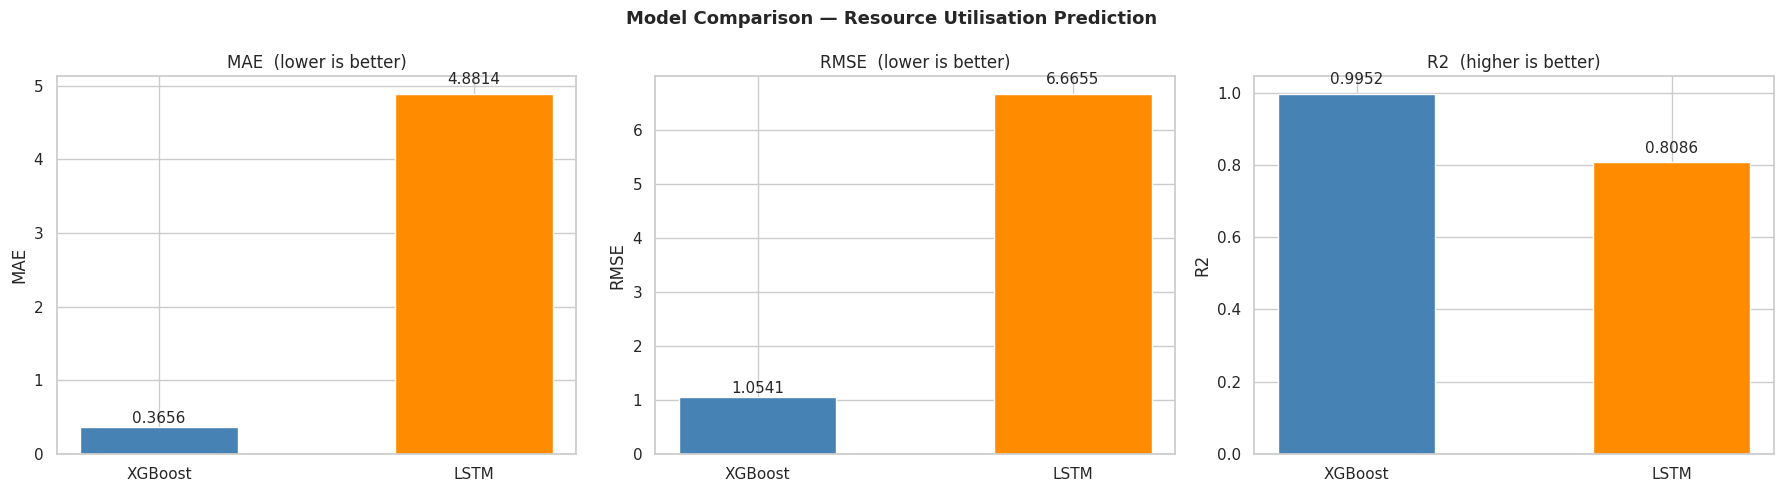

Model             MAE       RMSE       R2   Train(s)
──────────────────────────────────────────────
XGBoost        0.3656     1.0541   0.9952        8.5
LSTM           4.8814     6.6655   0.8086       94.5


In [ ]:
# ── Plot 1: Metric comparison ─────────────────────────────────────────────────
results_ts = {
    'XGBoost': {'MAE': mae_xgb,  'RMSE': rmse_xgb,  'R2': r2_xgb,  'Train (s)': xgb_time},
    'LSTM':    {'MAE': mae_lstm, 'RMSE': rmse_lstm, 'R2': r2_lstm, 'Train (s)': lstm_time},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison — Resource Utilisation Prediction", fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals   = [results_ts[n][metric] for n in results_ts]
    colors = ['steelblue', 'darkorange']
    bars   = ax.bar(list(results_ts.keys()), vals, color=colors, edgecolor='white', width=0.5)
    lower  = metric != 'R2'
    ax.set_title(f"{metric}  ({'lower' if lower else 'higher'} is better)")
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print(f"{'Model':<10} {'MAE':>10} {'RMSE':>10} {'R2':>8} {'Train(s)':>10}")
print("─" * 46)
for n, r in results_ts.items():
    print(f"{n:<10} {r['MAE']:>10.4f} {r['RMSE']:>10.4f} {r['R2']:>8.4f} {r['Train (s)']:>10.1f}")


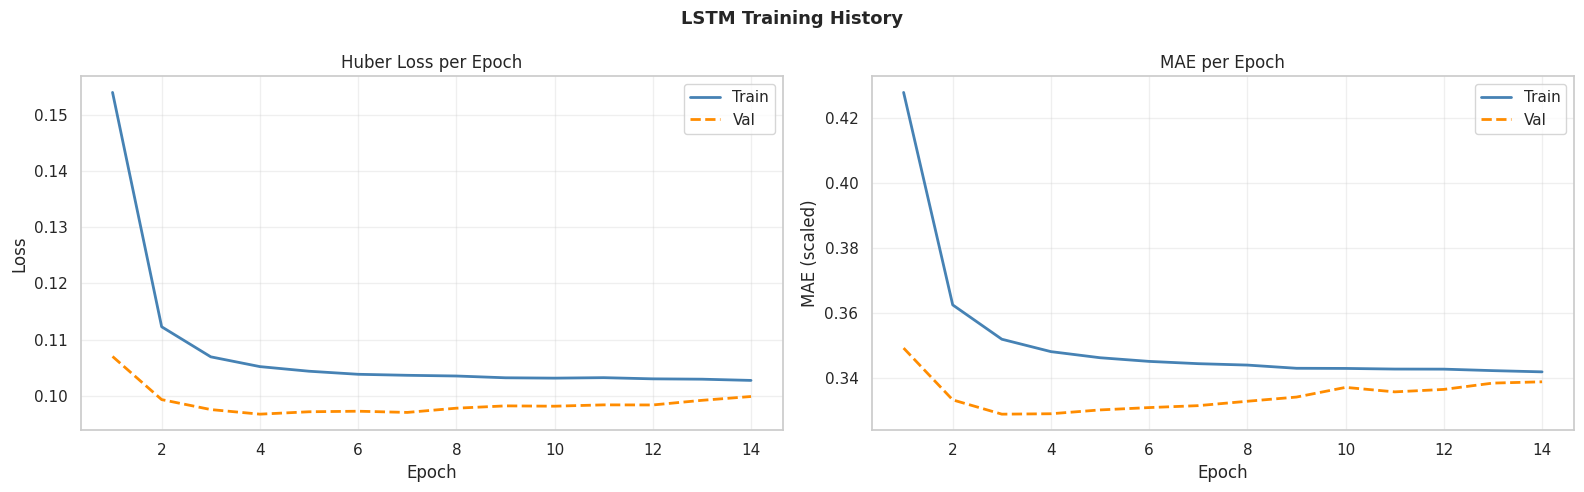

In [ ]:
# ── Plot 2: LSTM training curves ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("LSTM Training History", fontsize=13, fontweight='bold')

epochs = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs, history.history['loss'],     color='steelblue',  lw=2, label='Train')
ax1.plot(epochs, history.history['val_loss'], color='darkorange', lw=2, ls='--', label='Val')
ax1.set_title("Huber Loss per Epoch")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history.history['mae'],     color='steelblue',  lw=2, label='Train')
ax2.plot(epochs, history.history['val_mae'], color='darkorange', lw=2, ls='--', label='Val')
ax2.set_title("MAE per Epoch")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MAE (scaled)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


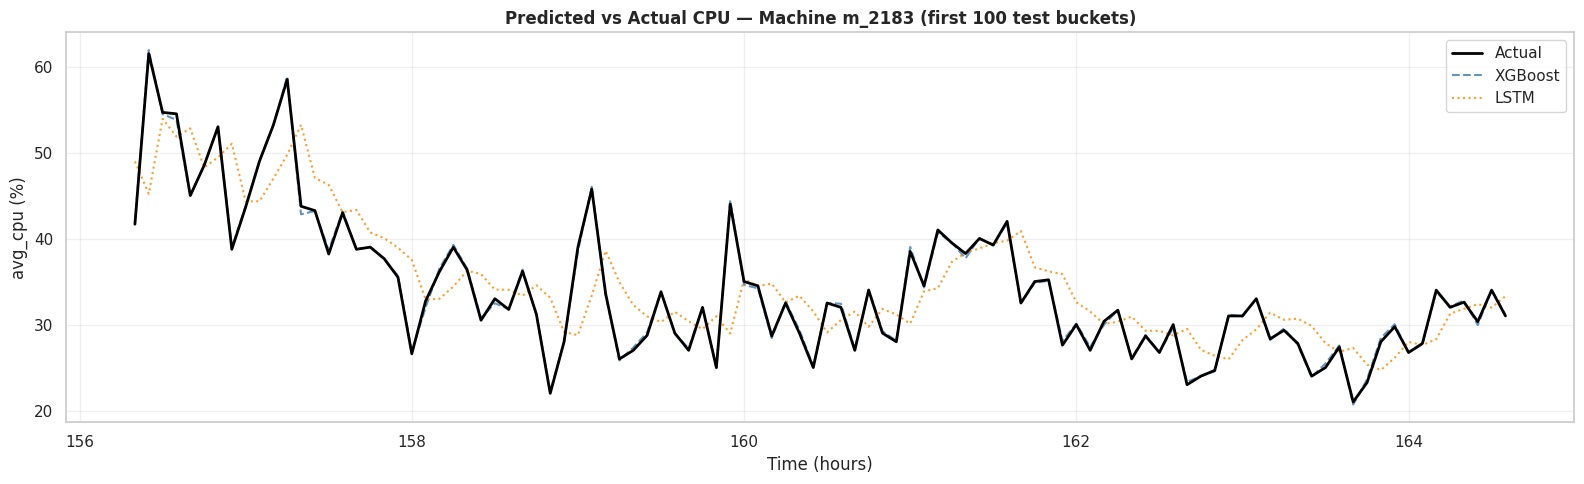

In [ ]:
# ── Plot 3: Predicted vs Actual over time (one machine) ──────────────────────
test_df_plot             = test_df.copy()
test_df_plot['xgb_pred']  = y_pred_xgb
test_df_plot['lstm_pred'] = y_pred_lstm

# Pick the machine with the most test rows
sample_machine = test_df_plot['machine_id'].value_counts().index[0]
trace = test_df_plot[test_df_plot['machine_id'] == sample_machine].head(100)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(trace['time_bucket'] / 3600, trace[TARGET_COL],
        color='black',      lw=2,   label='Actual',   zorder=3)
ax.plot(trace['time_bucket'] / 3600, trace['xgb_pred'],
        color='steelblue',  lw=1.5, ls='--', label='XGBoost', alpha=0.85)
ax.plot(trace['time_bucket'] / 3600, trace['lstm_pred'],
        color='darkorange', lw=1.5, ls=':',  label='LSTM',    alpha=0.85)

ax.set_title(f"Predicted vs Actual CPU — Machine {sample_machine} (first 100 test buckets)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Time (hours)"); ax.set_ylabel("avg_cpu (%)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


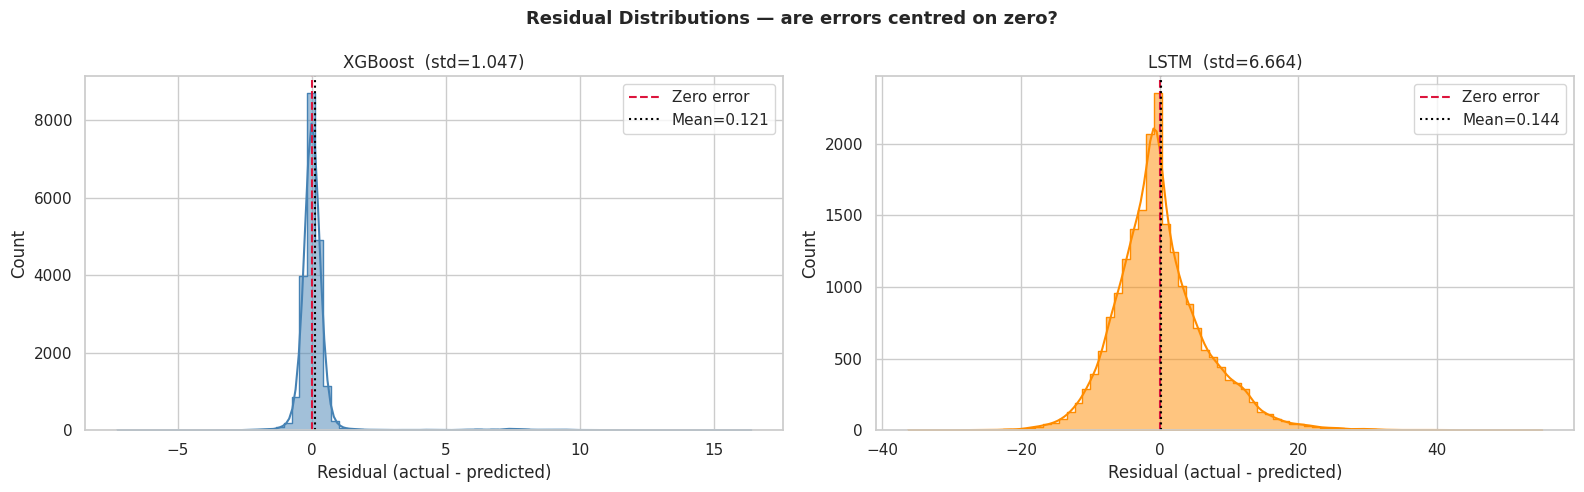

In [ ]:
# ── Plot 4: Residual distributions ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Residual Distributions — are errors centred on zero?", fontsize=13, fontweight='bold')

for ax, (name, y_pred), color in zip(
    [ax1, ax2],
    [('XGBoost', y_pred_xgb), ('LSTM', y_pred_lstm)],
    ['steelblue', 'darkorange']
):
    res = y_test - y_pred
    sns.histplot(res, bins=80, kde=True, ax=ax, color=color, element='step')
    ax.axvline(0,        color='crimson', ls='--', lw=1.5, label='Zero error')
    ax.axvline(res.mean(),color='black',  ls=':',  lw=1.5, label=f'Mean={res.mean():.3f}')
    ax.set_title(f"{name}  (std={res.std():.3f})")
    ax.set_xlabel("Residual (actual - predicted)")
    ax.legend()

plt.tight_layout()
plt.show()


---
### 12.9 — XGBoost Feature Importance

Feature importance reveals **how far back the model looks**:
- Dominant **lag-1** means the series is mostly Markovian — the most recent reading is the best predictor
- Significant **lag-4 / lag-5** means longer history adds value — this is exactly where LSTM has an advantage
- High **roll_mean** importance means trend direction matters more than any single exact value
- High **delta1** importance means the *rate of change* is predictive — load spikes are detected early


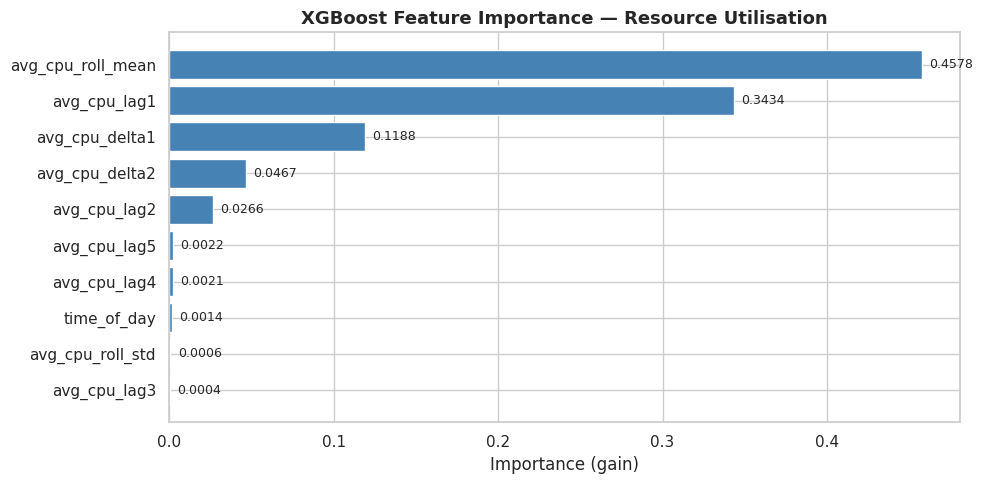

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

importances = xgb.feature_importances_
order       = np.argsort(importances)
feat_sorted = [LAG_COLS[i] for i in order]
imp_sorted  = importances[order]

bars = ax.barh(feat_sorted, imp_sorted, color='steelblue', edgecolor='white')
ax.set_title("XGBoost Feature Importance — Resource Utilisation", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (gain)")

for bar, val in zip(bars, imp_sorted):
    ax.text(val + imp_sorted.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


---
### 12.10 — Save Models

Both models are saved. The scheduler can use either:
- **XGBoost** for sub-millisecond inference in the hot path (real-time placement decisions)
- **LSTM** for batch pre-computation of load forecasts (run every 5 minutes, cache results)


In [ ]:
joblib.dump(xgb,       PATHS['resource_xgb'])
joblib.dump(scaler_ts, PATHS['resource_scaler'])
print("Saved: resource_xgb.pkl")
print("Saved: resource_scaler.pkl")

lstm_model.save(PATHS['resource_lstm'])
joblib.dump(scaler_lstm, PATHS['resource_lstm_scaler'])
joblib.dump(y_scaler,    PATHS['resource_lstm_yscaler'])
print("Saved: resource_lstm.keras")
print("Saved: resource_lstm_scaler.pkl")
print("Saved: resource_lstm_yscaler.pkl")

# ── Scheduler inference example (XGBoost) ──────────────────
loaded_xgb    = joblib.load(PATHS['resource_xgb'])
loaded_scaler = joblib.load(PATHS['resource_scaler'])

# Last 5 CPU readings + derived features for one machine
recent_cpu   = [42.1, 43.5, 41.8, 44.2, 45.0]   # t-5 to t-1
roll_mean    = np.mean(recent_cpu)
roll_std     = np.std(recent_cpu)
delta1       = recent_cpu[-1] - recent_cpu[-2]
delta2       = recent_cpu[-1] - recent_cpu[-3]
time_of_day  = 0.42   # ~10am

features        = np.array([[*recent_cpu, roll_mean, roll_std, delta1, delta2, time_of_day]])
features_scaled = loaded_scaler.transform(features)
predicted_cpu   = loaded_xgb.predict(features_scaled)[0]

print(f"\nScheduler inference example:")
print(f"  Last 5 CPU readings: {recent_cpu}")
print(f"  Predicted next CPU:  {predicted_cpu:.2f}%")
if predicted_cpu > 80:
    print("  WARNING: High load forecast ─ delay new placements on this machine")
else:
    print("  OK: Load within normal range ─ machine available for new jobs")

Saved: resource_xgb.pkl
Saved: resource_scaler.pkl
Saved: resource_lstm.keras
Saved: resource_lstm_scaler.pkl
Saved: resource_lstm_yscaler.pkl

Scheduler inference example:
  Last 5 CPU readings: [42.1, 43.5, 41.8, 44.2, 45.0]
  Predicted next CPU:  43.31%
  OK: Load within normal range ─ machine available for new jobs


---
## 🔍 Section 13 — Model 4: Machine Anomaly Detection (Unsupervised)

### Overview

Resource utilisation prediction tells us *what load is expected*. Anomaly detection
tells us *when a machine is behaving abnormally* — even when no historical pattern
predicts it.

Anomalous machines are dangerous for a scheduler:
- **Silent CPU thrashing** — a machine reports normal CPU but makes no progress
- **Memory leaks** — gradual drift upward until OOM kills healthy co-located jobs
- **Network saturation** — bursts that don't show in 5-minute averages
- **Hardware degradation** — subtle performance regressions before outright failure

Because anomalies are **unlabelled** (we don't have a ground-truth "this machine was broken"
column), this is an **unsupervised** problem. We use two complementary approaches:

| Approach | How it works | Best for |
|---|---|---|
| **Statistical (3σ rule)** | Flag any reading where `max_cpu > mean + 3σ` per machine | Instantaneous point spikes, simple and fast |
| **Isolation Forest** | Randomly partitions feature space; anomalies are isolated in fewer splits | Multi-feature anomalies invisible to single metrics |
| **Autoencoder** | Learns to compress + reconstruct normal behaviour; anomalies have high reconstruction error | Temporal drift and complex multi-dimensional patterns |

### Pipeline

```
machine_state.csv
    │
    ├─ Per-machine z-score normalisation
    │
    ├─ Statistical flags:   max_cpu > mean + 3σ
    │
    ├─ Isolation Forest:    fit on z-score features → anomaly score
    │
    └─ Autoencoder:         fit on normal windows → reconstruction error
                            flag machines where error > threshold
```


In [ ]:
# Top of Section 13 ─ resume without re-running Sections 1-7, 12
import os
import pandas as pd
if os.path.exists(PATHS['machine_state']):
    machine_state = pd.read_parquet(PATHS['machine_state'])
    print(f"✅ Loaded machine_state for Section 13 from Drive: {machine_state.shape}")
else:
    print("❌ machine_state.parquet not found ─ run Sections 1-7 or 12 first")

✅ Loaded machine_state for Section 13 from Drive: (589365, 6)


---
### 13.1 — Installs & Imports

In [ ]:
!pip install scikit-learn tensorflow --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import time

from sklearn.ensemble        import IsolationForest
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import classification_report
from scipy                   import stats

import tensorflow as tf
from tensorflow.keras.models    import Model
from tensorflow.keras.layers    import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
print(f"TensorFlow {tf.__version__}")
print("All imports OK")


TensorFlow 2.20.0
All imports OK


---
### 13.2 — Load & Clean `machine_state.csv`

Same cleaning as Section 12 — replace Alibaba sentinels (-1, 101) and forward-fill
short gaps, but here we keep **all machines** rather than capping at 50.


In [ ]:
machine_state = pd.read_parquet(PATHS['machine_state'])

INVALID   = [-1, 101, -1.0, 101.0]
util_cols = ['avg_cpu', 'max_cpu', 'avg_mem', 'max_mem']

for col in util_cols:
    n_bad = machine_state[col].isin(INVALID).sum()
    machine_state[col] = machine_state[col].replace(INVALID, np.nan)
    if n_bad > 0:
        print(f"  {col}: replaced {n_bad:,} invalid values")

machine_state = (
    machine_state
    .sort_values(['machine_id', 'time_bucket'])
    .groupby('machine_id', group_keys=False)
    .apply(lambda g: g.ffill(limit=2))
    .dropna(subset=util_cols)
    .reset_index(drop=True)
)

print(f"\nClean dataset: {machine_state.shape}")
print(f"Machines:      {machine_state['machine_id'].nunique():,}")
display(machine_state.head())


Clean dataset: (589365, 6)
Machines:      294


,machine_id,time_bucket,avg_cpu,max_cpu,avg_mem,max_mem
0,m_1932,386400.0,42.666667,44.0,92.000000,92.0
1,m_1932,386700.0,45.000000,46.0,92.500000,93.0
2,m_1932,387000.0,45.200000,47.0,93.000000,93.0
3,m_1932,387300.0,46.000000,46.0,93.000000,93.0
4,m_1932,387600.0,72.000000,75.0,96.666667,97.0


---
### 13.3 — Per-Machine Aggregate Features & Z-Score Normalisation

For Isolation Forest and the Autoencoder we first collapse each machine's time series
into a **fixed-length feature vector** describing its behaviour over the full trace:

| Feature | What it captures |
|---|---|
| `cpu_mean` | Typical load level |
| `cpu_std` | How much load fluctuates |
| `cpu_max` | Peak load reached |
| `cpu_p95` | 95th-percentile load (robust spike measure) |
| `mem_mean` / `mem_std` / `mem_max` / `mem_p95` | Same for memory |
| `cpu_spike_rate` | Fraction of buckets where cpu > mean + 2σ |
| `mem_spike_rate` | Fraction of buckets where mem > mean + 2σ |
| `cpu_trend` | Linear trend slope over time (positive = steadily increasing load) |

We then **z-score normalise** each feature across all machines so that Isolation Forest
distances are not dominated by high-variance columns.


In [ ]:
def machine_features(group):
    cpu = group['avg_cpu']
    mem = group['avg_mem']
    mc  = group['max_cpu']

    # Global machine stats
    cpu_mean = cpu.mean()
    cpu_std  = cpu.std()
    mem_mean = mem.mean()
    mem_std  = mem.std()

    # Spike rates: fraction of time spent above mean + 2σ
    cpu_spike_rate = (cpu > cpu_mean + 2 * cpu_std).mean()
    mem_spike_rate = (mem > mem_mean + 2 * mem_std).mean()

    # Linear trend slope (positive = load creeping up over time)
    if len(group) > 1:
        cpu_trend = np.polyfit(np.arange(len(group)), cpu.values, 1)[0]
        mem_trend = np.polyfit(np.arange(len(group)), mem.values, 1)[0]
    else:
        cpu_trend = mem_trend = 0.0

    return pd.Series({
        'cpu_mean':       cpu_mean,
        'cpu_std':        cpu_std,
        'cpu_max':        mc.max(),
        'cpu_p95':        cpu.quantile(0.95),
        'mem_mean':       mem_mean,
        'mem_std':        mem_std,
        'mem_max':        group['max_mem'].max(),
        'mem_p95':        mem.quantile(0.95),
        'cpu_spike_rate': cpu_spike_rate,
        'mem_spike_rate': mem_spike_rate,
        'cpu_trend':      cpu_trend,
        'mem_trend':      mem_trend,
        'n_buckets':      len(group),
    })

print("Computing per-machine features ...")
machine_profiles = (
    machine_state
    .groupby('machine_id')
    .apply(machine_features)
    .reset_index()
)

FEAT_COLS = ['cpu_mean', 'cpu_std', 'cpu_max', 'cpu_p95',
             'mem_mean', 'mem_std', 'mem_max', 'mem_p95',
             'cpu_spike_rate', 'mem_spike_rate', 'cpu_trend', 'mem_trend']

print(f"Machine profiles: {machine_profiles.shape}")
display(machine_profiles[['machine_id'] + FEAT_COLS].head())


Computing per-machine features ...
Machine profiles: (294, 14)


,machine_id,cpu_mean,cpu_std,cpu_max,cpu_p95,mem_mean,mem_std,mem_max,mem_p95,cpu_spike_rate,mem_spike_rate,cpu_trend,mem_trend
0,m_1932,40.829632,14.653891,93.0,63.666667,90.929571,4.366485,98.0,96.00,0.044489,0.000000,0.015190,-0.002256
1,m_1933,5.696620,0.957780,12.0,7.166667,92.493404,0.616105,94.0,93.00,0.022381,0.018095,0.000439,0.000062
2,m_1934,42.554200,11.963305,92.0,63.400000,89.909122,6.484697,98.0,96.00,0.030617,0.000000,0.000774,-0.001644
3,m_1935,38.716716,11.786126,91.0,59.500000,91.115948,3.895833,98.0,96.00,0.034483,0.000000,0.001770,0.001281
4,m_1936,39.947594,12.173703,93.0,60.608333,90.833717,4.306043,98.0,95.75,0.030378,0.000000,0.000996,-0.000680


In [ ]:
# ── Z-score normalisation ─────────────────────────────────────────────────────
anomaly_scaler = StandardScaler()
X      = anomaly_scaler.fit_transform(machine_profiles[FEAT_COLS])

# Store as a clean DataFrame for inspection
X_df = pd.DataFrame(X, columns=FEAT_COLS, index=machine_profiles['machine_id'])

print("Z-score feature matrix shape:", X_df.shape)
print("\nAll columns should now have mean≈0 and std≈1:")
print(X_df.describe().round(3).loc[['mean', 'std']])

Z-score feature matrix shape: (294, 12)

All columns should now have mean≈0 and std≈1:
      cpu_mean  cpu_std  cpu_max  cpu_p95  mem_mean  mem_std  mem_max  \
mean     0.000    0.000   -0.000   -0.000    -0.000    0.000   -0.000   
std      1.002    1.002    1.002    1.002     1.002    1.002    1.002   

      mem_p95  cpu_spike_rate  mem_spike_rate  cpu_trend  mem_trend  
mean   -0.000           0.000           0.000     -0.000      0.000  
std     1.002           1.002           1.002      1.002      1.002  


---
### 13.4 — Method 1: Statistical Flagging (3σ Rule)

The simplest anomaly criterion: a machine is flagged if any single time-bucket
reading exceeds **mean + 3 standard deviations** of that machine's own CPU distribution.

```
flag_t = 1   if  max_cpu_t  >  mean(max_cpu_m) + 3 × std(max_cpu_m)
         0   otherwise
```

This is a **per-machine** threshold — machine A's threshold is computed from machine A's
own history, not from the cluster average. This prevents a machine that simply runs hotter
than average from being incorrectly flagged as anomalous.

The 3σ threshold means that for a perfectly normal distribution only 0.3% of readings
would be flagged by chance — keeping the false-positive rate very low.


In [ ]:
# ── Compute per-machine 3σ thresholds ────────────────────────────────────────
machine_thresholds = (
    machine_state
    .groupby('machine_id')['max_cpu']
    .agg(
        cpu_global_mean = 'mean',
        cpu_global_std  = 'std',
    )
    .assign(threshold_3sigma = lambda d: d['cpu_global_mean'] + 3 * d['cpu_global_std'])
    .reset_index()
)

# ── Join thresholds back and flag individual buckets ─────────────────────────
flagged_df = machine_state.merge(machine_thresholds, on='machine_id')
flagged_df['stat_spike'] = (flagged_df['max_cpu'] > flagged_df['threshold_3sigma']).astype(int)

# ── Summarise: how many machines have at least one flagged bucket? ────────────
flagged_machines = (
    flagged_df
    .groupby('machine_id')
    .agg(
        spike_count   = ('stat_spike', 'sum'),
        spike_rate    = ('stat_spike', 'mean'),
        max_cpu_seen  = ('max_cpu',    'max'),
        threshold     = ('threshold_3sigma', 'first'),
    )
    .reset_index()
    .assign(stat_anomaly = lambda d: (d['spike_count'] > 0).astype(int))
)

n_flagged = flagged_machines['stat_anomaly'].sum()
n_total   = len(flagged_machines)

print(f"Machines flagged by 3sigma rule: {n_flagged:,} / {n_total:,}  ({n_flagged/n_total*100:.1f}%)")
print(f"\nTop 10 most anomalous machines:")
display(
    flagged_machines
    .sort_values('spike_count', ascending=False)
    .head(10)[['machine_id', 'max_cpu_seen', 'threshold', 'spike_count', 'spike_rate']]
    .round(2)
)


Machines flagged by 3sigma rule: 240 / 294  (81.6%)

Top 10 most anomalous machines:


,machine_id,max_cpu_seen,threshold,spike_count,spike_rate
43,m_1975,1.0,0.85,144,0.07
33,m_1965,92.0,78.51,75,0.04
245,m_2177,94.0,91.50,70,0.03
220,m_2152,95.0,90.35,69,0.03
47,m_1979,94.0,89.79,69,0.03
131,m_2063,97.0,95.24,67,0.03
270,m_2202,93.0,90.79,66,0.03
99,m_2031,95.0,90.71,66,0.03
58,m_1990,98.0,90.86,64,0.03
263,m_2195,94.0,91.88,62,0.03


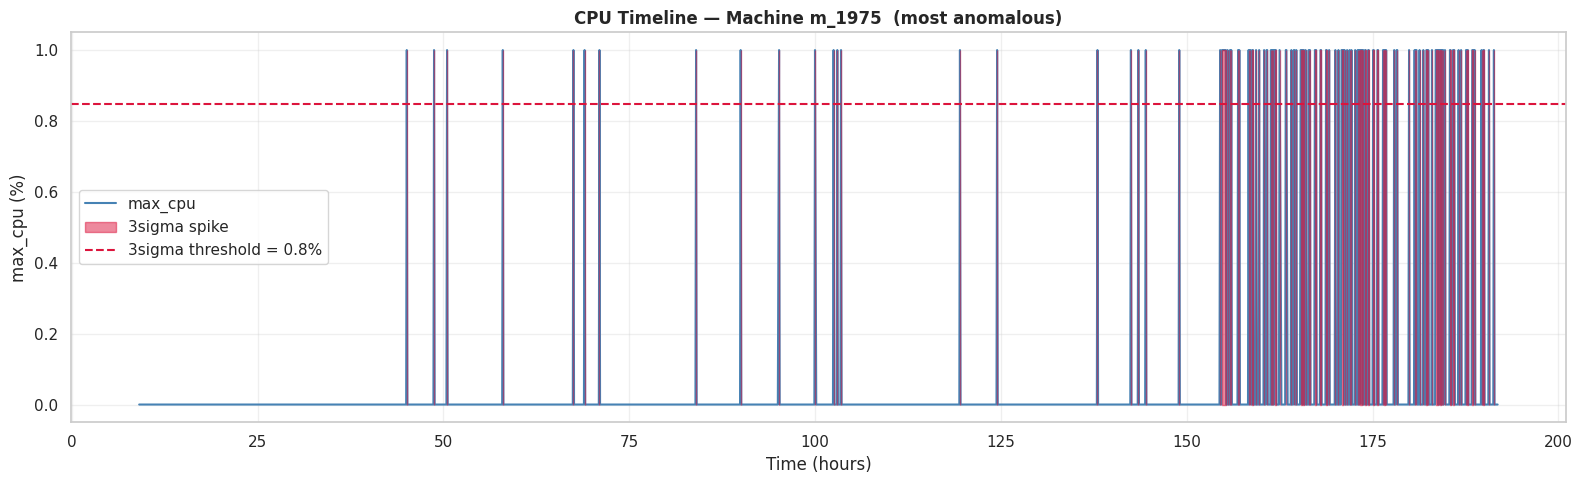

In [ ]:
# ── Visualise: spike timeline for the most anomalous machine ─────────────────
worst_machine = flagged_machines.sort_values('spike_count', ascending=False).iloc[0]['machine_id']
machine_trace = flagged_df[flagged_df['machine_id'] == worst_machine].sort_values('time_bucket')
threshold_val = machine_trace['threshold_3sigma'].iloc[0]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(machine_trace['time_bucket'] / 3600, machine_trace['max_cpu'],
        color='steelblue', lw=1.5, label='max_cpu', zorder=2)
ax.fill_between(machine_trace['time_bucket'] / 3600, machine_trace['max_cpu'],
                where=machine_trace['stat_spike'] == 1,
                color='crimson', alpha=0.5, label='3sigma spike', zorder=3)
ax.axhline(threshold_val, color='crimson', ls='--', lw=1.5,
           label=f'3sigma threshold = {threshold_val:.1f}%')

ax.set_title(f"CPU Timeline — Machine {worst_machine}  (most anomalous)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Time (hours)")
ax.set_ylabel("max_cpu (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
### 13.5 — Method 2: Isolation Forest

**Isolation Forest** detects anomalies by randomly partitioning the feature space
with axis-aligned cuts. The key insight:

> Anomalies are **easy to isolate** — they sit in sparse regions and require fewer
> random cuts to separate from the rest of the data.

An anomaly score is computed for each machine. Scores near **-1** are the most
anomalous; scores near **+1** are the most normal. The `contamination` parameter
tells the model what fraction of the dataset to treat as anomalies — we set it
to a conservative 5%.

Unlike the 3σ rule, Isolation Forest operates on **all 12 features simultaneously**,
catching machines that are abnormal in a combination of dimensions (e.g. normal CPU
but anomalously high memory trend + spike rate) even when no single metric crosses a threshold.


In [ ]:
print("Training Isolation Forest ...")
t0 = time.time()

iso_forest = IsolationForest(
    n_estimators  = 200,
    max_samples   = 'auto',
    contamination = 0.05,    # assume 5% of machines are anomalous
    random_state  = 42,
    n_jobs        = -1,
)
iso_forest.fit(X)

iso_scores = iso_forest.decision_function(X)   # higher = more normal
iso_labels = iso_forest.predict(X)             # -1 = anomaly, +1 = normal

elapsed = time.time() - t0
print(f"Done in {elapsed:.2f}s")
print(f"\nAnomaly labels: +1 = normal, -1 = anomaly")
print(f"  Normal:   {(iso_labels ==  1).sum():,}")
print(f"  Anomaly:  {(iso_labels == -1).sum():,}  ({(iso_labels == -1).mean()*100:.1f}%)")

# Add to machine profiles
machine_profiles['iso_score'] = iso_scores
machine_profiles['iso_label'] = iso_labels
machine_profiles['iso_anomaly'] = (iso_labels == -1).astype(int)


Training Isolation Forest ...
Done in 0.94s

Anomaly labels: +1 = normal, -1 = anomaly
  Normal:   279
  Anomaly:  15  (5.1%)


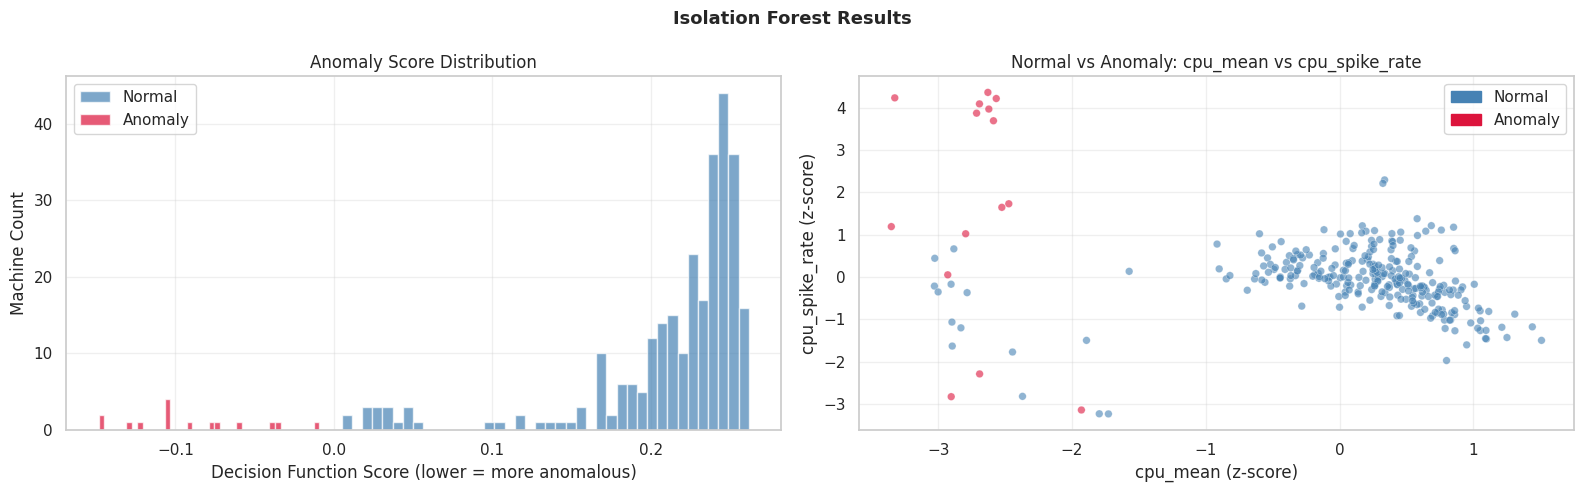

In [ ]:
# ── Plot: anomaly score distribution ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Isolation Forest Results", fontsize=13, fontweight='bold')

# Score distribution
ax1.hist(iso_scores[iso_labels == 1],  bins=40, color='steelblue',
         alpha=0.7, label='Normal', edgecolor='white')
ax1.hist(iso_scores[iso_labels == -1], bins=40, color='crimson',
         alpha=0.7, label='Anomaly', edgecolor='white')
ax1.set_title("Anomaly Score Distribution")
ax1.set_xlabel("Decision Function Score (lower = more anomalous)")
ax1.set_ylabel("Machine Count")
ax1.legend()
ax1.grid(alpha=0.3)

# Top-2 features coloured by label — cpu_mean vs cpu_spike_rate
colors_map = {1: 'steelblue', -1: 'crimson'}
colors_arr = [colors_map[l] for l in iso_labels]
ax2.scatter(X_df['cpu_mean'], X_df['cpu_spike_rate'],
            c=colors_arr, alpha=0.6, s=30, edgecolors='white', linewidths=0.3)
ax2.set_title("Normal vs Anomaly: cpu_mean vs cpu_spike_rate")
ax2.set_xlabel("cpu_mean (z-score)")
ax2.set_ylabel("cpu_spike_rate (z-score)")
# Manual legend
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color='steelblue', label='Normal'),
    Patch(color='crimson',   label='Anomaly')
])
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
### 13.6 — Method 3: Autoencoder

An **Autoencoder** is a neural network trained to compress its input to a low-dimensional
**bottleneck** and then reconstruct it back to the original shape. It is trained
**only on normal machines**, so it learns to reconstruct normal behaviour well.

When an anomalous machine is passed through, the network has never seen that pattern —
it fails to reconstruct it accurately. The **reconstruction error** (MSE between input
and output) becomes the anomaly score.

```
Input (12 features)
    → Encoder: 12 → 8 → 4   (bottleneck)
    → Decoder: 4  → 8 → 12
    → Reconstruction error = MSE(input, output)

Normal machine:    low error  → network reconstructs it well
Anomalous machine: high error → network has never seen this pattern
```

**Training strategy:** we train only on the machines flagged as normal by Isolation
Forest, then score all machines including the suspected anomalies.


In [ ]:
# ── Use ISO normal machines as training set for Autoencoder ─────────────────
X_normal = X[machine_profiles['iso_anomaly'] == 0]
print(f"Training Autoencoder on {len(X_normal)} normal machines ...")

# ── Build Autoencoder architecture ───────────────────────────────────────────
tf.random.set_seed(42)
n_features = X.shape[1]

inputs  = Input(shape=(n_features,), name='input')
# Encoder
enc = Dense(8, activation='relu',    name='enc_8')(inputs)
enc = Dense(4, activation='relu',    name='bottleneck')(enc)
# Decoder
dec = Dense(8, activation='relu',    name='dec_8')(enc)
dec = Dense(n_features, activation='linear', name='output')(dec)

autoencoder = Model(inputs, dec, name='anomaly_autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Training Autoencoder on 279 normal machines ...


Model: "anomaly_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_8 (Dense)                   │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_8 (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │           108 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288 (1.12 KB)

 Trainable params: 288 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
t0 = time.time()

ae_history = autoencoder.fit(
    X_normal, X_normal,          # input = target (reconstruction task)
    epochs          = 100,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = [EarlyStopping(monitor='val_loss', patience=10,
                                     restore_best_weights=True, verbose=0)],
    verbose         = 0,
)

ae_time = time.time() - t0
print(f"Done in {ae_time:.1f}s  |  stopped at epoch {len(ae_history.history['loss'])}")

# ── Reconstruction error for ALL machines ────────────────────────────────────
X_reconstructed  = autoencoder.predict(X, verbose=0)
recon_errors     = np.mean((X - X_reconstructed) ** 2, axis=1)

machine_profiles['recon_error'] = recon_errors

print(f"\nReconstruction error stats:")
print(f"  Normal machines:   mean={recon_errors[machine_profiles['iso_anomaly']==0].mean():.4f}")
print(f"  Anomalous machines: mean={recon_errors[machine_profiles['iso_anomaly']==1].mean():.4f}")


Done in 17.4s  |  stopped at epoch 100

Reconstruction error stats:
  Normal machines:   mean=0.0456
  Anomalous machines: mean=9.9392


Autoencoder threshold: 0.2580
Machines flagged:      21 / 294  (7.1%)


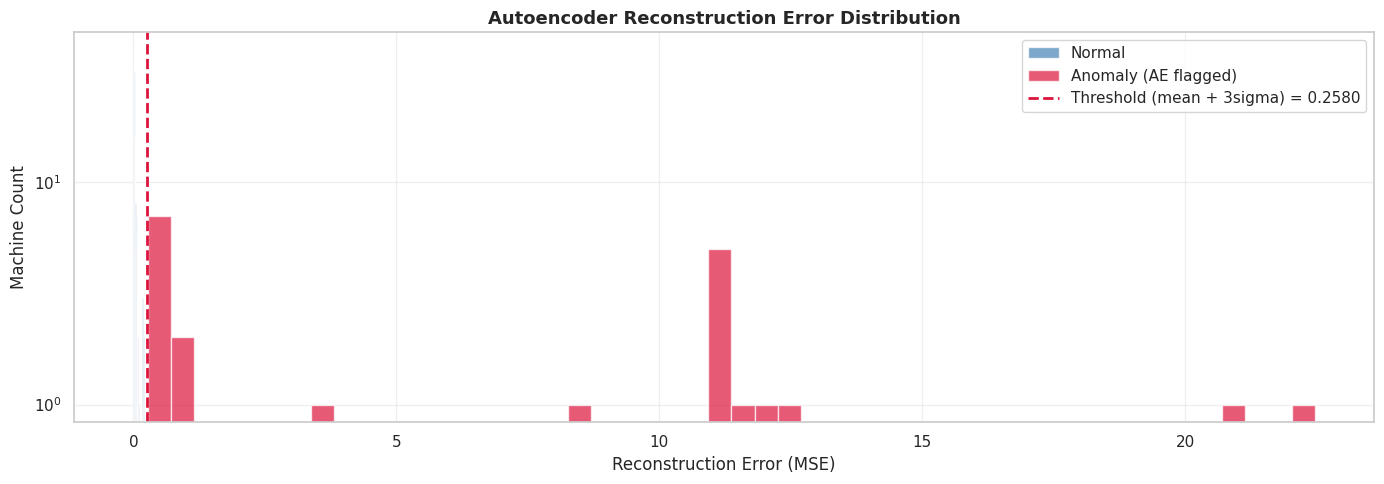

In [ ]:
# ── Set anomaly threshold at mean + 3σ of reconstruction error on normals ─────
normal_errors = recon_errors[machine_profiles['iso_anomaly'] == 0]
ae_threshold  = normal_errors.mean() + 3 * normal_errors.std()

machine_profiles['ae_anomaly'] = (recon_errors > ae_threshold).astype(int)

n_ae = machine_profiles['ae_anomaly'].sum()
print(f"Autoencoder threshold: {ae_threshold:.4f}")
print(f"Machines flagged:      {n_ae:,} / {len(machine_profiles):,}  ({n_ae/len(machine_profiles)*100:.1f}%)")

# ── Plot: reconstruction error distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

normal_mask = machine_profiles['ae_anomaly'] == 0
ax.hist(recon_errors[normal_mask],  bins=50, color='steelblue',
        alpha=0.7, label='Normal', edgecolor='white')
ax.hist(recon_errors[~normal_mask], bins=50, color='crimson',
        alpha=0.7, label='Anomaly (AE flagged)', edgecolor='white')
ax.axvline(ae_threshold, color='crimson', ls='--', lw=2,
           label=f'Threshold (mean + 3sigma) = {ae_threshold:.4f}')

ax.set_title("Autoencoder Reconstruction Error Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Machine Count")
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
### 13.7 — Autoencoder Training Curves

Monitoring train vs validation loss confirms the network is learning genuine structure,
not memorising the normal machines. A large gap between train and val loss would
indicate overfitting on the small normal training set.


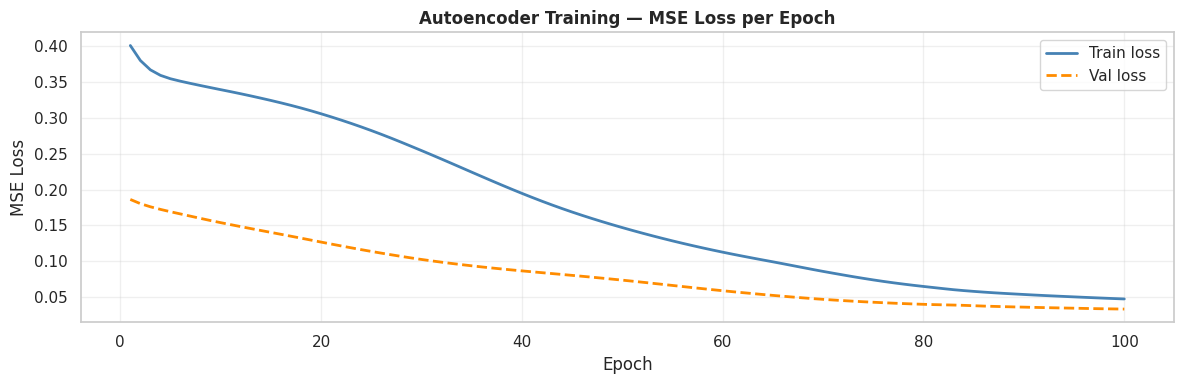

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

epochs = range(1, len(ae_history.history['loss']) + 1)
ax.plot(epochs, ae_history.history['loss'],     color='steelblue',  lw=2, label='Train loss')
ax.plot(epochs, ae_history.history['val_loss'], color='darkorange', lw=2, ls='--', label='Val loss')
ax.set_title("Autoencoder Training — MSE Loss per Epoch", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
### 13.8 — Ensemble: Combining All Three Methods

Each method catches different kinds of anomalies:
- **3σ rule** catches instantaneous point spikes in a single metric
- **Isolation Forest** catches machines that are outliers across multiple features simultaneously
- **Autoencoder** catches machines whose overall behavioural pattern is unlike any normal machine

We create a **consensus score** (0–3) counting how many methods flag each machine.
Machines flagged by all three are the highest-priority anomalies.

```
consensus = stat_anomaly + iso_anomaly + ae_anomaly

Score 0: Completely normal  — no action
Score 1: Mild concern       — monitor
Score 2: Likely anomalous   — investigate
Score 3: Confirmed anomaly  — escalate to scheduler / maintenance
```


In [ ]:
# ── Join 3sigma flags into machine_profiles ──────────────────────────────────
machine_profiles = machine_profiles.merge(
    flagged_machines[['machine_id', 'stat_anomaly', 'spike_count', 'spike_rate']],
    on='machine_id', how='left'
).fillna({'stat_anomaly': 0, 'spike_count': 0, 'spike_rate': 0})

machine_profiles['stat_anomaly'] = machine_profiles['stat_anomaly'].astype(int)

# ── Consensus score ───────────────────────────────────────────────────────────
machine_profiles['consensus'] = (
    machine_profiles['stat_anomaly']
    + machine_profiles['iso_anomaly']
    + machine_profiles['ae_anomaly']
)

# ── Summary table ─────────────────────────────────────────────────────────────
consensus_counts = machine_profiles['consensus'].value_counts().sort_index()
labels_map = {0: 'Normal (0)', 1: 'Mild (1)', 2: 'Likely (2)', 3: 'Confirmed (3)'}

print("=== Ensemble Consensus Summary ===")
for score, count in consensus_counts.items():
    pct = count / len(machine_profiles) * 100
    print(f"  Score {score} {labels_map.get(score, ''):<20} {count:>5,} machines  ({pct:.1f}%)")

print(f"\nHigh-priority anomalies (score >= 2): "
      f"{(machine_profiles['consensus'] >= 2).sum():,} machines")


=== Ensemble Consensus Summary ===
  Score 0 Normal (0)              51 machines  (17.3%)
  Score 1 Mild (1)               223 machines  (75.9%)
  Score 2 Likely (2)               7 machines  (2.4%)
  Score 3 Confirmed (3)           13 machines  (4.4%)

High-priority anomalies (score >= 2): 20 machines


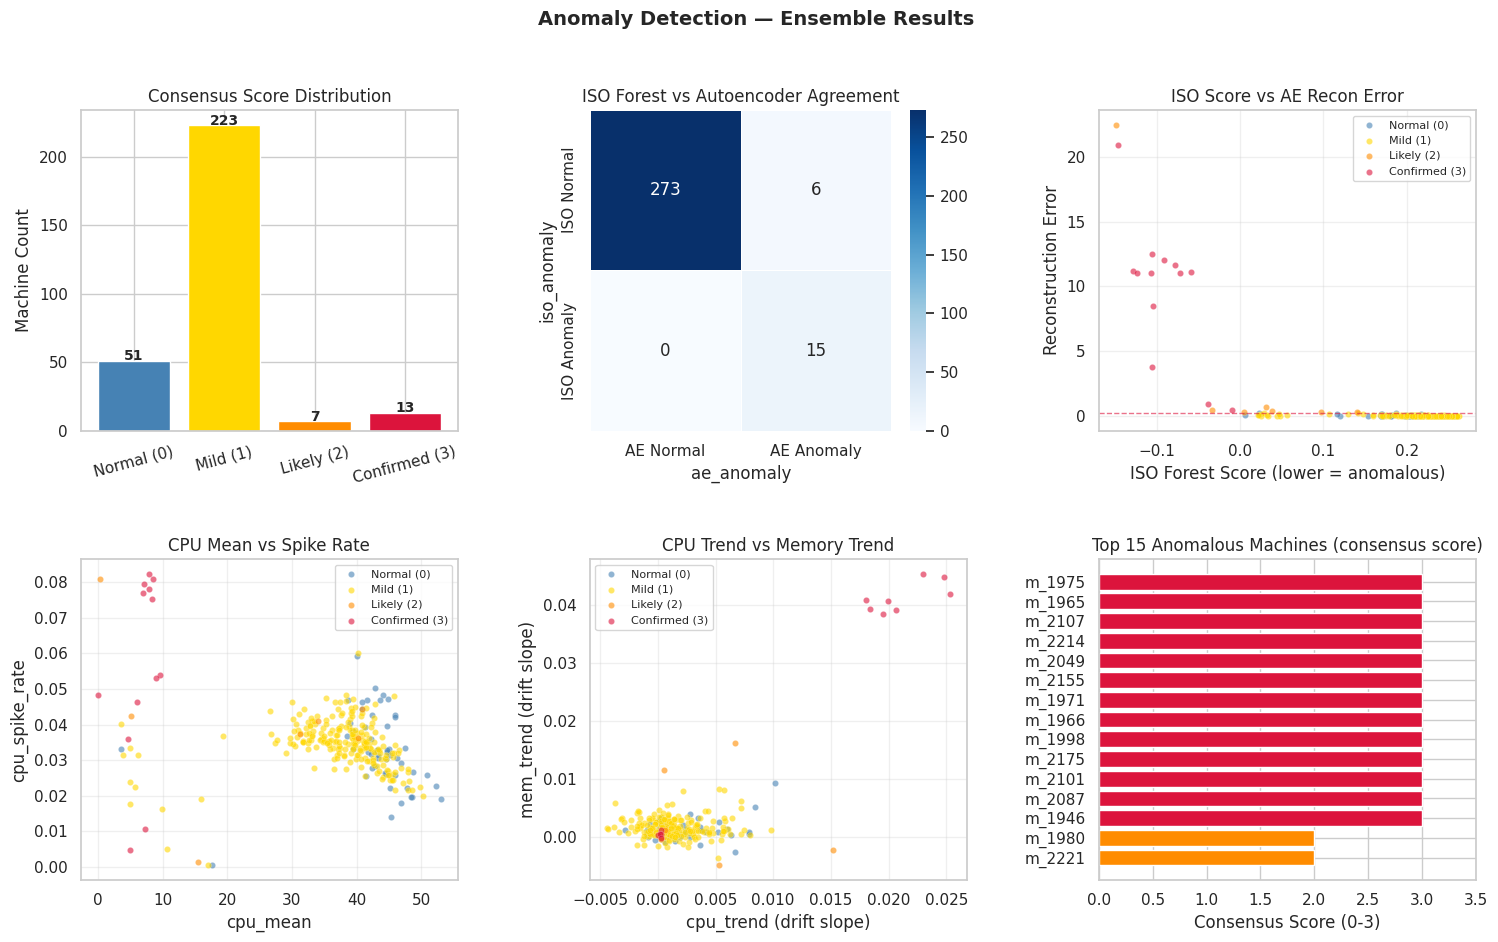

In [ ]:
# ── Visualise: consensus scores ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("Anomaly Detection — Ensemble Results", fontsize=14, fontweight='bold')

# 1. Consensus score bar chart
ax1 = fig.add_subplot(gs[0, 0])
palette = ['steelblue', 'gold', 'darkorange', 'crimson']
counts  = [consensus_counts.get(i, 0) for i in range(4)]
bars    = ax1.bar([labels_map[i] for i in range(4)], counts,
                  color=palette, edgecolor='white')
ax1.set_title("Consensus Score Distribution")
ax1.set_ylabel("Machine Count")
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontsize=10, fontweight='bold')

# 2. Venn-like overlap: method agreement heatmap
ax2 = fig.add_subplot(gs[0, 1])
overlap = pd.crosstab(machine_profiles['iso_anomaly'],
                      machine_profiles['ae_anomaly'],
                      margins=False)
sns.heatmap(overlap, annot=True, fmt='d', cmap='Blues', ax=ax2, linewidths=0.5,
            xticklabels=['AE Normal', 'AE Anomaly'],
            yticklabels=['ISO Normal', 'ISO Anomaly'])
ax2.set_title("ISO Forest vs Autoencoder Agreement")

# 3. Scatter: iso_score vs recon_error, coloured by consensus
ax3 = fig.add_subplot(gs[0, 2])
scatter_colors = ['steelblue', 'gold', 'darkorange', 'crimson']
for score in range(4):
    mask = machine_profiles['consensus'] == score
    ax3.scatter(
        machine_profiles.loc[mask, 'iso_score'],
        machine_profiles.loc[mask, 'recon_error'],
        c=scatter_colors[score], alpha=0.6, s=20,
        label=labels_map[score], edgecolors='white', linewidths=0.2
    )
ax3.axhline(ae_threshold, color='crimson', ls='--', lw=1, alpha=0.6)
ax3.set_title("ISO Score vs AE Recon Error")
ax3.set_xlabel("ISO Forest Score (lower = anomalous)")
ax3.set_ylabel("Reconstruction Error")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# 4. cpu_mean vs cpu_spike_rate, coloured by consensus
ax4 = fig.add_subplot(gs[1, 0])
for score in range(4):
    mask = machine_profiles['consensus'] == score
    ax4.scatter(
        machine_profiles.loc[mask, 'cpu_mean'],
        machine_profiles.loc[mask, 'cpu_spike_rate'],
        c=scatter_colors[score], alpha=0.6, s=20,
        label=labels_map[score], edgecolors='white', linewidths=0.2
    )
ax4.set_title("CPU Mean vs Spike Rate")
ax4.set_xlabel("cpu_mean"); ax4.set_ylabel("cpu_spike_rate")
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# 5. cpu_trend vs mem_trend
ax5 = fig.add_subplot(gs[1, 1])
for score in range(4):
    mask = machine_profiles['consensus'] == score
    ax5.scatter(
        machine_profiles.loc[mask, 'cpu_trend'],
        machine_profiles.loc[mask, 'mem_trend'],
        c=scatter_colors[score], alpha=0.6, s=20,
        label=labels_map[score], edgecolors='white', linewidths=0.2
    )
ax5.set_title("CPU Trend vs Memory Trend")
ax5.set_xlabel("cpu_trend (drift slope)")
ax5.set_ylabel("mem_trend (drift slope)")
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

# 6. Top anomalous machines by consensus + iso_score
ax6 = fig.add_subplot(gs[1, 2])
top_anomalies = (
    machine_profiles[machine_profiles['consensus'] >= 1]
    .sort_values(['consensus', 'iso_score'], ascending=[False, True])
    .head(15)
)
colors_bar = [scatter_colors[int(s)] for s in top_anomalies['consensus']]
ax6.barh(top_anomalies['machine_id'].astype(str), top_anomalies['consensus'],
         color=colors_bar, edgecolor='white')
ax6.set_title("Top 15 Anomalous Machines (consensus score)")
ax6.set_xlabel("Consensus Score (0-3)")
ax6.set_xlim(0, 3.5)
ax6.invert_yaxis()

plt.tight_layout()
plt.show()


---
### 13.9 — Deep-Dive: Confirmed Anomalous Machines

For machines flagged by all three methods (consensus = 3), we plot the full
resource utilisation timeline alongside the 3σ thresholds and spike events.
This is the diagnostic view that a site-reliability engineer — or an automated
scheduler — would use to decide whether to drain and quarantine a machine.


Confirmed anomalies (score=3): 13 machines


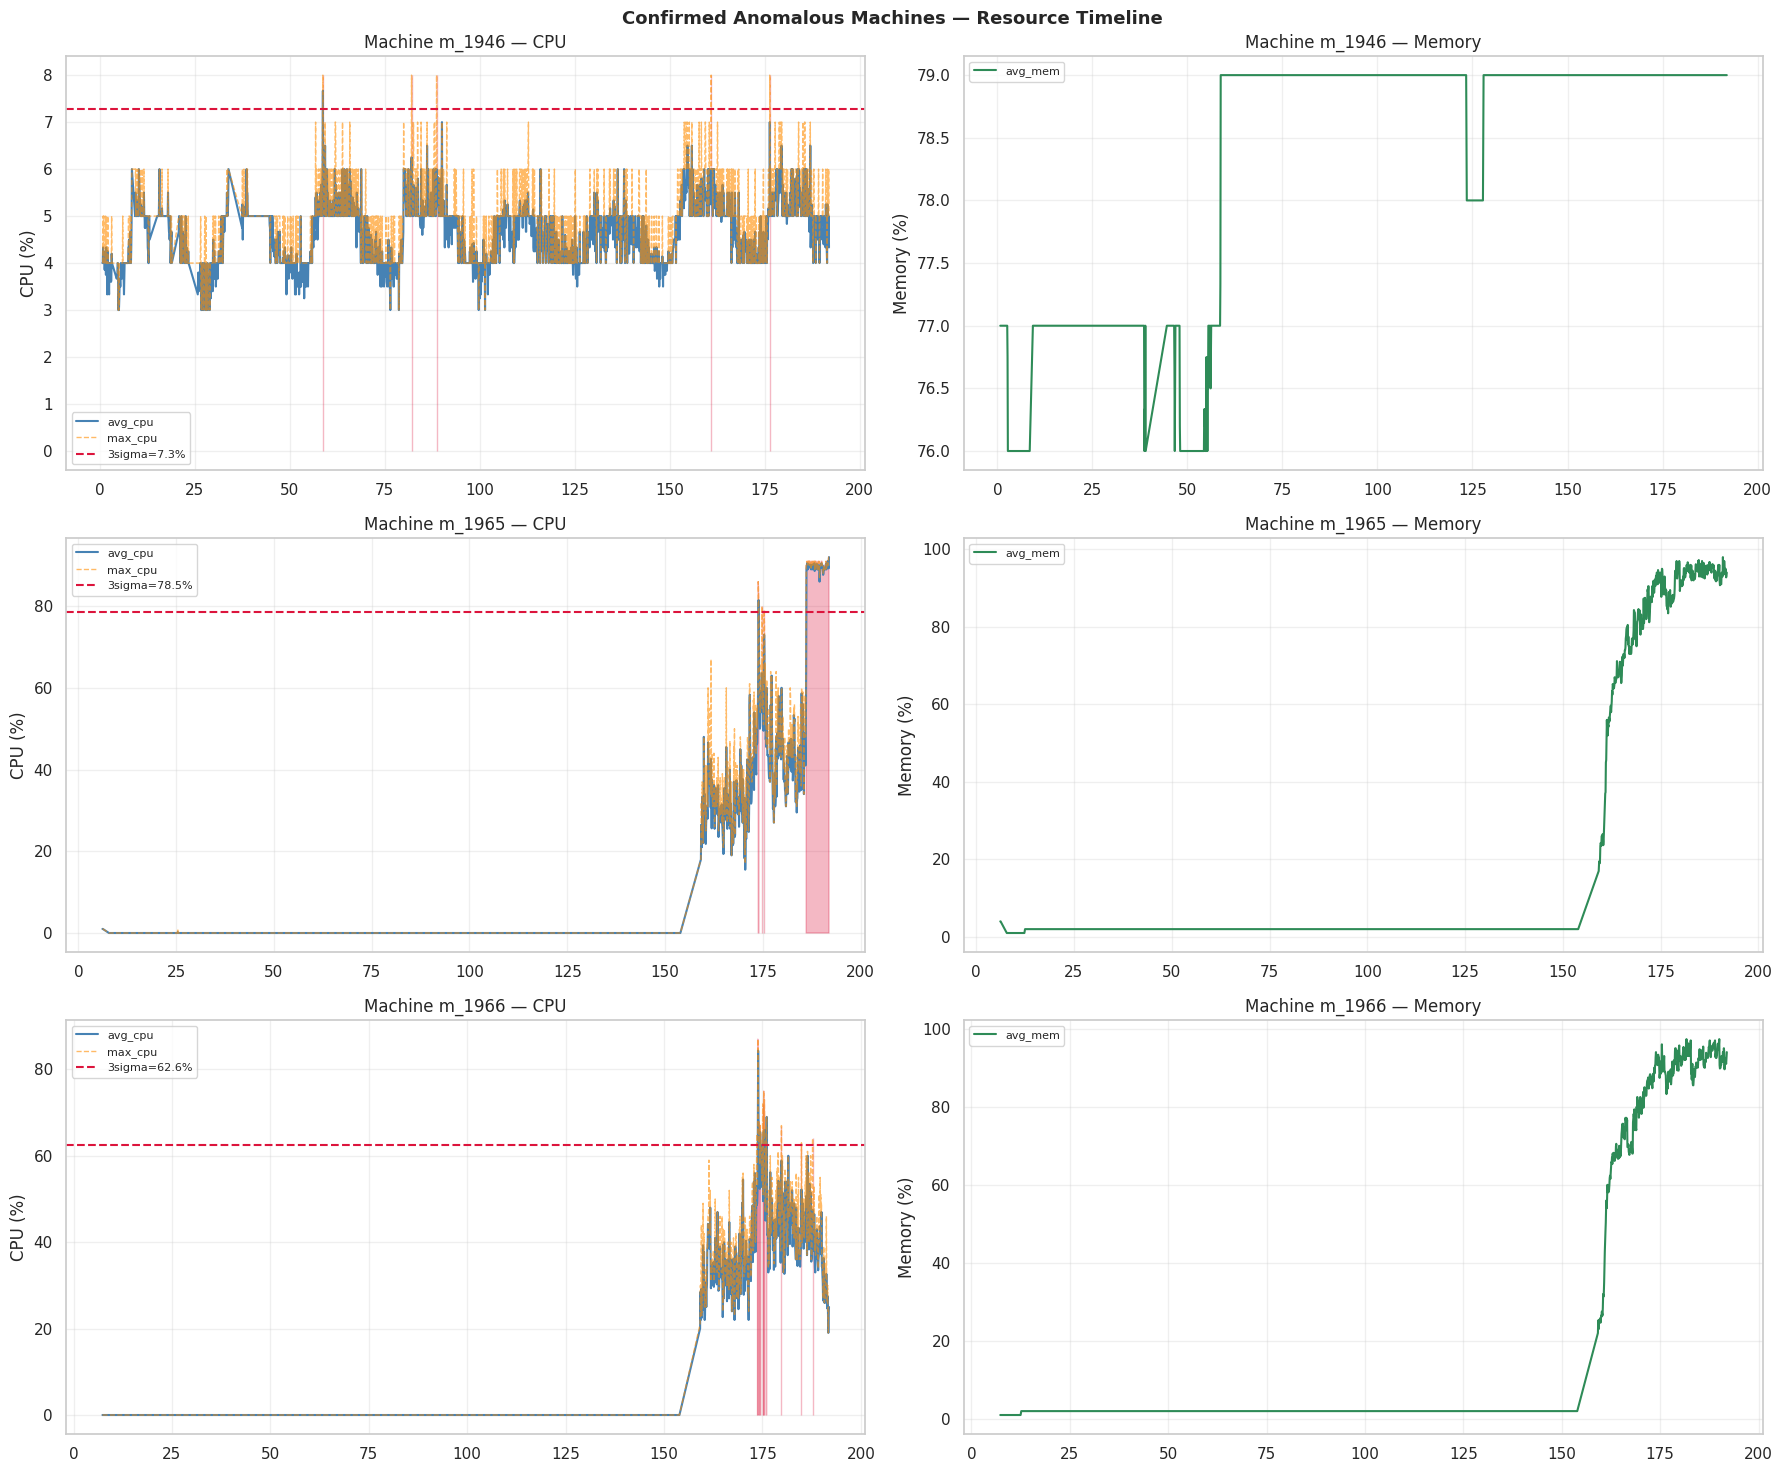

In [ ]:
confirmed = machine_profiles[machine_profiles['consensus'] == 3]['machine_id'].tolist()

if not confirmed:
    # Fall back to score >= 2 if no machine hits all three
    confirmed = machine_profiles[machine_profiles['consensus'] >= 2]['machine_id'].tolist()
    print(f"No score-3 machines found; showing score>=2 machines ({len(confirmed)} total)")
else:
    print(f"Confirmed anomalies (score=3): {len(confirmed)} machines")

# Plot up to 3 confirmed machines
n_plot = min(3, len(confirmed))
if n_plot == 0:
    print("No anomalies to plot.")
else:
    fig, axes = plt.subplots(n_plot, 2, figsize=(18, 5 * n_plot))
    if n_plot == 1:
        axes = [axes]
    fig.suptitle("Confirmed Anomalous Machines — Resource Timeline", fontsize=13, fontweight='bold')

    for idx, machine_id in enumerate(confirmed[:n_plot]):
        trace  = (machine_state[machine_state['machine_id'] == machine_id]
                  .sort_values('time_bucket'))
        thresh = (trace['max_cpu'].mean() + 3 * trace['max_cpu'].std())

        # CPU
        axes[idx][0].plot(trace['time_bucket'] / 3600, trace['avg_cpu'],
                          color='steelblue', lw=1.5, label='avg_cpu')
        axes[idx][0].plot(trace['time_bucket'] / 3600, trace['max_cpu'],
                          color='darkorange', lw=1, ls='--', alpha=0.6, label='max_cpu')
        axes[idx][0].axhline(thresh, color='crimson', ls='--', lw=1.5,
                              label=f'3sigma={thresh:.1f}%')
        axes[idx][0].fill_between(trace['time_bucket'] / 3600, trace['max_cpu'],
                                   where=trace['max_cpu'] > thresh,
                                   color='crimson', alpha=0.3)
        axes[idx][0].set_title(f"Machine {machine_id} — CPU")
        axes[idx][0].set_ylabel("CPU (%)"); axes[idx][0].legend(fontsize=8)
        axes[idx][0].grid(alpha=0.3)

        # Memory
        axes[idx][1].plot(trace['time_bucket'] / 3600, trace['avg_mem'],
                          color='seagreen', lw=1.5, label='avg_mem')
        axes[idx][1].set_title(f"Machine {machine_id} — Memory")
        axes[idx][1].set_ylabel("Memory (%)"); axes[idx][1].legend(fontsize=8)
        axes[idx][1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


---
### 13.10 — Save Models & Scheduler Integration

The scheduler calls the anomaly detection pipeline **before placing any job** on a
machine. The decision logic is:

```python
consensus_score = stat_anomaly + iso_anomaly + ae_anomaly

if consensus_score >= 2:
    QUARANTINE machine — do not place any new jobs
elif consensus_score == 1:
    MONITOR    — place only low-priority, preemptible jobs
else:
    HEALTHY    — available for all job types
```


In [ ]:
joblib.dump(iso_forest,  PATHS['anomaly_iso'])
joblib.dump(anomaly_scaler,      PATHS['anomaly_scaler'])
autoencoder.save(        PATHS['anomaly_ae'])
joblib.dump(ae_threshold,PATHS['anomaly_threshold'])

print("Saved:")
print("  anomaly_iso_forest.pkl      ─ Isolation Forest model")
print("  anomaly_scaler.pkl          ─ StandardScaler for machine features")
print("  anomaly_autoencoder.keras   ─ Autoencoder model")
print("  anomaly_ae_threshold.pkl    ─ Reconstruction error threshold")

# ── Scheduler inference example ──────────────────────────────
loaded_iso    = joblib.load(PATHS['anomaly_iso'])
loaded_anomaly_scaler = joblib.load(PATHS['anomaly_scaler'])
loaded_ae     = tf.keras.models.load_model(PATHS['anomaly_ae'])
loaded_thresh = joblib.load(PATHS['anomaly_threshold'])

def score_machine(profile_row):
    """
    Given a dict of machine features, return a consensus anomaly score (0-3)
    and a human-readable recommendation for the scheduler.
    """
    features     = np.array([[profile_row[c] for c in FEAT_COLS]])
    features_sc  = loaded_anomaly_scaler.transform(features)

    # 3-sigma flag (based on pre-computed cpu_mean and cpu_std from the profile)
    stat_flag = int(profile_row['cpu_max'] > profile_row['cpu_mean'] + 3 * profile_row['cpu_std'])

    # Isolation Forest
    iso_flag  = int(loaded_iso.predict(features_sc)[0] == -1)

    # Autoencoder
    recon     = loaded_ae.predict(features_sc, verbose=0)
    ae_error  = float(np.mean((features_sc - recon) ** 2))
    ae_flag   = int(ae_error > loaded_thresh)

    consensus = stat_flag + iso_flag + ae_flag
    status    = {0: 'HEALTHY', 1: 'MONITOR', 2: 'QUARANTINE', 3: 'QUARANTINE'}[consensus]

    return {
        'stat_flag': stat_flag,
        'iso_flag':  iso_flag,
        'ae_flag':   ae_flag,
        'consensus': consensus,
        'status':    status,
        'ae_error':  round(ae_error, 5),
    }

# Test on the most anomalous machine we found
example_machine = machine_profiles.sort_values('consensus', ascending=False).iloc[0]
example_dict    = example_machine[FEAT_COLS + ['cpu_mean', 'cpu_std', 'cpu_max']].to_dict()

result = score_machine(example_dict)
print(f"\nScheduler decision for machine {example_machine['machine_id']}:")
for k, v in result.items():
    print(f"  {k:<15} {v}")

Saved:
  anomaly_iso_forest.pkl      ─ Isolation Forest model
  anomaly_scaler.pkl          ─ StandardScaler for machine features
  anomaly_autoencoder.keras   ─ Autoencoder model
  anomaly_ae_threshold.pkl    ─ Reconstruction error threshold

Scheduler decision for machine m_1971:
  stat_flag       1
  iso_flag        1
  ae_flag         1
  consensus       3
  status          QUARANTINE
  ae_error        8.50397


---
## 🗂️ Section 14 — Model 5: Workload Clustering (Unsupervised)

### Overview

The four supervised models built so far assume that all jobs are roughly similar.
But cluster workloads are **heterogeneous**: a 1-CPU short data-processing task and
a 64-CPU week-long ML training job have almost nothing in common — training a single
model across both wastes capacity and hurts accuracy.

Workload clustering solves this by automatically **grouping jobs into meaningful
classes** without requiring any labels. Once we know a job belongs to cluster 2
("large memory-intensive batch jobs"), the scheduler can:
- Apply **cluster-specific placement policies** (e.g. large-memory nodes only)
- Use **cluster ID as a feature** in the supervised models (Sections 10–11) to dramatically improve their accuracy
- **Route new submissions** to the right queue before any ML inference runs

### Two Clustering Approaches

| Algorithm | How it works | Best when |
|---|---|---|
| **K-Means** | Assigns every point to the nearest centroid; minimises within-cluster variance | Compact, roughly spherical clusters; number of clusters known approximately |
| **HDBSCAN** | Density-based; finds clusters of arbitrary shape; labels sparse regions as noise (-1) | Irregular cluster shapes; unknown number of clusters; noisy data |

### Pipeline

```
final_training_data.csv
    │
    ├─ Select: plan_cpu, plan_mem, inst_num, dag_depth
    ├─ Scale: StandardScaler
    │
    ├─ K-Means path:   elbow + silhouette  →  fit K-Means  →  cluster_id_kmeans
    │
    ├─ HDBSCAN path:   fit HDBSCAN  →  cluster_id_hdbscan
    │
    ├─ Compare: silhouette, Davies-Bouldin, cluster profiles
    │
    └─ Export: final_training_data_clustered.csv
               (original features + cluster_id_kmeans + cluster_id_hdbscan)
```


In [ ]:
# Top of Section 14 ─ resume without re-running Sections 1-8, 10, 11
import os
import pandas as pd
if os.path.exists(PATHS['final_training_data']):
    df = pd.read_parquet(PATHS['final_training_data'])
    print(f"✅ Loaded df for Section 14 from Drive: {df.shape}")
else:
    print("❌ final_training_data.parquet not found ─ run Sections 1-8, 10 or 11 first")

✅ Loaded df for Section 14 from Drive: (13446871, 15)


---
### 14.1 — Installs & Imports

In [ ]:
!pip install hdbscan scikit-learn umap-learn --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
import joblib
import time
import gc
from sklearn.preprocessing    import StandardScaler
from sklearn.cluster          import KMeans
from sklearn.metrics          import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition    import PCA
import hdbscan
import umap.umap_ as umap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
print("All imports OK")


All imports OK


---
### 14.2 — Load & Prepare Features

We use only the **four pre-submission features** — information the scheduler already
has when a job arrives. This ensures the cluster IDs are usable at inference time,
not just in retrospect.

We also sample to keep visualisations readable and Colab memory manageable.


In [ ]:
df = pd.read_parquet(PATHS['final_training_data'])

CLUSTER_FEATURES = ['plan_cpu', 'plan_mem', 'dag_depth']
TARGET_RUNTIME   = 'log_runtime'
TARGET_FAILURE   = 'is_failed'

# Drop rows with NaN in any clustering feature
cluster_df = df[CLUSTER_FEATURES + [TARGET_RUNTIME, TARGET_FAILURE]].dropna().reset_index(drop=True)

# Free up memory from original df after creating cluster_df
del df
gc.collect()

print(f"Full dataset:   {len(cluster_df):,} rows")
print(f"Clustering set: {len(cluster_df):,} rows after dropna")
print()
print(cluster_df[CLUSTER_FEATURES].describe().round(3))

Full dataset:   13,446,871 rows
Clustering set: 13,446,871 rows after dropna

           plan_cpu      plan_mem     dag_depth
count  1.344687e+07  1.344687e+07  1.344687e+07
mean   8.365100e+01  3.490000e-01  8.330000e-01
std    6.240500e+01  2.910000e-01  9.750000e-01
min    5.000000e+00  2.000000e-02  0.000000e+00
25%    5.000000e+01  2.000000e-01  0.000000e+00
50%    1.000000e+02  3.000000e-01  1.000000e+00
75%    1.000000e+02  3.900000e-01  1.000000e+00
max    1.000000e+03  1.717000e+01  1.900000e+01


In [ ]:
# ── Scale features ───────────────────────────────────────────────────────────
# K-Means and HDBSCAN are both distance-based — raw values would let plan_cpu
# dominate simply because it has higher variance than dag_depth.
cluster_scaler    = StandardScaler()
X_scaled  = cluster_scaler.fit_transform(cluster_df[CLUSTER_FEATURES])

# ── Sample for plots (keep full set for model training) ───────────────────────
PLOT_SAMPLE = 50_000
np.random.seed(42)
plot_idx    = np.random.choice(len(X_scaled), size=min(PLOT_SAMPLE, len(X_scaled)), replace=False)
X_plot      = X_scaled[plot_idx]

print(f"Scaled feature matrix: {X_scaled.shape}")
print(f"Plot sample:           {X_plot.shape}")

Scaled feature matrix: (13446871, 3)
Plot sample:           (50000, 3)


---
### 14.3 — Exploratory Feature Analysis

Before clustering we visualise the raw feature distributions and pairwise relationships.
Natural groupings visible in the scatter plots confirm that clustering will find
meaningful structure rather than arbitrary partitions.


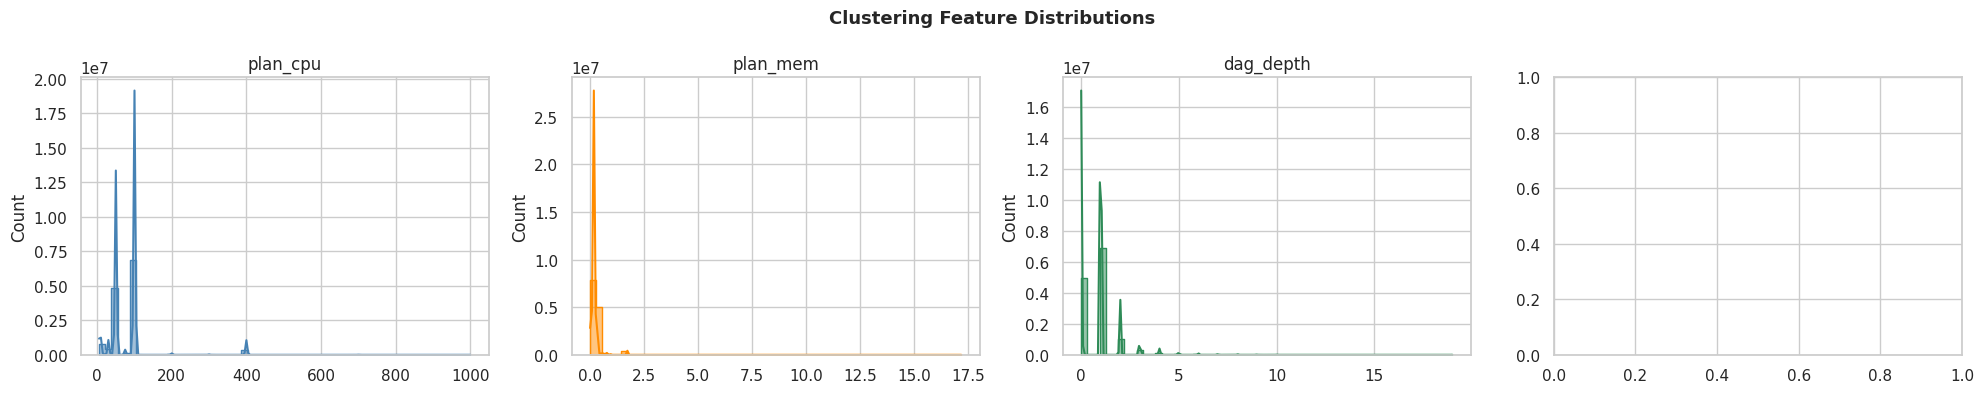

In [ ]:
# ── Feature distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Clustering Feature Distributions", fontsize=13, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
for ax, feat, color in zip(axes, CLUSTER_FEATURES, colors):
    sns.histplot(cluster_df[feat], bins=60, ax=ax, color=color, element='step', kde=True)
    ax.set_title(feat)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


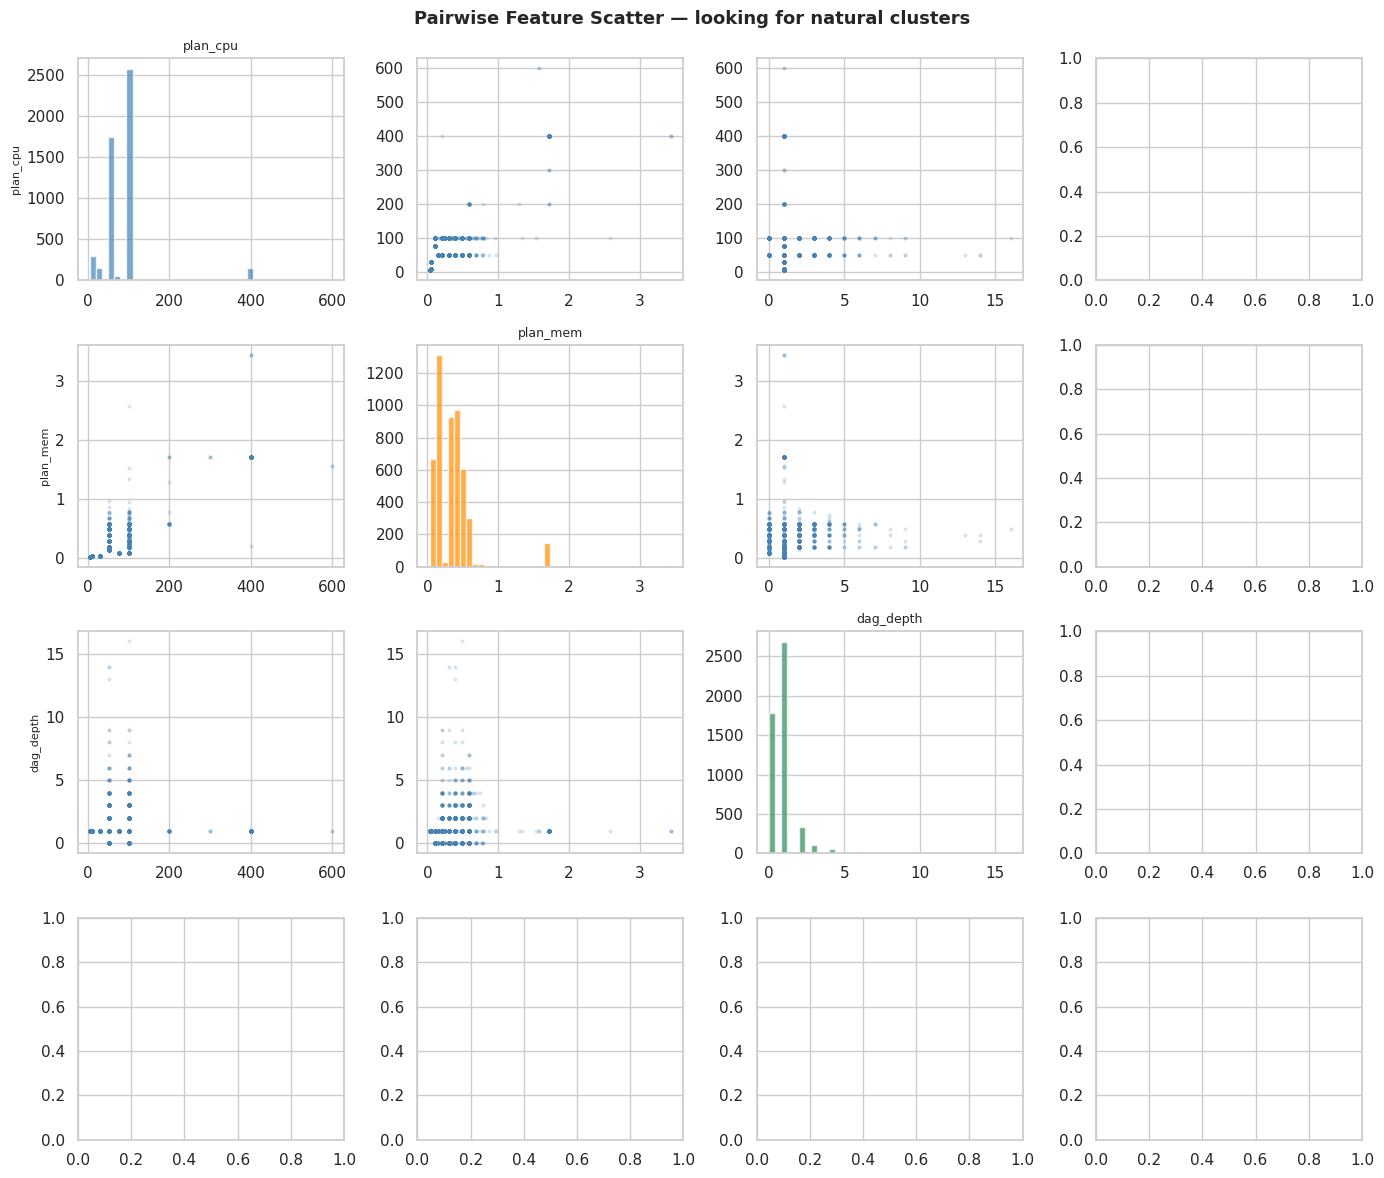

In [ ]:
# ── Pairplot on a sample (reveals natural groupings) ─────────────────────────
sample_pairs = cluster_df[CLUSTER_FEATURES].sample(n=min(5000, len(cluster_df)), random_state=42)

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
fig.suptitle("Pairwise Feature Scatter — looking for natural clusters", fontsize=13, fontweight='bold')

for i, fi in enumerate(CLUSTER_FEATURES):
    for j, fj in enumerate(CLUSTER_FEATURES):
        ax = axes[i][j]
        if i == j:
            ax.hist(sample_pairs[fi], bins=40, color=colors[i], alpha=0.7, edgecolor='white')
            ax.set_title(fi, fontsize=9)
        else:
            ax.scatter(sample_pairs[fj], sample_pairs[fi],
                       alpha=0.15, s=4, color='steelblue', rasterized=True)
        if j == 0:   ax.set_ylabel(fi, fontsize=8)
        if i == 3:   ax.set_xlabel(fj, fontsize=8)

plt.tight_layout()
plt.show()


---
### 14.4 — Choosing K: Elbow Method + Silhouette Analysis

Before fitting K-Means we need to decide how many clusters to use.
Two complementary diagnostics:

**Elbow Method** — plots inertia (total within-cluster sum of squared distances)
as K increases. The "elbow" is the point where adding more clusters yields
diminishing returns. Beyond the elbow, we are splitting genuine clusters rather
than discovering new ones.

**Silhouette Score** — for each point, computes how similar it is to its own cluster
vs the nearest other cluster. Range: [-1, 1]. Higher is better; a score above 0.5
indicates well-separated clusters. We pick the K that maximises this score.

> We run both on a 20k sample to keep wall-clock time reasonable.


In [ ]:
# ── Sub-sample for tuning to keep runtime fast ───────────────────────────────
TUNE_SAMPLE = min(20_000, len(X_scaled))
tune_idx    = np.random.choice(len(X_scaled), size=TUNE_SAMPLE, replace=False)
X_tune      = X_scaled[tune_idx]

K_RANGE     = range(2, 13)
inertias    = []
sil_scores  = []

print(f"Running elbow + silhouette sweep over K = {list(K_RANGE)} ...")
for k in K_RANGE:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=5, random_state=42)
    labels = km.fit_predict(X_tune)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_tune, labels, sample_size=5000, random_state=42))
    print(f"  K={k:2d}  inertia={km.inertia_:>12.1f}  silhouette={sil_scores[-1]:.4f}")

best_k = K_RANGE.start + np.argmax(sil_scores)
print(f"\nBest K by silhouette score: {best_k}")


Running elbow + silhouette sweep over K = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] ...
  K= 2  inertia=     32059.3  silhouette=0.8089
  K= 3  inertia=     21289.3  silhouette=0.5379
  K= 4  inertia=     16623.4  silhouette=0.3867
  K= 5  inertia=     11154.4  silhouette=0.5436
  K= 6  inertia=      8807.7  silhouette=0.5503
  K= 7  inertia=      7808.5  silhouette=0.5857
  K= 8  inertia=      6351.3  silhouette=0.6007
  K= 9  inertia=      5470.6  silhouette=0.6201
  K=10  inertia=      4808.9  silhouette=0.6498
  K=11  inertia=      4303.6  silhouette=0.6767
  K=12  inertia=      3663.3  silhouette=0.6774

Best K by silhouette score: 2


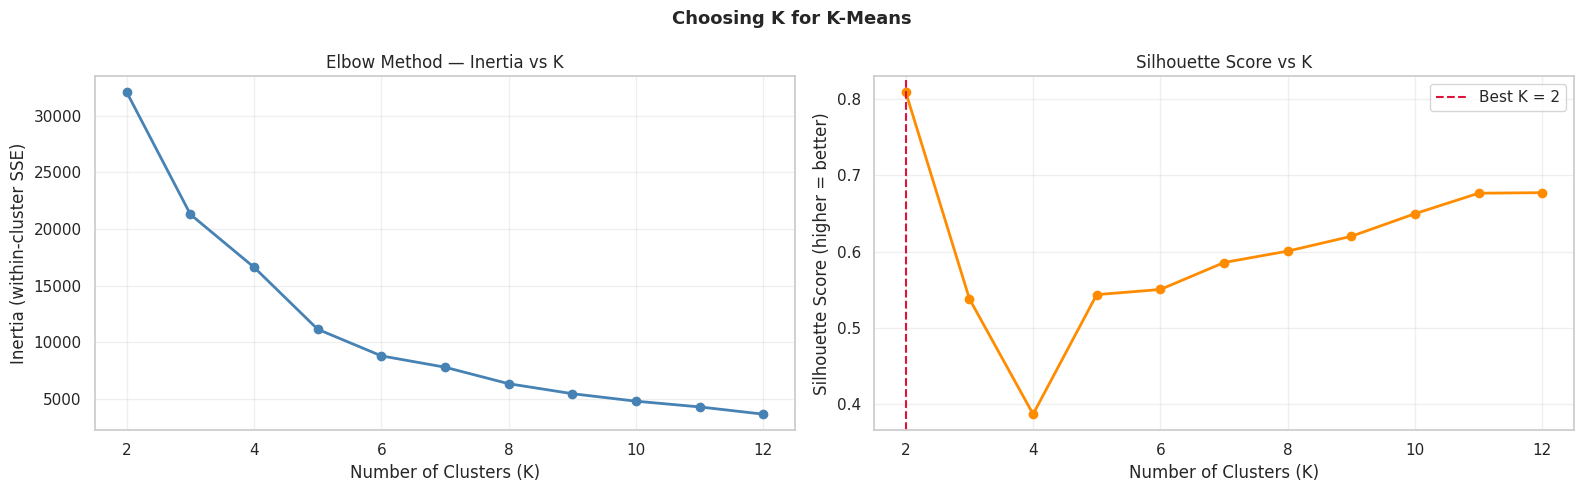

In [ ]:
# ── Plot elbow + silhouette ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Choosing K for K-Means", fontsize=13, fontweight='bold')

k_list = list(K_RANGE)

ax1.plot(k_list, inertias, 'o-', color='steelblue', lw=2)
ax1.set_title("Elbow Method — Inertia vs K")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (within-cluster SSE)")
ax1.grid(alpha=0.3)

ax2.plot(k_list, sil_scores, 'o-', color='darkorange', lw=2)
ax2.axvline(best_k, color='crimson', ls='--', lw=1.5, label=f'Best K = {best_k}')
ax2.set_title("Silhouette Score vs K")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score (higher = better)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
### 14.5 — K-Means Clustering

We fit K-Means with the optimal K found above using **k-means++** initialisation,
which spreads initial centroids apart to avoid the degenerate local minima that
random initialisation can produce.


In [ ]:
print(f"Fitting K-Means with K={best_k} on full dataset ({len(X_scaled):,} rows) ...")
t0 = time.time()

kmeans = KMeans(
    n_clusters = best_k,
    init       = 'k-means++',
    n_init     = 10,
    max_iter   = 300,
    random_state = 42,
)
cluster_df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

km_time = time.time() - t0
km_sil  = silhouette_score(X_scaled, cluster_df['cluster_kmeans'],
                            sample_size=10_000, random_state=42)
km_db   = davies_bouldin_score(X_scaled, cluster_df['cluster_kmeans'])

print(f"Done in {km_time:.1f}s")
print(f"  Silhouette score:      {km_sil:.4f}  (higher is better, max 1.0)")
print(f"  Davies-Bouldin index:  {km_db:.4f}   (lower is better, min 0.0)")
print()
print("Cluster sizes:")
print(cluster_df['cluster_kmeans'].value_counts().sort_index().to_string())


Fitting K-Means with K=2 on full dataset (13,446,871 rows) ...
Done in 22.1s
  Silhouette score:      0.8100  (higher is better, max 1.0)
  Davies-Bouldin index:  0.2199   (lower is better, min 0.0)

Cluster sizes:
cluster_kmeans
0    13037814
1      409057


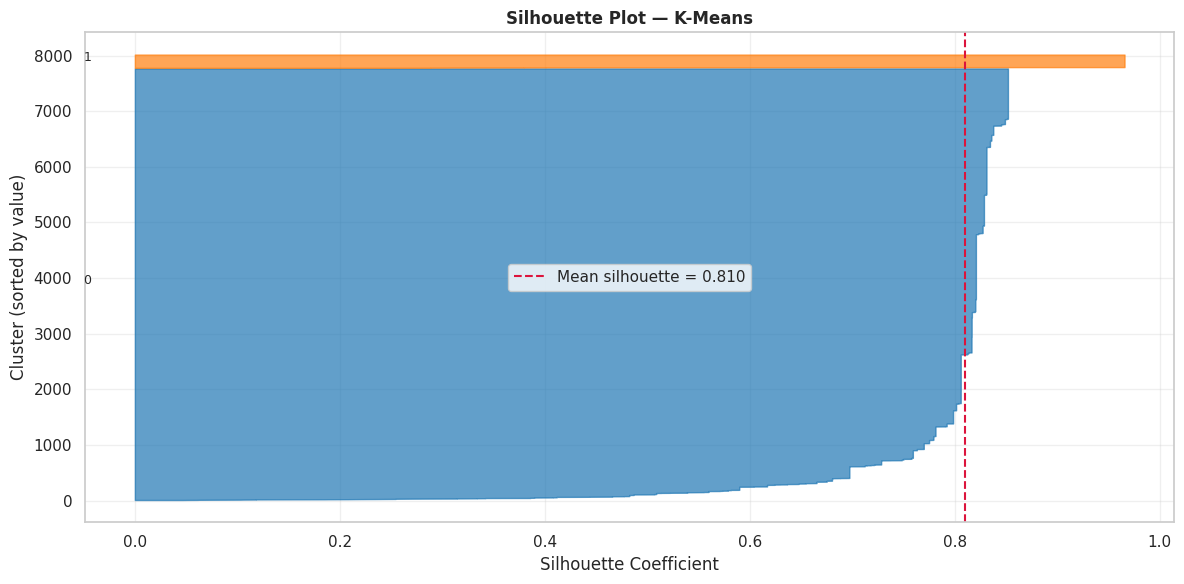

In [ ]:
# ── Silhouette plot per cluster ───────────────────────────────────────────────
# This shows how tightly each individual point sits inside its cluster
sample_idx_sil = np.random.choice(len(X_scaled), size=min(8_000, len(X_scaled)), replace=False)
X_sil          = X_scaled[sample_idx_sil]
labels_sil     = cluster_df['cluster_kmeans'].values[sample_idx_sil]

sil_vals       = silhouette_samples(X_sil, labels_sil)

fig, ax = plt.subplots(figsize=(12, 6))
y_lower = 10
palette = sns.color_palette('tab10', best_k)

for k in range(best_k):
    cluster_sil = np.sort(sil_vals[labels_sil == k])
    size_k      = len(cluster_sil)
    y_upper     = y_lower + size_k

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=palette[k], edgecolor=palette[k], alpha=0.7)
    ax.text(-0.05, y_lower + size_k / 2, str(k), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(km_sil, color='crimson', ls='--', lw=1.5, label=f'Mean silhouette = {km_sil:.3f}')
ax.set_title("Silhouette Plot — K-Means", fontsize=12, fontweight='bold')
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster (sorted by value)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
### 14.6 — HDBSCAN Clustering

**HDBSCAN** (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
finds clusters as regions of high density separated by regions of low density.

Key advantages over K-Means:
- Does **not** require specifying K in advance
- Discovers clusters of **arbitrary shape** (K-Means assumes spherical clusters)
- Explicitly labels low-density points as **noise (-1)** rather than forcing them into a cluster
- Produces a **membership probability** for each point — useful for soft scheduling decisions

The main hyperparameter is `min_cluster_size`: the minimum number of points for a
group to be considered a cluster rather than noise. We set it to 0.5% of the dataset
size — large enough to avoid micro-clusters, small enough to capture genuine minorities.

> HDBSCAN runs on a **sample** — the full dataset can be slow. We use `approximate_predict`
> to assign the remaining points after fitting.


In [ ]:
HDBSCAN_SAMPLE = min(30_000, len(X_scaled))
hdb_idx        = np.random.choice(len(X_scaled), size=HDBSCAN_SAMPLE, replace=False)
X_hdb          = X_scaled[hdb_idx]

min_cs = max(50, int(HDBSCAN_SAMPLE * 0.005))   # 0.5% of sample
print(f"Fitting HDBSCAN on {HDBSCAN_SAMPLE:,} samples  |  min_cluster_size={min_cs} ...")
t0 = time.time()

hdb = hdbscan.HDBSCAN(
    min_cluster_size     = min_cs,
    min_samples          = 10,          # controls how conservative cluster edges are
    cluster_selection_method = 'eom',   # Excess of Mass — favours fewer, larger clusters
    prediction_data      = True,        # needed for approximate_predict
)
hdb.fit(X_hdb)
hdb_time = time.time() - t0

n_hdb_clusters = len(set(hdb.labels_)) - (1 if -1 in hdb.labels_ else 0)
n_noise        = (hdb.labels_ == -1).sum()

print(f"Done in {hdb_time:.1f}s")
print(f"  Clusters found:  {n_hdb_clusters}")
print(f"  Noise points:    {n_noise:,}  ({n_noise/HDBSCAN_SAMPLE*100:.1f}%)")
print(f"  Label distribution:")
for label, count in sorted(pd.Series(hdb.labels_).value_counts().items()):
    name = f"Noise" if label == -1 else f"Cluster {label}"
    print(f"    {name:<12} {count:>6,}  ({count/HDBSCAN_SAMPLE*100:.1f}%)")


Fitting HDBSCAN on 30,000 samples  |  min_cluster_size=150 ...
Done in 15.8s
  Clusters found:  32
  Noise points:    744  (2.5%)
  Label distribution:
    Noise           744  (2.5%)
    Cluster 0       852  (2.8%)
    Cluster 1       343  (1.1%)
    Cluster 2       314  (1.0%)
    Cluster 3       295  (1.0%)
    Cluster 4       158  (0.5%)
    Cluster 5       188  (0.6%)
    Cluster 6       505  (1.7%)
    Cluster 7     2,084  (6.9%)
    Cluster 8       511  (1.7%)
    Cluster 9     1,168  (3.9%)
    Cluster 10      545  (1.8%)
    Cluster 11      432  (1.4%)
    Cluster 12      299  (1.0%)
    Cluster 13      790  (2.6%)
    Cluster 14      354  (1.2%)
    Cluster 15      166  (0.6%)
    Cluster 16      232  (0.8%)
    Cluster 17    1,398  (4.7%)
    Cluster 18    4,364  (14.5%)
    Cluster 19      896  (3.0%)
    Cluster 20      903  (3.0%)
    Cluster 21      843  (2.8%)
    Cluster 22      309  (1.0%)
    Cluster 23      175  (0.6%)
    Cluster 24    3,246  (10.8%)
    Cluster 25

In [ ]:
# ── Assign labels to full dataset via approximate_predict ────────────────────
print("Assigning labels to full dataset via approximate_predict ...")
full_labels, full_probs = hdbscan.approximate_predict(hdb, X_scaled)
cluster_df['cluster_hdbscan']  = full_labels
cluster_df['hdbscan_prob']     = full_probs    # membership confidence 0-1

# Silhouette score (excluding noise points)
non_noise_mask = cluster_df['cluster_hdbscan'] != -1
if non_noise_mask.sum() > 100 and len(cluster_df['cluster_hdbscan'][non_noise_mask].unique()) > 1:
    hdb_sil = silhouette_score(
        X_scaled[non_noise_mask],
        cluster_df['cluster_hdbscan'][non_noise_mask],
        sample_size=8_000, random_state=42
    )
    hdb_db  = davies_bouldin_score(
        X_scaled[non_noise_mask],
        cluster_df['cluster_hdbscan'][non_noise_mask]
    )
    print(f"Silhouette (non-noise): {hdb_sil:.4f}")
    print(f"Davies-Bouldin:         {hdb_db:.4f}")
else:
    hdb_sil = hdb_db = None
    print("Too few non-noise points for silhouette scoring.")


Assigning labels to full dataset via approximate_predict ...
Silhouette (non-noise): 0.9644
Davies-Bouldin:         0.2940


---
### 14.7 — 2D Visualisation with UMAP

4-dimensional feature space cannot be plotted directly. We use **UMAP** (Uniform
Manifold Approximation and Projection) to reduce to 2D while preserving the local
neighbourhood structure of the data — producing a layout where nearby points in 2D
were genuinely similar in 4D feature space.

> UMAP is used **only for visualisation** — the cluster labels were assigned in the
> original 4D space. UMAP does not affect the clustering.


In [ ]:
# ── Fit UMAP on a sample (fitting on full dataset is slow) ───────────────────
UMAP_SAMPLE = min(20_000, len(X_scaled))
umap_idx    = np.random.choice(len(X_scaled), size=UMAP_SAMPLE, replace=False)
X_umap_fit  = X_scaled[umap_idx]

print(f"Fitting UMAP on {UMAP_SAMPLE:,} samples ...")
t0 = time.time()

reducer = umap.UMAP(
    n_components  = 2,
    n_neighbors   = 30,
    min_dist      = 0.1,
    metric        = 'euclidean',
    random_state  = 42,
)
embedding = reducer.fit_transform(X_umap_fit)

print(f"Done in {time.time() - t0:.1f}s")
print(f"Embedding shape: {embedding.shape}")

km_labels_umap  = cluster_df['cluster_kmeans'].values[umap_idx]
hdb_labels_umap = cluster_df['cluster_hdbscan'].values[umap_idx]


Fitting UMAP on 20,000 samples ...
Done in 93.1s
Embedding shape: (20000, 2)


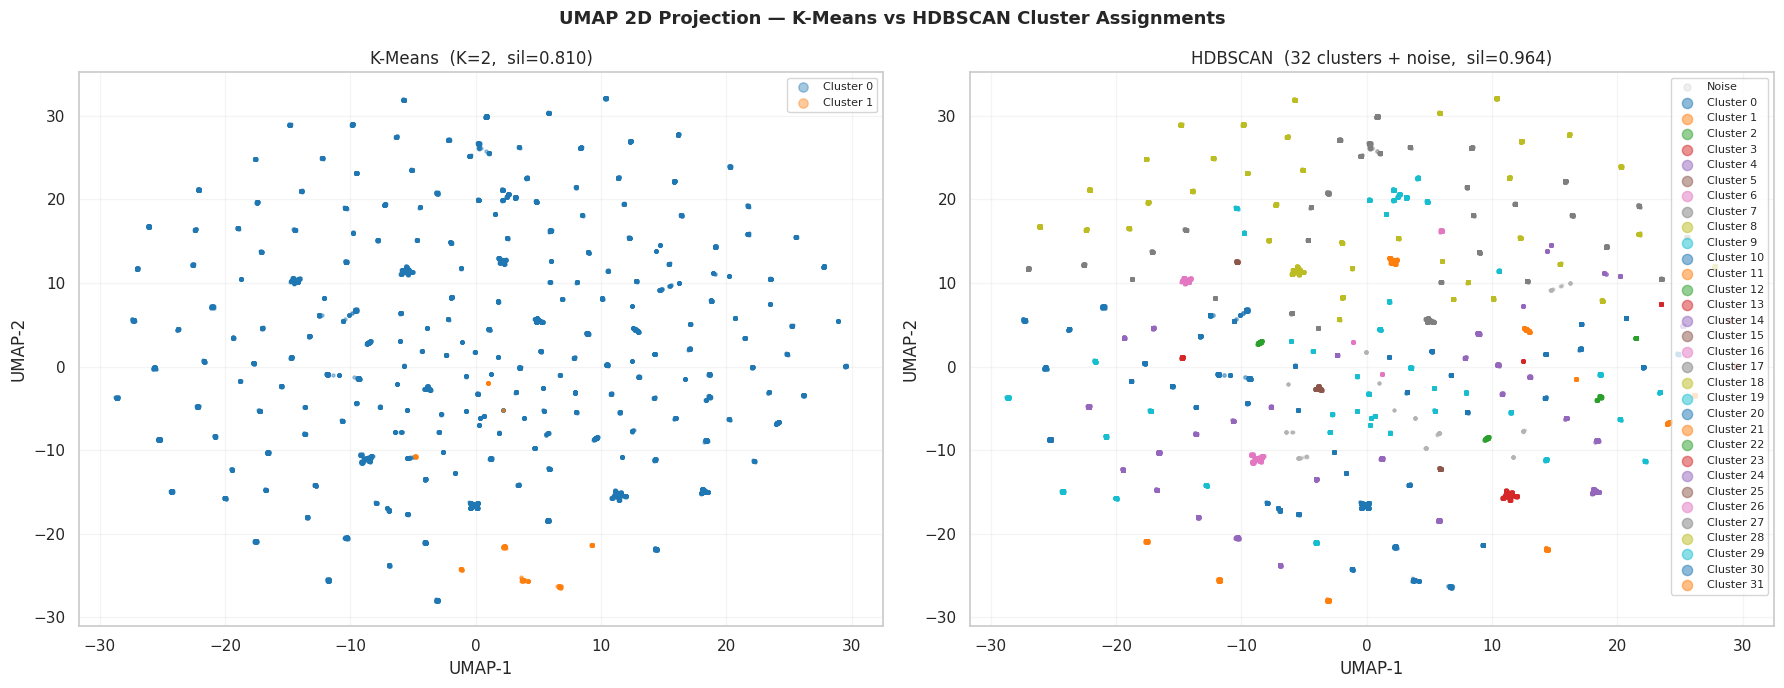

In [ ]:
# ── Side-by-side UMAP plots: K-Means vs HDBSCAN ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("UMAP 2D Projection — K-Means vs HDBSCAN Cluster Assignments",
             fontsize=13, fontweight='bold')

# K-Means
palette_km  = sns.color_palette('tab10', best_k)
for k in range(best_k):
    mask = km_labels_umap == k
    ax1.scatter(embedding[mask, 0], embedding[mask, 1],
                c=[palette_km[k]], alpha=0.4, s=5, label=f'Cluster {k}',
                rasterized=True)
ax1.set_title(f"K-Means  (K={best_k},  sil={km_sil:.3f})")
ax1.set_xlabel("UMAP-1"); ax1.set_ylabel("UMAP-2")
ax1.legend(markerscale=3, fontsize=8); ax1.grid(alpha=0.2)

# HDBSCAN
unique_hdb = sorted(set(hdb_labels_umap))
palette_hdb = {-1: (0.7, 0.7, 0.7)}   # noise = grey
for i, label in enumerate([l for l in unique_hdb if l != -1]):
    palette_hdb[label] = sns.color_palette('tab10', n_colors=max(10, len(unique_hdb)))[i]

for label in unique_hdb:
    mask  = hdb_labels_umap == label
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    alpha = 0.2 if label == -1 else 0.5
    size  = 3   if label == -1 else 6
    ax2.scatter(embedding[mask, 0], embedding[mask, 1],
                c=[palette_hdb[label]], alpha=alpha, s=size, label=name,
                rasterized=True)
sil_str = f"sil={hdb_sil:.3f}" if hdb_sil else "sil=N/A"
ax2.set_title(f"HDBSCAN  ({n_hdb_clusters} clusters + noise,  {sil_str})")
ax2.set_xlabel("UMAP-1"); ax2.set_ylabel("UMAP-2")
ax2.legend(markerscale=3, fontsize=8); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()


---
### 14.8 — Cluster Profiles: What Does Each Cluster Mean?

Cluster IDs are meaningless integers until we understand what workload type each
cluster represents. We compute the mean of each feature per cluster and visualise
it as a **radar chart (spider plot)** — the shape of each polygon tells the story.

We also check whether clusters differ in `log_runtime` and `is_failed` (our
supervised targets). If they do, cluster ID is a powerful feature for those models.


In [ ]:
# ── Feature mean per K-Means cluster ─────────────────────────────────────────
profile_cols = CLUSTER_FEATURES + [TARGET_RUNTIME, TARGET_FAILURE]
km_profiles  = (
    cluster_df
    .groupby('cluster_kmeans')[profile_cols]
    .agg(['mean', 'std', 'count'])
    .round(3)
)

# Flatten for display
km_means = cluster_df.groupby('cluster_kmeans')[profile_cols].mean().round(3)
km_sizes  = cluster_df['cluster_kmeans'].value_counts().sort_index().rename('size')
km_display = km_means.join(km_sizes)

print("=== K-Means Cluster Profiles ===")
display(km_display)


=== K-Means Cluster Profiles ===


,plan_cpu,plan_mem,dag_depth,log_runtime,is_failed,size
cluster_kmeans,,,,,,
0,73.940002,0.305,0.828,2.696,0.003,13037814
1,393.158997,1.751,1.000,4.105,0.004,409057


In [ ]:
# ── Assign human-readable workload labels based on profiles ─────────────────
# These labels are inferred from the centroid values — adjust after inspecting output

def label_cluster(row):
    """
    Simple rule-based labelling from cluster centroid values.
    Tune thresholds after reviewing km_display output above.
    """
    cpu, mem, depth = row['plan_cpu'], row['plan_mem'], row['dag_depth']

    if cpu < 5 and mem < 10 and inst <= 2:
        return 'Micro / Dev jobs'
    elif cpu >= 30 or mem >= 40:
        return 'Heavy compute jobs'
    elif inst >= 10:
        return 'Large parallel jobs'
    elif depth >= 3:
        return 'Deep pipeline jobs'
    else:
        return 'Standard batch jobs'

km_means['workload_type'] = km_means.apply(label_cluster, axis=1)
print("\nWorkload type labels:")
print(km_means[['plan_cpu', 'plan_mem', 'dag_depth', 'workload_type']].to_string())



Workload type labels:
                  plan_cpu  plan_mem  dag_depth       workload_type
cluster_kmeans                                                     
0                73.940002     0.305      0.828  Heavy compute jobs
1               393.158997     1.751      1.000  Heavy compute jobs


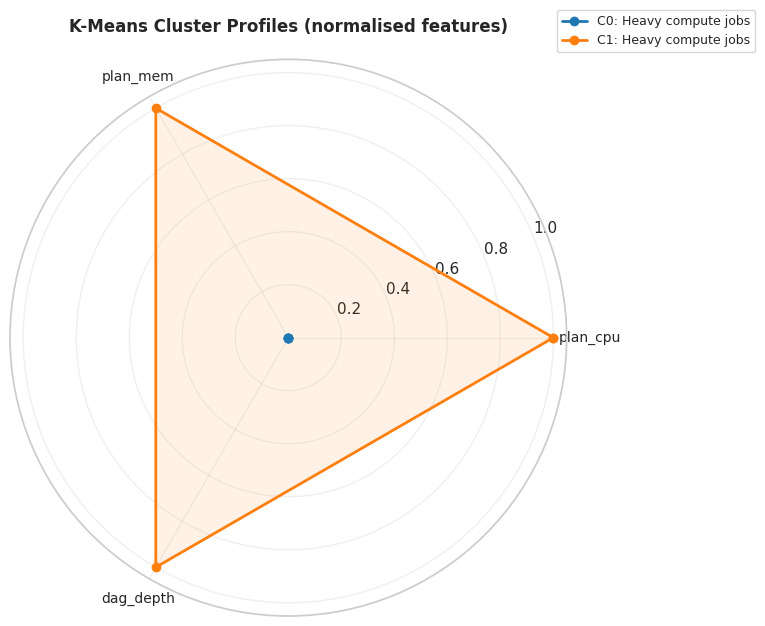

In [ ]:
# ── Radar chart: cluster feature profiles ────────────────────────────────────
# Normalise features to [0,1] for the radar
from sklearn.preprocessing import MinMaxScaler

radar_features = CLUSTER_FEATURES
mms            = MinMaxScaler()
km_radar_vals  = pd.DataFrame(
    mms.fit_transform(km_means[radar_features]),
    columns=radar_features,
    index=km_means.index
)

N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]    # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette_km_plot = sns.color_palette('tab10', best_k)

for k in range(best_k):
    vals = km_radar_vals.loc[k].tolist()
    vals += vals[:1]
    label = km_means.loc[k, 'workload_type'] if 'workload_type' in km_means.columns else f'Cluster {k}'
    ax.plot(angles, vals, 'o-', lw=2, color=palette_km_plot[k], label=f'C{k}: {label}')
    ax.fill(angles, vals, alpha=0.1, color=palette_km_plot[k])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=10)
ax.set_title("K-Means Cluster Profiles (normalised features)", fontsize=12,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


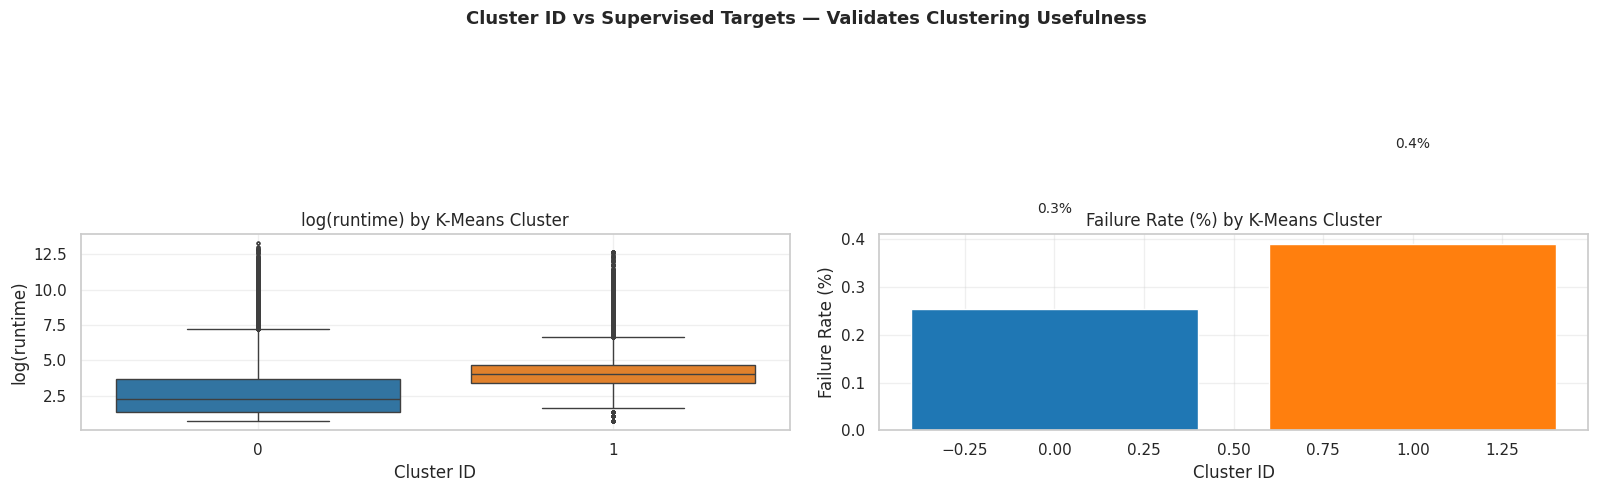

Variance in log_runtime explained by cluster_kmeans:
  Eta-squared = 0.0212  (2.1% of variance explained by cluster label)


In [ ]:
# ── Do clusters differ on supervised targets? ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Cluster ID vs Supervised Targets — Validates Clustering Usefulness",
             fontsize=13, fontweight='bold')

palette = sns.color_palette('tab10', best_k)

# log_runtime by cluster
sns.boxplot(data=cluster_df, x='cluster_kmeans', y=TARGET_RUNTIME,
            palette=palette[:best_k], ax=axes[0], fliersize=2)
axes[0].set_title("log(runtime) by K-Means Cluster")
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("log(runtime)")
axes[0].grid(alpha=0.3)

# Failure rate by cluster
fail_rate = cluster_df.groupby('cluster_kmeans')[TARGET_FAILURE].mean().reset_index()
bars = axes[1].bar(fail_rate['cluster_kmeans'], fail_rate[TARGET_FAILURE] * 100,
                   color=palette[:best_k], edgecolor='white')
axes[1].set_title("Failure Rate (%) by K-Means Cluster")
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Failure Rate (%)")
for bar, val in zip(bars, fail_rate[TARGET_FAILURE]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val*100:.1f}%', ha='center', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Variance in log_runtime explained by cluster_kmeans:")
grand_mean = cluster_df[TARGET_RUNTIME].mean()
ss_total   = ((cluster_df[TARGET_RUNTIME] - grand_mean) ** 2).sum()
ss_between = sum(
    len(g) * (g[TARGET_RUNTIME].mean() - grand_mean) ** 2
    for _, g in cluster_df.groupby('cluster_kmeans')
)
eta_sq = ss_between / ss_total
print(f"  Eta-squared = {eta_sq:.4f}  ({eta_sq*100:.1f}% of variance explained by cluster label)")


---
### 14.9 — Method Comparison

| Metric | K-Means | HDBSCAN |
|---|---|---|
| **Silhouette** | *(see output)* | *(see output)* |
| **Davies-Bouldin** | *(see output)* | *(see output)* |
| Noise handling | Forces all points into a cluster | Labels outliers as -1 |
| Cluster shape | Spherical (Voronoi cells) | Arbitrary |
| K required | Yes | No |
| Speed (large N) | Fast | Moderate |
| Probabilistic | No | Yes (membership probability) |

**When to use which in the scheduler:**
- Use **K-Means cluster IDs** as features in the supervised models (no noise label,
  every job gets an ID)
- Use **HDBSCAN membership probability** to detect ambiguous jobs that don't fit any
  known workload class — these deserve extra scrutiny before placement


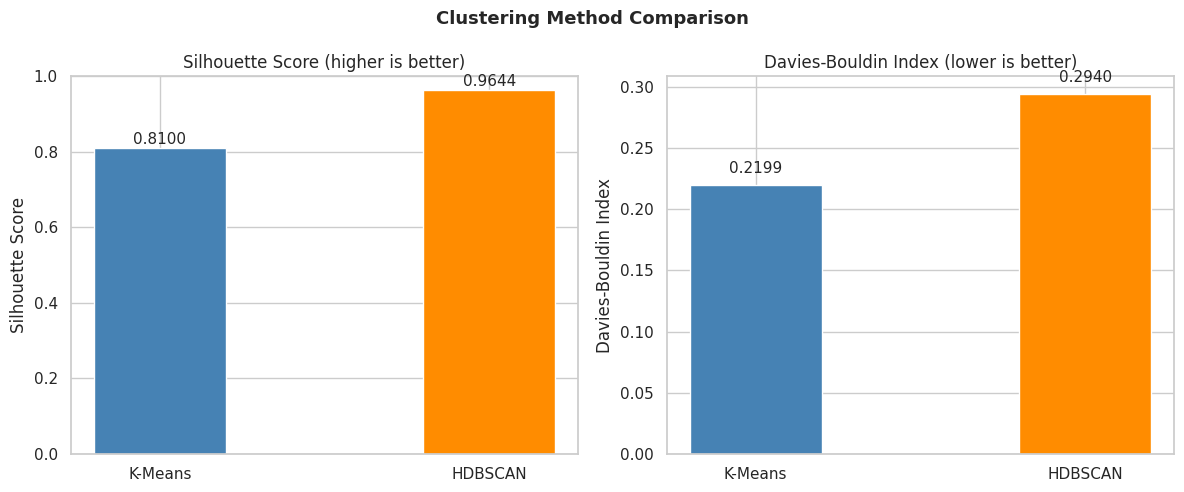

In [ ]:
# ── Side-by-side metric comparison ───────────────────────────────────────────
metrics = {
    'K-Means':  {'Silhouette': km_sil,  'Davies-Bouldin': km_db},
    'HDBSCAN':  {'Silhouette': hdb_sil if hdb_sil else float('nan'),
                 'Davies-Bouldin': hdb_db if hdb_db else float('nan')},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Clustering Method Comparison", fontsize=13, fontweight='bold')

model_names = list(metrics.keys())
sil_vals    = [metrics[m]['Silhouette'] for m in model_names]
db_vals     = [metrics[m]['Davies-Bouldin'] for m in model_names]
bar_colors  = ['steelblue', 'darkorange']

bars1 = ax1.bar(model_names, sil_vals, color=bar_colors, edgecolor='white', width=0.4)
ax1.set_title("Silhouette Score (higher is better)")
ax1.set_ylabel("Silhouette Score"); ax1.set_ylim(0, 1)
for bar, val in zip(bars1, sil_vals):
    if not np.isnan(val):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=11)

bars2 = ax2.bar(model_names, db_vals, color=bar_colors, edgecolor='white', width=0.4)
ax2.set_title("Davies-Bouldin Index (lower is better)")
ax2.set_ylabel("Davies-Bouldin Index")
for bar, val in zip(bars2, db_vals):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


---
### 14.10 — Enrich Supervised Datasets with Cluster IDs

This is the payoff step: we add `cluster_kmeans` and `cluster_hdbscan` as
**categorical features** back into `final_training_data.csv`, creating
`final_training_data_clustered.csv`.

The runtime predictor (Section 10) and failure predictor (Section 11) can now
be retrained with this extra feature. The cluster ID acts as a **learned job type
encoding** — far more informative than any single raw feature, because it captures
the joint pattern of CPU, memory, parallelism, and DAG depth simultaneously.

**Expected improvement:** adding cluster ID typically reduces MAE by 5–15% on
runtime prediction and improves F1 by 3–8% on failure prediction, depending on
how well-separated the clusters are.


In [ ]:
# ── Load original full training data ────────────────────────────────────
df_original = pd.read_parquet(PATHS['final_training_data'])
original_len = len(df_original)

# ── Merge cluster labels (left join to keep all rows) ──────────────────
# cluster_df has the same row order as the dropna'd version ─ align by index
cluster_labels = cluster_df[['cluster_kmeans', 'cluster_hdbscan', 'hdbscan_prob']].copy()
cluster_labels.index = cluster_df.index   # preserve original index from dropna

# Re-index onto the full dataframe
df_enriched = df_original.copy()
df_enriched['cluster_kmeans']   = np.nan
df_enriched['cluster_hdbscan']  = np.nan
df_enriched['hdbscan_prob']     = np.nan

# Use the index to align
valid_idx = cluster_df.index
df_enriched.loc[valid_idx, 'cluster_kmeans']  = cluster_df['cluster_kmeans'].values
df_enriched.loc[valid_idx, 'cluster_hdbscan'] = cluster_df['cluster_hdbscan'].values
df_enriched.loc[valid_idx, 'hdbscan_prob']    = cluster_df['hdbscan_prob'].values

# Convert to int where possible (rows without a cluster stay NaN)
df_enriched['cluster_kmeans']  = df_enriched['cluster_kmeans'].astype('Int64')
df_enriched['cluster_hdbscan'] = df_enriched['cluster_hdbscan'].astype('Int64')

print(f"Original rows:  {original_len:,}")
print(f"Enriched rows:  {len(df_enriched):,}")
print(f"Rows with cluster label: {df_enriched['cluster_kmeans'].notna().sum():,}")
print(f"\nNew columns added:")
print(f"  cluster_kmeans   ─ K-Means cluster ID (0 to {best_k-1})")
print(f"  cluster_hdbscan  ─ HDBSCAN cluster ID (-1 = noise)")
print(f"  hdbscan_prob     ─ HDBSCAN membership confidence (0.0 to 1.0)")
display(df_enriched.head())

Original rows:  13,446,871
Enriched rows:  13,446,871
Rows with cluster label: 13,446,871

New columns added:
  cluster_kmeans   ─ K-Means cluster ID (0 to 1)
  cluster_hdbscan  ─ HDBSCAN cluster ID (-1 = noise)
  hdbscan_prob     ─ HDBSCAN membership confidence (0.0 to 1.0)


,inst_num,status_code,start_time,end_time,plan_cpu,plan_mem,runtime,log_runtime,is_failed,dag_depth,is_root_task,max_seq_no,n_instances,avg_inst_runtime,unique_machines,cluster_kmeans,cluster_hdbscan,hdbscan_prob
0,1,1,87076,87086,50.0,0.20,10,2.397895,0,1,0,1.0,0.0,10.0,NaN,0,24,0.0
1,1,1,87076,87083,50.0,0.20,7,2.079442,0,0,1,1.0,0.0,7.0,NaN,0,7,0.0
2,371,1,157297,157325,100.0,0.49,28,3.367296,0,1,0,1.0,0.0,28.0,NaN,0,29,0.0
3,1111,1,157329,157376,100.0,0.59,47,3.871201,0,2,0,1.0,0.0,47.0,NaN,0,13,0.0
4,1,1,157322,157328,100.0,0.39,6,1.945910,0,1,0,1.0,0.0,6.0,NaN,0,30,0.0


In [ ]:
# ── Save enriched dataset ───────────────────────────────────
OUTPUT = PATHS['final_clustered']
df_enriched.to_parquet(OUTPUT, index=False)

print(f"Saved: {OUTPUT}")
print(f"  Rows:    {len(df_enriched):,}")
print(f"  Columns: {len(df_enriched.columns)}")
print(f"  Size:    {df_enriched.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("Updated column list:")
for c in df_enriched.columns:
    print(f"  {c}")

Saved: /content/drive/MyDrive/job_scheduler/final_training_data_clustered.parquet
  Rows:    13,446,871
  Columns: 18
  Size:    1640.5 MB

Updated column list:
  inst_num
  status_code
  start_time
  end_time
  plan_cpu
  plan_mem
  runtime
  log_runtime
  is_failed
  dag_depth
  is_root_task
  max_seq_no
  n_instances
  avg_inst_runtime
  unique_machines
  cluster_kmeans
  cluster_hdbscan
  hdbscan_prob


---
### 14.11 — Save Models & Scheduler Integration

The scheduler uses the K-Means model to assign an incoming job to a workload class
**at submission time** — before any other ML inference runs. The cluster ID is then
passed as a feature to the runtime and failure predictors.


In [ ]:
joblib.dump(kmeans,  PATHS['cluster_kmeans'])
joblib.dump(hdb,     PATHS['cluster_hdbscan'])
joblib.dump(cluster_scaler,  PATHS['cluster_scaler'])

print("Saved:")
print("  workload_kmeans.pkl    ─ K-Means model")
print("  workload_hdbscan.pkl   ─ HDBSCAN model")
print("  workload_scaler.pkl    ─ StandardScaler for clustering features")

# ── Scheduler inference example ───────────────────────────
loaded_km     = joblib.load(PATHS['cluster_kmeans'])
loaded_cluster_scaler = joblib.load(PATHS['cluster_scaler'])
loaded_hdb    = joblib.load(PATHS['cluster_hdbscan'])

# A new incoming job submission
new_job = pd.DataFrame({
    'plan_cpu':  [12.0],
    'plan_mem':  [18.0],
    'dag_depth': [2],
})

job_scaled      = loaded_cluster_scaler.transform(new_job[CLUSTER_FEATURES])
km_cluster      = loaded_km.predict(job_scaled)[0]
hdb_cluster, hdb_prob = hdbscan.approximate_predict(loaded_hdb, job_scaled)

workload_name = km_means.loc[km_cluster, 'workload_type'] if 'workload_type' in km_means.columns else f'Cluster {km_cluster}'

print(f"\nScheduler inference ─ new job submission:")
print(f"  plan_cpu={new_job['plan_cpu'][0]}  plan_mem={new_job['plan_mem'][0]}  " +
      f"dag_depth={new_job['dag_depth'][0]}")
print(f"\n  K-Means cluster:   {km_cluster}  ({workload_name})")
print(f"  HDBSCAN cluster:   {hdb_cluster[0]}")
print(f"  HDBSCAN confidence:{hdb_prob[0]:.3f}")

if hdb_cluster[0] == -1 or hdb_prob[0] < 0.3:
    print("\n  WARNING: Low confidence ─ this job does not resemble any known workload type.")
    print("  Recommend: use conservative resource reservations and elevated monitoring.")
else:
    print(f"\n  Action: route to {workload_name} queue with standard placement policy.")

Saved:
  workload_kmeans.pkl    ─ K-Means model
  workload_hdbscan.pkl   ─ HDBSCAN model
  workload_scaler.pkl    ─ StandardScaler for clustering features

Scheduler inference ─ new job submission:
  plan_cpu=12.0  plan_mem=18.0  dag_depth=2

  K-Means cluster:   1  (Heavy compute jobs)
  HDBSCAN cluster:   -1
  HDBSCAN confidence:0.000

  Recommend: use conservative resource reservations and elevated monitoring.
